<a href="https://colab.research.google.com/github/majeesushmitamtech-creator/Traffic-Prediction/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

PROJECT_DIR = '/content/drive/MyDrive/kolkata_traffic_stllm'
os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)

print("Folder structure created:")
print(f"  {PROJECT_DIR}/")
print(f"  ├── data/raw/         -> CSVs here")
print(f"  ├── data/processed/   -> preprocessed tensors saved here")
print(f"  ├── checkpoints/      -> model weights saved here")
print(f"  └── results/          -> evaluation plots + metrics")

Folder structure created:
  /content/drive/MyDrive/kolkata_traffic_stllm/
  ├── data/raw/         -> CSVs here
  ├── data/processed/   -> preprocessed tensors saved here
  ├── checkpoints/      -> model weights saved here
  └── results/          -> evaluation plots + metrics


In [ ]:
!pip install torch torch-geometric transformers peft osmnx networkx folium -q
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu118.html -q

import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
GPU available: True
GPU name: Tesla T4
VRAM: 15.6 GB


#preparing the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_5 = pd.read_csv(f'{PROJECT_DIR}/data/raw/kolkata_traffic_merged5.csv')
df_17 = pd.read_csv(f'{PROJECT_DIR}/data/raw/kolkata_traffic_merged17.csv')

df_17['timestamp'] = pd.to_datetime(df_17['timestamp'])
for df in [df_5, df_17]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

def audit_dataset(df, name):
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"Total days: {(df['timestamp'].max() - df['timestamp'].min()).days}")
    print(f"Locations ({df['location_name'].nunique()}):")
    for loc in df['location_name'].unique():
        sub = df[df['location_name'] == loc]
        print(f"  {loc}: {len(sub)} readings, "
              f"speed range [{sub['current_speed'].min():.0f}, {sub['current_speed'].max():.0f}] km/h")

    print(f"\nMissing values:")
    print(df[['current_speed','current_travel_time','confidence']].isnull().sum())

    # Check time gaps
    for loc in df['location_name'].unique():
        sub = df[df['location_name'] == loc].sort_values('timestamp')
        gaps = sub['timestamp'].diff().dropna()
        expected = pd.Timedelta('1min')
        big_gaps = gaps[gaps > expected * 2]
        if len(big_gaps) > 0:
            print(f"\n {loc}: {len(big_gaps)} gaps detected")
            print(f"   Largest gap: {big_gaps.max()}")

audit_dataset(df_5, "5-Location Dataset")
audit_dataset(df_17, "17-Location Dataset")


Dataset: 5-Location Dataset
Shape: (5470, 11)
Date range: 2026-02-09 06:59:10.413349 → 2026-02-10 11:50:15.950188
Total days: 1
Locations (5):
  EM_Bypass_North: 1094 readings, speed range [10, 23] km/h
  Park_Street: 1094 readings, speed range [8, 19] km/h
  Howrah_Bridge: 1094 readings, speed range [11, 19] km/h
  Gariahat: 1094 readings, speed range [12, 19] km/h
  Salt_Lake_V: 1094 readings, speed range [12, 24] km/h

Missing values:
current_speed          0
current_travel_time    0
confidence             0
dtype: int64

 EM_Bypass_North: 2 gaps detected
   Largest gap: 0 days 21:50:22.921763

 Park_Street: 2 gaps detected
   Largest gap: 0 days 21:50:22.942052

 Howrah_Bridge: 2 gaps detected
   Largest gap: 0 days 21:50:22.965694

 Gariahat: 2 gaps detected
   Largest gap: 0 days 21:50:22.997372

 Salt_Lake_V: 2 gaps detected
   Largest gap: 0 days 21:50:23.016859

Dataset: 17-Location Dataset
Shape: (190570, 11)
Date range: 2026-02-10 14:25:02.691562 → 2026-04-15 06:37:38.86065

In [ ]:
df = df_17.copy()
# For the 5 locations that appear in both, append earlier history from df_5
common_locs = set(df_5['location_name'].unique()) & set(df_17['location_name'].unique())
earlier_data = df_5[df_5['location_name'].isin(common_locs)]

# Only keep rows from df_5 that are EARLIER than df_17's start
df_17_start = df['timestamp'].min()
earlier_data = earlier_data[earlier_data['timestamp'] < df_17_start]

df_combined = pd.concat([earlier_data, df], ignore_index=True)
df_combined = df_combined.sort_values(['location_name', 'timestamp']).reset_index(drop=True)

print(f"Combined dataset: {len(df_combined)} rows")
print(f"Locations: {df_combined['location_name'].nunique()}")

Combined dataset: 190570 rows
Locations: 17


In [ ]:
print("Before fix:")
print(df_combined['timestamp'].head(3).tolist())

# Floor ALL timestamps to the nearest minute
df_combined['timestamp'] = df_combined['timestamp'].dt.floor('min')

print("\nAfter fix:")
print(df_combined['timestamp'].head(3).tolist())

# Verify overlap
loc_names = df_combined['location_name'].unique()
ts_0 = set(df_combined[df_combined['location_name']==loc_names[0]]['timestamp'])
ts_1 = set(df_combined[df_combined['location_name']==loc_names[1]]['timestamp'])
overlap = ts_0 & ts_1
print(f"\nShared timestamps after fix: {len(overlap)}")

dups = df_combined.groupby(['timestamp','location_name']).size()
print(f"\nMax rows per (timestamp, location) after flooring: {dups.max()}")
print(f"Duplicate pairs: {(dups > 1).sum()}")

# If duplicates > 0,  average them
if (dups > 1).sum() > 0:
    print("  Duplicates found, averaging them...")
    numeric_cols = ['current_speed', 'current_travel_time', 'confidence',
                    'latitude', 'longitude']
    numeric_cols = [c for c in numeric_cols if c in df_combined.columns]

    df_combined = df_combined.groupby(
        ['timestamp', 'location_name']
    )[numeric_cols].mean().reset_index()

    print(f"After dedup: {len(df_combined)} rows")
else:
    print("→ No duplicates, you're clean")

Before fix:
[Timestamp('2026-02-10 14:25:25.736547'), Timestamp('2026-02-10 14:26:52.148175'), Timestamp('2026-02-10 14:28:18.479760')]

After fix:
[Timestamp('2026-02-10 14:25:00'), Timestamp('2026-02-10 14:26:00'), Timestamp('2026-02-10 14:28:00')]

Shared timestamps after fix: 8436

Max rows per (timestamp, location) after flooring: 8
Duplicate pairs: 16013
  Duplicates found, averaging them...
After dedup: 156265 rows


In [ ]:
#Fill gaps so every location has a reading every minute
def fill_gaps(df, freq='1min'):
    """
    Reindex each location to have exactly one row per minute.
    Fill short gaps (≤5 min) with linear interpolation.
    Fill longer gaps with forward fill then flag them.
    """
    all_locs = []

    for loc in df['location_name'].unique():
        sub = df[df['location_name'] == loc].copy()

        # Handle potential duplicate timestamps for this location by aggregating
        # We assume for traffic data, taking the mean of speed/travel time/confidence
        # for duplicate timestamps is reasonable. Latitude and longitude should be constant.
        if sub.duplicated(subset=['timestamp']).any():
            numeric_cols_for_mean = ['current_speed', 'current_travel_time', 'confidence']
            other_cols_for_first = ['latitude', 'longitude']

            agg_dict = {}
            for col in numeric_cols_for_mean:
                if col in sub.columns:
                    agg_dict[col] = 'mean'
            for col in other_cols_for_first:
                if col in sub.columns:
                    agg_dict[col] = 'first'

            # Group by timestamp and apply aggregation
            sub = sub.groupby('timestamp').agg(agg_dict).reset_index()
            # Ensure location_name is still present, as groupby might drop it
            sub['location_name'] = loc

        sub = sub.set_index('timestamp').sort_index()

        # Keep only numeric columns for resampling
        numeric_cols = ['current_speed', 'current_travel_time', 'confidence',
                       'latitude', 'longitude']
        numeric_cols = [c for c in numeric_cols if c in sub.columns]

        # Reindex to complete minute-by-minute timeline
        full_index = pd.date_range(sub.index.min(), sub.index.max(), freq=freq)

        sub = sub[numeric_cols].reindex(full_index)

        sub['is_imputed'] = sub['current_speed'].isna().astype(int)

        sub[numeric_cols] = sub[numeric_cols].interpolate(
            method='linear', limit=5, limit_direction='forward'
        )

        sub[numeric_cols] = sub[numeric_cols].ffill().bfill()

        sub['latitude'] = sub['latitude'].ffill().bfill()
        sub['longitude'] = sub['longitude'].ffill().bfill()
        sub['location_name'] = loc
        sub.index.name = 'timestamp'
        sub = sub.reset_index()

        all_locs.append(sub)

    return pd.concat(all_locs, ignore_index=True)

df_filled = fill_gaps(df_combined)

print(f"After gap filling: {len(df_filled)} rows")
print(f"Imputed rows: {df_filled['is_imputed'].sum()} ({df_filled['is_imputed'].mean()*100:.1f}%)")

After gap filling: 1558766 rows
Imputed rows: 1402501 (90.0%)


In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle

FEATURES = ['current_speed', 'current_travel_time', 'confidence']

scalers = {}
df_norm = df_filled.copy()

for feat in FEATURES:
    scaler = StandardScaler()
    real_vals = df_filled[df_filled['is_imputed'] == 0][feat].values.reshape(-1, 1)
    scaler.fit(real_vals)
    df_norm[feat] = scaler.transform(df_filled[feat].values.reshape(-1, 1))
    mean = df_norm[feat].mean()
    std  = df_norm[feat].std()
    df_norm[feat] = df_norm[feat].clip(mean - 3*std, mean + 3*std)
    print(f"Clipped {feat}: [{mean-3*std:.3f}, {mean+3*std:.3f}]")
    scalers[feat] = scaler

with open(f'{PROJECT_DIR}/data/processed/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Scalers saved.")
print(f"Speed: mean={scalers['current_speed'].mean_[0]:.2f}, std={scalers['current_speed'].scale_[0]:.2f}")

Clipped current_speed: [-3.093, 3.069]
Clipped current_travel_time: [-3.019, 3.047]
Clipped confidence: [-3.851, 3.773]
Scalers saved.
Speed: mean=24.74, std=8.94


In [ ]:
locations = sorted(df_norm['location_name'].unique())
N_LOCS = len(locations)
loc_to_idx = {loc: i for i, loc in enumerate(locations)}

def make_matrix(df, feature):
    pivot = df.pivot(index='timestamp', columns='location_name', values=feature)
    pivot = pivot.reindex(columns=locations)  # consistent column order
    return pivot.values  # shape: (T, N)

speed_matrix = make_matrix(df_norm, 'current_speed')        # (T, N)
travel_matrix = make_matrix(df_norm, 'current_travel_time') # (T, N)
conf_matrix = make_matrix(df_norm, 'confidence')            # (T, N)

# Stack features: shape (T, N, F) where F=3
data_matrix = np.stack([speed_matrix, travel_matrix, conf_matrix], axis=-1)

T, N, F = data_matrix.shape
print(f"Data matrix shape: {data_matrix.shape}")
print(f"  T={T} timesteps, N={N} locations, F={F} features")

# Decide window sizes based on your data
# With 1-min intervals and ~5hr/day sessions:
# History = 30 min = 30 steps, Forecast = 15 min = 15 steps
# These are adjustable

HISTORY_LEN = 30   # past 30 minutes
FORECAST_LEN = 15  # predict next 15 minutes

print(f"\nWindow config:")
print(f"  History: {HISTORY_LEN} steps = {HISTORY_LEN} minutes")
print(f"  Forecast: {FORECAST_LEN} steps = {FORECAST_LEN} minutes")
print(f"  Total sequences possible: {T - HISTORY_LEN - FORECAST_LEN + 1}")

Data matrix shape: (91693, 17, 3)
  T=91693 timesteps, N=17 locations, F=3 features

Window config:
  History: 30 steps = 30 minutes
  Forecast: 15 steps = 15 minutes
  Total sequences possible: 91649


In [ ]:
print("1. TIMESTAMP ANALYSIS")
print(f"dtype: {df_norm['timestamp'].dtype}")
print(f"Sample timestamps:\n{df_norm['timestamp'].head(5).tolist()}")

ts_sample = df_norm['timestamp'].iloc[0]
print(f"\nFirst timestamp repr: {repr(ts_sample)}")
print(f"Has timezone: {ts_sample.tzinfo is not None}")

print("\n" + "="*50)
print("2. LOCATION NAMES")
print(df_norm['location_name'].unique())

print("\n" + "="*50)
print("3. ROWS PER LOCATION")
print(df_norm.groupby('location_name').size())

print("\n" + "="*50)
print("4. DO TIMESTAMPS OVERLAP ACROSS LOCATIONS?")
loc_names = df_norm['location_name'].unique()
if len(loc_names) >= 2:
    ts_0 = set(df_norm[df_norm['location_name']==loc_names[0]]['timestamp'])
    ts_1 = set(df_norm[df_norm['location_name']==loc_names[1]]['timestamp'])
    overlap = ts_0 & ts_1
    print(f"Location 0 ({loc_names[0]}): {len(ts_0)} timestamps")
    print(f"Location 1 ({loc_names[1]}): {len(ts_1)} timestamps")
    print(f"Shared timestamps: {len(overlap)}")
    print(f"→ If shared=0, that is the pivot problem")

print("\n" + "="*50)
print("5. DUPLICATES CHECK")
dups = df_norm.groupby(['timestamp','location_name']).size()
print(f"Max rows per (timestamp, location): {dups.max()}")
print(f"Duplicate (timestamp, location) pairs: {(dups > 1).sum()}")

print("\n" + "="*50)
print("6. RAW TIMESTAMP COMPARISON")
for loc in loc_names[:2]:
    sub = df_norm[df_norm['location_name']==loc]['timestamp'].head(3)
    print(f"\n{loc}:")
    for t in sub:
        print(f"  {repr(t)}")

1. TIMESTAMP ANALYSIS
dtype: datetime64[ns]
Sample timestamps:
[Timestamp('2026-02-10 14:25:00'), Timestamp('2026-02-10 14:26:00'), Timestamp('2026-02-10 14:27:00'), Timestamp('2026-02-10 14:28:00'), Timestamp('2026-02-10 14:29:00')]

First timestamp repr: Timestamp('2026-02-10 14:25:00')
Has timezone: False

2. LOCATION NAMES
['Behala_Chowrasta' 'Biswa_Bangla_Gate' 'Chingrighata' 'Dunlop_Crossing'
 'Esplanade_Crossing' 'Gariahat_Crossing' 'Howrah_Bridge_Kolkata'
 'Jadavpur_8B' 'Park_Circus_7_Point' 'Park_Street_Chowringhee'
 'Ruby_Crossing' 'Salt_Lake_Sector_V' 'Science_City_Crossing'
 'Sealdah_Flyover' 'Shyambazar_5_Point' 'Taratala_Crossing'
 'Ultadanga_Crossing']

3. ROWS PER LOCATION
location_name
Behala_Chowrasta           91692
Biswa_Bangla_Gate          91692
Chingrighata               91692
Dunlop_Crossing            91693
Esplanade_Crossing         91692
Gariahat_Crossing          91692
Howrah_Bridge_Kolkata      91692
Jadavpur_8B                91692
Park_Circus_7_Point     

In [ ]:
!pip install osmnx networkx geopandas

In [ ]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import os
import time

class OSMnxRoadNetworkBuilder:
    """
    Build road network using OpenStreetMap data
    """

    def __init__(self, csv_file):
        """
        Initialize with traffic data

        """
        self.df = pd.read_csv(csv_file)
        self.df['timestamp'] = pd.to_datetime(self.df['timestamp'])

        # Get unique locations
        self.locations = self.df.groupby('location_name').agg({
            'latitude': 'first',
            'longitude': 'first'
        }).reset_index()

        self.n_locations = len(self.locations)
        self.location_to_idx = {
            loc: idx for idx, loc in enumerate(self.locations['location_name'])
        }

        print(f"Loaded {len(self.df)} traffic records")
        print(f"Found {self.n_locations} unique locations")

        # Will store  road network graph
        self.G = None

    def download_kolkata_road_network(self, cache_file='kolkata_road_network.graphml'):
        """
        Download Kolkata road network from OpenStreetMap
        """
        if os.path.exists(cache_file):
            print(f"Loading cached road network from {cache_file}...")
            self.G = ox.load_graphml(cache_file)
            print(f" Loaded {len(self.G.nodes)} nodes and {len(self.G.edges)} edges")
            return self.G

        print("Downloading Kolkata road network from OpenStreetMap...")
        print("This may take 2-5 minutes (only runs once)...")

        try:
            print("Attempting to download by place name...")
            self.G = ox.graph_from_place(
                'Kolkata, West Bengal, India',
                network_type='drive',
                simplify=True
            )
        except Exception as e:
            print(f"Place name failed: {e}")
            print("Trying bounding box method...")

            bbox = (22.7, 22.4, 88.5, 88.2)

            self.G = ox.graph_from_bbox(
                bbox=bbox,
                network_type='drive',
                simplify=True
            )

        ox.save_graphml(self.G, cache_file)

        print(f" Downloaded and cached Kolkata road network!")
        print(f"  Nodes (intersections): {len(self.G.nodes)}")
        print(f"  Edges (road segments): {len(self.G.edges)}")

        return self.G

    def find_nearest_road_node(self, lat, lon):
        """
        Find nearest road node to a given coordinate
        """
        # Find nearest node (updated API)
        node = ox.nearest_nodes(self.G, lon, lat)
        return node

    def get_road_connections(self, max_distance_km=5.0, use_cache=True):
        """
        Build adjacency matrix using actual road network
        """
        cache_file = 'osmnx_road_connections.pkl'

        if use_cache and os.path.exists(cache_file):
            print("Loading road connections from cache...")
            with open(cache_file, 'rb') as f:
                cache_data = pickle.load(f)
            print(f"  Loaded cached connections")
            print(f"  Total connections: {int(cache_data['adjacency'].sum() / 2)}")
            return cache_data['adjacency'], cache_data['distance'], cache_data['duration']

        if self.G is None:
            self.download_kolkata_road_network()

        print(f"\nBuilding road connections for {self.n_locations} locations...")
        print("Finding nearest road nodes for each location...")

        # Find nearest road node for each location
        location_nodes = []
        for idx, row in self.locations.iterrows():
            node = self.find_nearest_road_node(row['latitude'], row['longitude'])
            location_nodes.append(node)
            print(f"  {row['location_name']}: node {node}")

        # Initialize matrices
        adjacency = np.zeros((self.n_locations, self.n_locations))
        distance_matrix = np.full((self.n_locations, self.n_locations), np.inf)
        duration_matrix = np.full((self.n_locations, self.n_locations), np.inf)

        print(f"\nCalculating routes between all pairs...")
        total_pairs = (self.n_locations * (self.n_locations - 1)) // 2
        processed = 0

        # Calculate shortest paths between all pairs
        for i in range(self.n_locations):
            for j in range(i + 1, self.n_locations):
                node_i = location_nodes[i]
                node_j = location_nodes[j]

                try:
                    # Calculate shortest path length (in meters)
                    length = nx.shortest_path_length(
                        self.G, node_i, node_j, weight='length'
                    )

                    distance_km = length / 1000.0

                    # Store distance
                    distance_matrix[i, j] = distance_km
                    distance_matrix[j, i] = distance_km

                    # Estimate duration (assume average speed based on distance)
                    if distance_km < 2:
                        avg_speed = 25  # km/h - Heavy traffic for short distances
                    elif distance_km < 5:
                        avg_speed = 35  # km/h - Moderate traffic
                    else:
                        avg_speed = 45  # km/h - Highway speeds

                    duration_min = (distance_km / avg_speed) * 60
                    duration_matrix[i, j] = duration_min
                    duration_matrix[j, i] = duration_min

                    if distance_km <= max_distance_km:
                        adjacency[i, j] = 1
                        adjacency[j, i] = 1

                        loc1 = self.locations.iloc[i]['location_name']
                        loc2 = self.locations.iloc[j]['location_name']
                        print(f"  {loc1} ↔ {loc2}: {distance_km:.2f}km, "
                              f"{duration_min:.1f}min")

                    processed += 1
                    if processed % 10 == 0:
                        print(f"Progress: {processed}/{total_pairs} "
                              f"({100*processed/total_pairs:.1f}%)")

                except nx.NetworkXNoPath:
                    # No path exists (disconnected roads)
                    loc1 = self.locations.iloc[i]['location_name']
                    loc2 = self.locations.iloc[j]['location_name']
                    print(f" {loc1} ↔ {loc2}: No path found")
                    processed += 1
                    continue

                except Exception as e:
                    print(f" Error processing pair {i},{j}: {e}")
                    processed += 1
                    continue

        print("\nCaching results for future use...")
        with open(cache_file, 'wb') as f:
            pickle.dump({
                'adjacency': adjacency,
                'distance': distance_matrix,
                'duration': duration_matrix,
                'timestamp': datetime.now()
            }, f)

        print(f"\n Road network built successfully!")
        print(f"  Total connections: {int(adjacency.sum() / 2)}")
        print(f"  Average connections per location: {adjacency.sum(axis=1).mean():.1f}")
        valid_distances = distance_matrix[adjacency == 1]
        if len(valid_distances) > 0:
            print(f"  Average distance: {valid_distances.mean():.2f} km")

        return adjacency, distance_matrix, duration_matrix

    def visualize_on_map(self, adjacency, save_file='kolkata_network_map.html'):
        """
        Create interactive map visualization
        """
        try:
            import folium
        except ImportError:
            print("Installing folium for map visualization...")
            import subprocess
            subprocess.check_call(['pip', 'install', 'folium'])
            import folium

        print(f"\nCreating interactive map visualization...")

        # Create map centered on Kolkata
        center_lat = self.locations['latitude'].mean()
        center_lon = self.locations['longitude'].mean()

        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=12,
            tiles='OpenStreetMap'
        )

        # Add location markers
        for idx, row in self.locations.iterrows():
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=8,
                popup=row['location_name'],
                color='red',
                fill=True,
                fillColor='red',
                fillOpacity=0.7
            ).add_to(m)

            # Add label
            folium.Marker(
                location=[row['latitude'], row['longitude']],
                icon=folium.DivIcon(html=f"""
                    <div style="font-size: 10pt; color: black; font-weight: bold;
                                background-color: white; padding: 2px; border-radius: 3px;">
                        {row['location_name']}
                    </div>
                """)
            ).add_to(m)

        # Add connection lines
        for i in range(self.n_locations):
            for j in range(i + 1, self.n_locations):
                if adjacency[i, j] == 1:
                    loc1 = self.locations.iloc[i]
                    loc2 = self.locations.iloc[j]

                    folium.PolyLine(
                        locations=[
                            [loc1['latitude'], loc1['longitude']],
                            [loc2['latitude'], loc2['longitude']]
                        ],
                        color='blue',
                        weight=2,
                        opacity=0.5
                    ).add_to(m)

        # Save map
        m.save(save_file)
        print(f" Interactive map saved to '{save_file}'")
        print(f"  Open it in your browser to explore the network!")

    def create_sequences(self, history_length=12, prediction_length=12):
        """Create sequences for ST-LLM training"""
        print(f"\nCreating sequences...")
        print(f"  History window: {history_length} timesteps")
        print(f"  Prediction window: {prediction_length} timesteps")

        self.df = self.df.sort_values(['location_name', 'timestamp'])
        sequences = []

        for location in self.df['location_name'].unique():
            loc_data = self.df[self.df['location_name'] == location].copy()
            speeds = loc_data['current_speed'].values
            timestamps = loc_data['timestamp'].values

            for i in range(len(speeds) - history_length - prediction_length + 1):
                history_speeds = speeds[i:i+history_length]
                future_speeds = speeds[i+history_length:i+history_length+prediction_length]

                if np.any(np.isnan(history_speeds)) or np.any(np.isnan(future_speeds)):
                    continue

                sequences.append({
                    'location': location,
                    'location_idx': self.location_to_idx[location],
                    'history_speed': history_speeds,
                    'future_speed': future_speeds,
                    'timestamp': timestamps[i+history_length]
                })

        print(f" Created {len(sequences)} sequences")
        return sequences

    def save_for_training(self, adjacency, distance_matrix, duration_matrix,
                         output_file='kolkata_traffic_stllm_ready.npz'):
        """Save processed data for ST-LLM"""
        print(f"\nPreparing data for ST-LLM training...")

        sequences = self.create_sequences()

        if not sequences:
            print(" No sequences created! Check your data.")
            return

        X = np.array([s['history_speed'] for s in sequences])
        y = np.array([s['future_speed'] for s in sequences])
        location_indices = np.array([s['location_idx'] for s in sequences])
        timestamps = np.array([s['timestamp'] for s in sequences])

        np.savez_compressed(
            output_file,
            X=X,
            y=y,
            location_indices=location_indices,
            timestamps=timestamps,
            adjacency=adjacency,
            distance_matrix=distance_matrix,
            duration_matrix=duration_matrix,
            locations=list(self.location_to_idx.keys()),
            location_coords=self.locations[['latitude', 'longitude']].values
        )

        print(f"\n Data saved to '{output_file}'")
        print(f"\n Dataset Summary:")
        print(f"  Total sequences: {len(sequences)}")
        print(f"  Input shape (X): {X.shape}")
        print(f"  Output shape (y): {y.shape}")
        print(f"  Adjacency shape: {adjacency.shape}")
        print(f"  Locations: {len(self.location_to_idx)}")
        print(f"  Road connections: {int(adjacency.sum() / 2)}")



if __name__ == "__main__":
    print("="*60)
    print("Building Road Network using OpenStreetMap")
    print("="*60)

    builder = OSMnxRoadNetworkBuilder(
        csv_file='/content/drive/MyDrive/kolkata_traffic_stllm/data/raw/kolkata_traffic_merged17.csv'
    )

    # Build road connections
    adjacency, distance_matrix, duration_matrix = builder.get_road_connections(
        max_distance_km=5.0,
        use_cache=True
    )

    builder.visualize_on_map(adjacency)

    builder.save_for_training(adjacency, distance_matrix, duration_matrix)


Building Road Network using OpenStreetMap
Loaded 190570 traffic records
Found 17 unique locations
Loading road connections from cache...
  Loaded cached connections
  Total connections: 30

Creating interactive map visualization...
 Interactive map saved to 'kolkata_network_map.html'
  Open it in your browser to explore the network!

Preparing data for ST-LLM training...

Creating sequences...
  History window: 12 timesteps
  Prediction window: 12 timesteps
 Created 190179 sequences

 Data saved to 'kolkata_traffic_stllm_ready.npz'

 Dataset Summary:
  Total sequences: 190179
  Input shape (X): (190179, 12)
  Output shape (y): (190179, 12)
  Adjacency shape: (17, 17)
  Locations: 17
  Road connections: 30


# arbitrary masking at different sequence

In [ ]:
def create_sequences_with_masking(
    data,           # (T, N, F)
    history_len,
    forecast_len,
    mask_prob_range=(0.1, 0.4),  # randomly mask 10-40% of nodes
    seed=42
):
    """
    Creates sequences for BOTH tasks simultaneously:
    - Input: history with some nodes randomly zeroed out (spatial imputation task)
    - Target temporal: full future values
    - Target spatial: the masked values at current time (reconstruction task)
    """
    rng = np.random.RandomState(seed)
    T, N, F = data.shape

    X_history = []      # (history_len, N, F) — some nodes masked
    X_masks = []        # (N,) — which nodes are masked (1=masked, 0=visible)
    y_temporal = []     # (forecast_len, N, F) — future values for ALL nodes
    y_spatial = []      # (N, F) — current values for masked nodes (reconstruction)

    for t in range(history_len, T - forecast_len + 1):
        history = data[t - history_len : t].copy()         # (H, N, F)
        future = data[t : t + forecast_len].copy()         # (L, N, F)

        if np.isnan(history).any() or np.isnan(future).any():
            continue

        # Randomly decide how many nodes to mask
        mask_prob = rng.uniform(*mask_prob_range)
        n_masked = max(1, int(N * mask_prob))
        masked_nodes = rng.choice(N, size=n_masked, replace=False)

        # Create mask vector
        mask = np.zeros(N, dtype=np.float32)
        mask[masked_nodes] = 1.0

        # Zero out masked nodes in history (simulate sensor failure)
        history_masked = history.copy()
        history_masked[:, masked_nodes, :] = 0.0

        X_history.append(history_masked)
        X_masks.append(mask)
        y_temporal.append(future)
        y_spatial.append(data[t - 1])  # ground truth at last history step for reconstruction

    return {
        'X_history': np.array(X_history, dtype=np.float32),   # (S, H, N, F)
        'X_masks': np.array(X_masks, dtype=np.float32),       # (S, N)
        'y_temporal': np.array(y_temporal, dtype=np.float32), # (S, L, N, F)
        'y_spatial': np.array(y_spatial, dtype=np.float32),   # (S, N, F)
    }

sequences = create_sequences_with_masking(data_matrix, HISTORY_LEN, FORECAST_LEN)

S = len(sequences['X_history'])
print(f"Created {S} sequences")
print(f"  X_history: {sequences['X_history'].shape}")
print(f"  X_masks:   {sequences['X_masks'].shape}")
print(f"  y_temporal:{sequences['y_temporal'].shape}")
print(f"  y_spatial: {sequences['y_spatial'].shape}")

# Train / Val / Test split — 70 / 15 / 15
train_end = int(0.70 * S)
val_end = int(0.85 * S)

splits = {
    'train': {k: v[:train_end] for k, v in sequences.items()},
    'val':   {k: v[train_end:val_end] for k, v in sequences.items()},
    'test':  {k: v[val_end:] for k, v in sequences.items()},
}

for split, data in splits.items():
    print(f"{split}: {len(data['X_history'])} sequences")

# Save processed data
np.savez_compressed(
    f'{PROJECT_DIR}/data/processed/sequences.npz',
    **{f'{split}_{k}': v for split, d in splits.items() for k, v in d.items()}
)
print("\n Sequences saved to Drive")

Created 91648 sequences
  X_history: (91648, 30, 17, 3)
  X_masks:   (91648, 17)
  y_temporal:(91648, 15, 17, 3)
  y_spatial: (91648, 17, 3)
train: 64153 sequences
val: 13747 sequences
test: 13748 sequences

 Sequences saved to Drive


In [ ]:
import torch
from torch_geometric.data import Data

def build_pyg_graph(adjacency, distance_matrix, location_coords):
    """
    Convert adjacency matrix to PyTorch Geometric edge format.
    Edge weights = inverse distance (closer = stronger connection).
    """
    N = adjacency.shape[0]

    edge_index = []
    edge_weight = []

    for i in range(N):
        for j in range(N):
            if adjacency[i, j] == 1 and i != j:
                edge_index.append([i, j])
                dist = distance_matrix[i, j]
                # Inverse distance weighting; closer nodes have stronger edges
                weight = 1.0 / (dist + 1e-6)
                edge_weight.append(weight)

    edge_index = torch.tensor(edge_index, dtype=torch.long).T  # (2, E)
    edge_weight = torch.tensor(edge_weight, dtype=torch.float32)

    edge_weight = edge_weight / edge_weight.max()

    # Node features: lat/lon as initial node features
    node_features = torch.tensor(location_coords, dtype=torch.float32)

    graph = Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_weight
    )

    print(f"Graph built:")
    print(f"  Nodes: {graph.num_nodes}")
    print(f"  Edges: {graph.num_edges}")
    print(f"  Avg degree: {graph.num_edges / graph.num_nodes:.1f}")

    return graph

npz = np.load('/content/kolkata_traffic_stllm_ready.npz',
              allow_pickle=True)

graph = build_pyg_graph(
    adjacency=npz['adjacency'],
    distance_matrix=npz['distance_matrix'],
    location_coords=npz['location_coords']
)

torch.save(graph, f'{PROJECT_DIR}/data/processed/road_graph.pt')
print(" Graph saved")

Graph built:
  Nodes: 17
  Edges: 60
  Avg degree: 3.5
 Graph saved


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from transformers import GPT2Model, GPT2Config
from peft import get_peft_model, LoraConfig, TaskType

# Component 1: Spatial Encoder (GAT)

class SpatialEncoder(nn.Module):
    """
    Graph Attention Network that encodes spatial relationships.
    For masked (failed) nodes, it reconstructs from neighbors.
    """
    def __init__(self, in_features, hidden_dim, out_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.gat1 = GATConv(in_features, hidden_dim, heads=n_heads,
                            dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden_dim * n_heads, out_dim, heads=1,
                            dropout=dropout, concat=False)
        self.norm1 = nn.LayerNorm(hidden_dim * n_heads)
        self.norm2 = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight, mask=None):
        """
        x: (B*N, F) — node features
        edge_index: (2, E)
        edge_weight: (E,)
        mask: (B*N,) — 1 where node is failed/masked
        """
        # If node is masked, zero its input (model must infer from neighbors)
        if mask is not None:
            x = x * (1 - mask.unsqueeze(-1))

        h = self.gat1(x, edge_index, edge_weight)
        h = self.norm1(F.elu(h))
        h = self.dropout(h)
        h = self.gat2(h, edge_index, edge_weight)
        h = self.norm2(F.elu(h))
        return h  # (B*N, out_dim)'''

    '''def forward(self, x, edge_index, edge_weight, mask=None):
        residual = x.clone()

        if mask is not None:
            x = x * (1 - mask.unsqueeze(-1))

        h = self.gat1(x, edge_index, edge_weight)
        h = self.norm1(F.elu(h))
        h = self.dropout(h)
        h = self.gat2(h, edge_index, edge_weight)
        h = self.norm2(F.elu(h))

        # This lets the node use its own history even when neighbours are weak
        if not hasattr(self, 'residual_proj'):
            self.residual_proj = nn.Linear(
                residual.shape[-1], h.shape[-1]
            ).to(h.device)

        h = h + self.residual_proj(residual * (1 - mask.unsqueeze(-1) if mask is not None else 1))
        return h'''


# Component 2: Temporal Encoder (GPT-2 + LoRA)

def build_lora_gpt2(gpt2_embed_dim=768, lora_r=8, lora_alpha=16):
    """
    Load GPT-2 small and apply LoRA for efficient fine-tuning.
    """
    config = GPT2Config(
        n_embd=gpt2_embed_dim,
        n_layer=6,       # Use 6 layers instead of 12 to fit T4
        n_head=12,
        n_positions=512,
        vocab_size=50257
    )
    gpt2 = GPT2Model(config)

    # LoRA config — only fine-tune attention query and value projections
    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["c_attn"],  # GPT-2's combined QKV projection
        lora_dropout=0.05,
        bias="none",
        fan_in_fan_out=True
    )

    gpt2 = get_peft_model(gpt2, lora_config)
    gpt2.print_trainable_parameters()

    return gpt2


# Component 3: Full ST-LLM Model

class TrafficSTLLM(nn.Module):
    def __init__(
        self,
        n_locations,      # N
        n_features,       # F = 3
        history_len,      # H
        forecast_len,     # L
        spatial_hidden=64,
        spatial_out=128,
        gpt2_dim=768,
        lora_r=8,
        dropout=0.1
    ):
        super().__init__()

        self.N = n_locations
        self.F = n_features
        self.H = history_len
        self.L = forecast_len
        self.gpt2_dim = gpt2_dim

        # Spatial encoder per timestep
        self.spatial_encoder = SpatialEncoder(
            in_features=n_features,
            hidden_dim=spatial_hidden,
            out_dim=spatial_out,
            n_heads=4,
            dropout=dropout
        )

        # Project spatial output → GPT-2 input dimension
        # GPT-2 sees one "token" per timestep, each token = ALL nodes aggregated
        self.spatial_to_token = nn.Linear(spatial_out * n_locations, gpt2_dim)

        # GPT-2 with LoRA
        self.gpt2 = build_lora_gpt2(gpt2_dim, lora_r)

        # Output heads
        # Temporal head: predict future for all nodes
        self.temporal_head = nn.Sequential(
            nn.Linear(gpt2_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_len * n_locations * n_features)
        )

        # Spatial head: reconstruct masked nodes at current time
        self.spatial_head = nn.Sequential(
            nn.Linear(gpt2_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_locations * n_features)
        )

    def forward(self, x_history, mask, edge_index, edge_weight):
        """
        x_history: (B, H, N, F)
        mask: (B, N) — 1 = node failed
        edge_index: (2, E)
        edge_weight: (E,)

        Returns:
            y_temporal_pred: (B, L, N, F)
            y_spatial_pred: (B, N, F)
        """
        B, H, N, F = x_history.shape

        token_sequence = []

        for t in range(H):
            x_t = x_history[:, t, :, :]  # (B, N, F)

            x_flat = x_t.reshape(B * N, F)
            mask_flat = mask.reshape(B * N)

            batch_edge_index, batch_edge_weight = self._batch_graph(
                edge_index, edge_weight, B, N
            )

            spatial_out = self.spatial_encoder(
                x_flat, batch_edge_index, batch_edge_weight, mask_flat
            )  # (B*N, spatial_out)

            spatial_out = spatial_out.reshape(B, N * self.spatial_encoder.gat2.out_channels)
            token = self.spatial_to_token(spatial_out)  # (B, gpt2_dim)
            token_sequence.append(token)

        # Stack to sequence: (B, H, gpt2_dim)
        token_sequence = torch.stack(token_sequence, dim=1)

        gpt2_out = self.gpt2(inputs_embeds=token_sequence)
        hidden = gpt2_out.last_hidden_state  # (B, H, gpt2_dim)

        last_hidden = hidden[:, -1, :]  # (B, gpt2_dim)

        # Temporal prediction
        temporal_flat = self.temporal_head(last_hidden)  # (B, L*N*F)
        y_temporal = temporal_flat.reshape(B, self.L, N, F)

        # Spatial reconstruction
        spatial_flat = self.spatial_head(last_hidden)  # (B, N*F)
        y_spatial = spatial_flat.reshape(B, N, F)

        return y_temporal, y_spatial

    def _batch_graph(self, edge_index, edge_weight, batch_size, n_nodes):
        edge_indices = []
        for b in range(batch_size):
            edge_indices.append(edge_index + b * n_nodes)
        batch_edge_index = torch.cat(edge_indices, dim=1)
        batch_edge_weight = edge_weight.repeat(batch_size)
        return batch_edge_index, batch_edge_weight

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TrafficDataset(Dataset):
    def __init__(self, sequences):
        self.X = torch.tensor(sequences['X_history'], dtype=torch.float32)
        self.masks = torch.tensor(sequences['X_masks'], dtype=torch.float32)
        self.y_temp = torch.tensor(sequences['y_temporal'], dtype=torch.float32)
        self.y_spat = torch.tensor(sequences['y_spatial'], dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.masks[idx], self.y_temp[idx], self.y_spat[idx]

BATCH_SIZE = 16

train_loader = DataLoader(TrafficDataset(splits['train']),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TrafficDataset(splits['val']),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TrafficDataset(splits['test']),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 4010
Val batches:   860
Test batches:  860


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TrafficSTLLM(
    n_locations=N_LOCS,
    n_features=3,
    history_len=HISTORY_LEN,
    forecast_len=FORECAST_LEN,
    spatial_hidden=64,
    spatial_out=128,
    gpt2_dim=768,
    lora_r=8,
    dropout=0.2
).to(device)

edge_index = graph.edge_index.to(device)
edge_weight = graph.edge_attr.to(device)

'''def combined_loss(y_temp_pred, y_temp_true, y_spat_pred, y_spat_true,
                  mask, alpha=0.7):
    """
    alpha: weight on temporal loss (1-alpha on spatial)
    For masked nodes only, compute spatial loss
    """
    temp_loss = F.mse_loss(y_temp_pred, y_temp_true)

    # mask: (B, N), expand to (B, N, F)
    mask_expanded = mask.unsqueeze(-1).expand_as(y_spat_true)
    if mask_expanded.sum() > 0:
        spat_loss = F.mse_loss(
            y_spat_pred * mask_expanded,
            y_spat_true * mask_expanded
        )
    else:
        spat_loss = torch.tensor(0.0, device=device)

    return alpha * temp_loss + (1 - alpha) * spat_loss, temp_loss, spat_loss'''



def combined_loss(y_temp_pred, y_temp_true, y_spat_pred, y_spat_true, mask, alpha=0.7):

    speed_true = y_temp_true[..., 0]

    speed_weights = 1.0 + torch.sigmoid(speed_true)

    # Weighted temporal loss
    temp_err = (y_temp_pred - y_temp_true) ** 2
    temp_loss = (temp_err * speed_weights.unsqueeze(-1)).mean()

    # Spatial loss (masked nodes only)
    mask_expanded = mask.unsqueeze(-1).expand_as(y_spat_true)
    if mask_expanded.sum() > 0:
        spat_err = (y_spat_pred - y_spat_true) ** 2
        spat_weights = (1.0 + torch.sigmoid(y_spat_true[..., 0])).unsqueeze(-1)
        spat_loss = (spat_err * spat_weights * mask_expanded).sum() / (mask_expanded.sum() + 1e-6)
    else:
        spat_loss = torch.tensor(0.0, device=y_temp_pred.device)

    total = alpha * temp_loss + (1 - alpha) * spat_loss
    return total, temp_loss, spat_loss




optimizer = torch.optim.AdamW([
    {'params': model.spatial_encoder.parameters(), 'lr': 1e-3},
    {'params': model.spatial_to_token.parameters(), 'lr': 1e-3},
    {'params': model.gpt2.parameters(), 'lr': 5e-5},
    {'params': model.temporal_head.parameters(), 'lr': 1e-3},
    {'params': model.spatial_head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6
)

scaler_amp = torch.amp.GradScaler('cuda')

EPOCHS = 50
PATIENCE = 10  # Early stopping
best_val_loss = float('inf')
patience_counter = 0
history_log = []

CHECKPOINT_PATH = f'{PROJECT_DIR}/checkpoints/best_model.pt'

print("Starting training...")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for X, masks, y_temp, y_spat in train_loader:
        X, masks = X.to(device), masks.to(device)
        y_temp, y_spat = y_temp.to(device), y_spat.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)
            loss, tl, sl = combined_loss(pred_temp, y_temp, pred_spat, y_spat, masks)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for X, masks, y_temp, y_spat in val_loader:
            X, masks = X.to(device), masks.to(device)
            y_temp, y_spat = y_temp.to(device), y_spat.to(device)

            with torch.amp.autocast('cuda'):
                pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)
                loss, tl, sl = combined_loss(pred_temp, y_temp, pred_spat, y_spat, masks)

            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    scheduler.step()

    history_log.append({'epoch': epoch, 'train': train_loss, 'val': val_loss})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': val_loss,
            'config': {
                'n_locations': N_LOCS, 'n_features': 3,
                'history_len': HISTORY_LEN, 'forecast_len': FORECAST_LEN
            }
        }, CHECKPOINT_PATH)
        print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} saved")
    else:
        patience_counter += 1
        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\n Training complete. Best val loss: {best_val_loss:.4f}")

trainable params: 147,456 || all params: 81,666,816 || trainable%: 0.1806
Starting training...
Device: cuda
Model parameters: 83,872,688
Trainable: 2,353,328
Epoch   1 | Train: 0.0952 | Val: 0.0985 saved
Epoch   2 | Train: 0.0563 | Val: 0.0981 saved
Epoch   4 | Train: 0.0419 | Val: 0.0911 saved
Epoch   5 | Train: 0.0390 | Val: 0.0985 | Patience: 1/10
Epoch   8 | Train: 0.0348 | Val: 0.0906 saved
Epoch  10 | Train: 0.0328 | Val: 0.0855 saved
Epoch  15 | Train: 0.0299 | Val: 0.0958 | Patience: 5/10


In [ ]:
def evaluate(model, loader, edge_index, edge_weight, scalers, device):
    model.eval()

    all_temp_pred, all_temp_true = [], []
    all_spat_pred, all_spat_true, all_masks = [], [], []

    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            y_temp, y_spat = y_temp.to(device), y_spat.to(device)

            pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)

            all_temp_pred.append(pred_temp.cpu())
            all_temp_true.append(y_temp.cpu())
            all_spat_pred.append(pred_spat.cpu())
            all_spat_true.append(y_spat.cpu())
            all_masks.append(masks.cpu())

    temp_pred = torch.cat(all_temp_pred).numpy()
    temp_true = torch.cat(all_temp_true).numpy()
    spat_pred = torch.cat(all_spat_pred).numpy()
    spat_true = torch.cat(all_spat_true).numpy()
    masks = torch.cat(all_masks).numpy()

    s = scalers['current_speed']

    def inv(x): return s.inverse_transform(x.reshape(-1, 1)).reshape(x.shape)

    tp_speed = inv(temp_pred[..., 0])
    tt_speed = inv(temp_true[..., 0])
    sp_speed = inv(spat_pred[..., 0])
    st_speed = inv(spat_true[..., 0])

    # Temporal metrics
    mae_temp = np.abs(tp_speed - tt_speed).mean()
    rmse_temp = np.sqrt(((tp_speed - tt_speed)**2).mean())
    mape_temp = (np.abs((tp_speed - tt_speed) / (tt_speed + 1e-6))).mean() * 100

    # Spatial metrics — only on masked nodes
    spatial_mae_vals = []
    for i in range(len(masks)):
        masked_nodes = np.where(masks[i] == 1)[0]
        if len(masked_nodes) > 0:
            err = np.abs(sp_speed[i, masked_nodes] - st_speed[i, masked_nodes])
            spatial_mae_vals.extend(err.tolist())

    mae_spat = np.mean(spatial_mae_vals)

    print("TEMPORAL PREDICTION (all nodes)")
    print(f"  MAE:  {mae_temp:.3f} km/h")
    print(f"  RMSE: {rmse_temp:.3f} km/h")
    print(f"  MAPE: {mape_temp:.2f}%")
    print("\nSPATIAL IMPUTATION (failed nodes only)")
    print(f"  MAE:  {mae_spat:.3f} km/h")

    return temp_pred, temp_true, spat_pred, spat_true, masks

checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state'])

temp_pred, temp_true, spat_pred, spat_true, masks = evaluate(
    model, test_loader, edge_index, edge_weight, scalers, device
)

TEMPORAL PREDICTION (all nodes)
  MAE:  1.852 km/h
  RMSE: 2.948 km/h
  MAPE: 9.31%

SPATIAL IMPUTATION (failed nodes only)
  MAE:  2.275 km/h


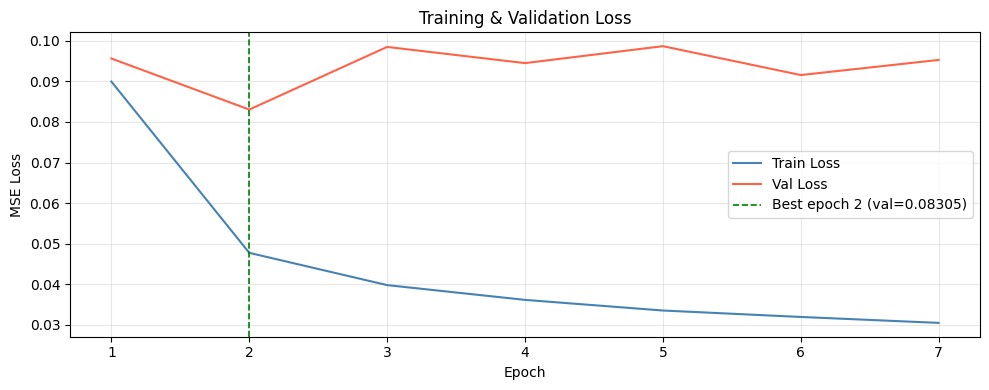

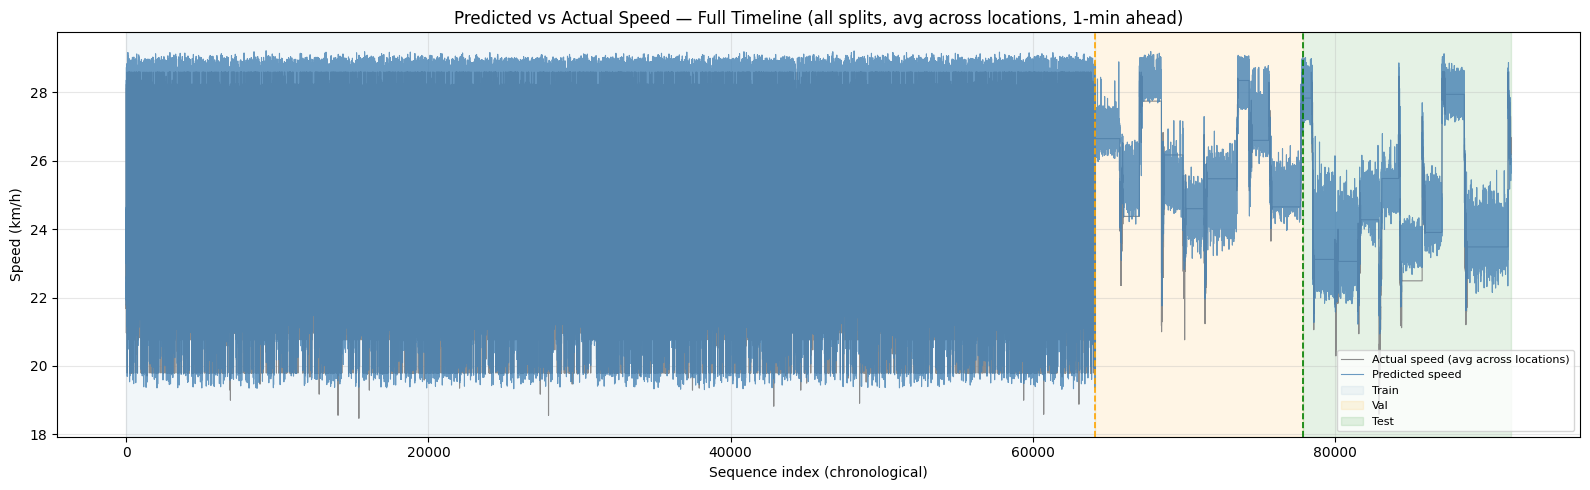

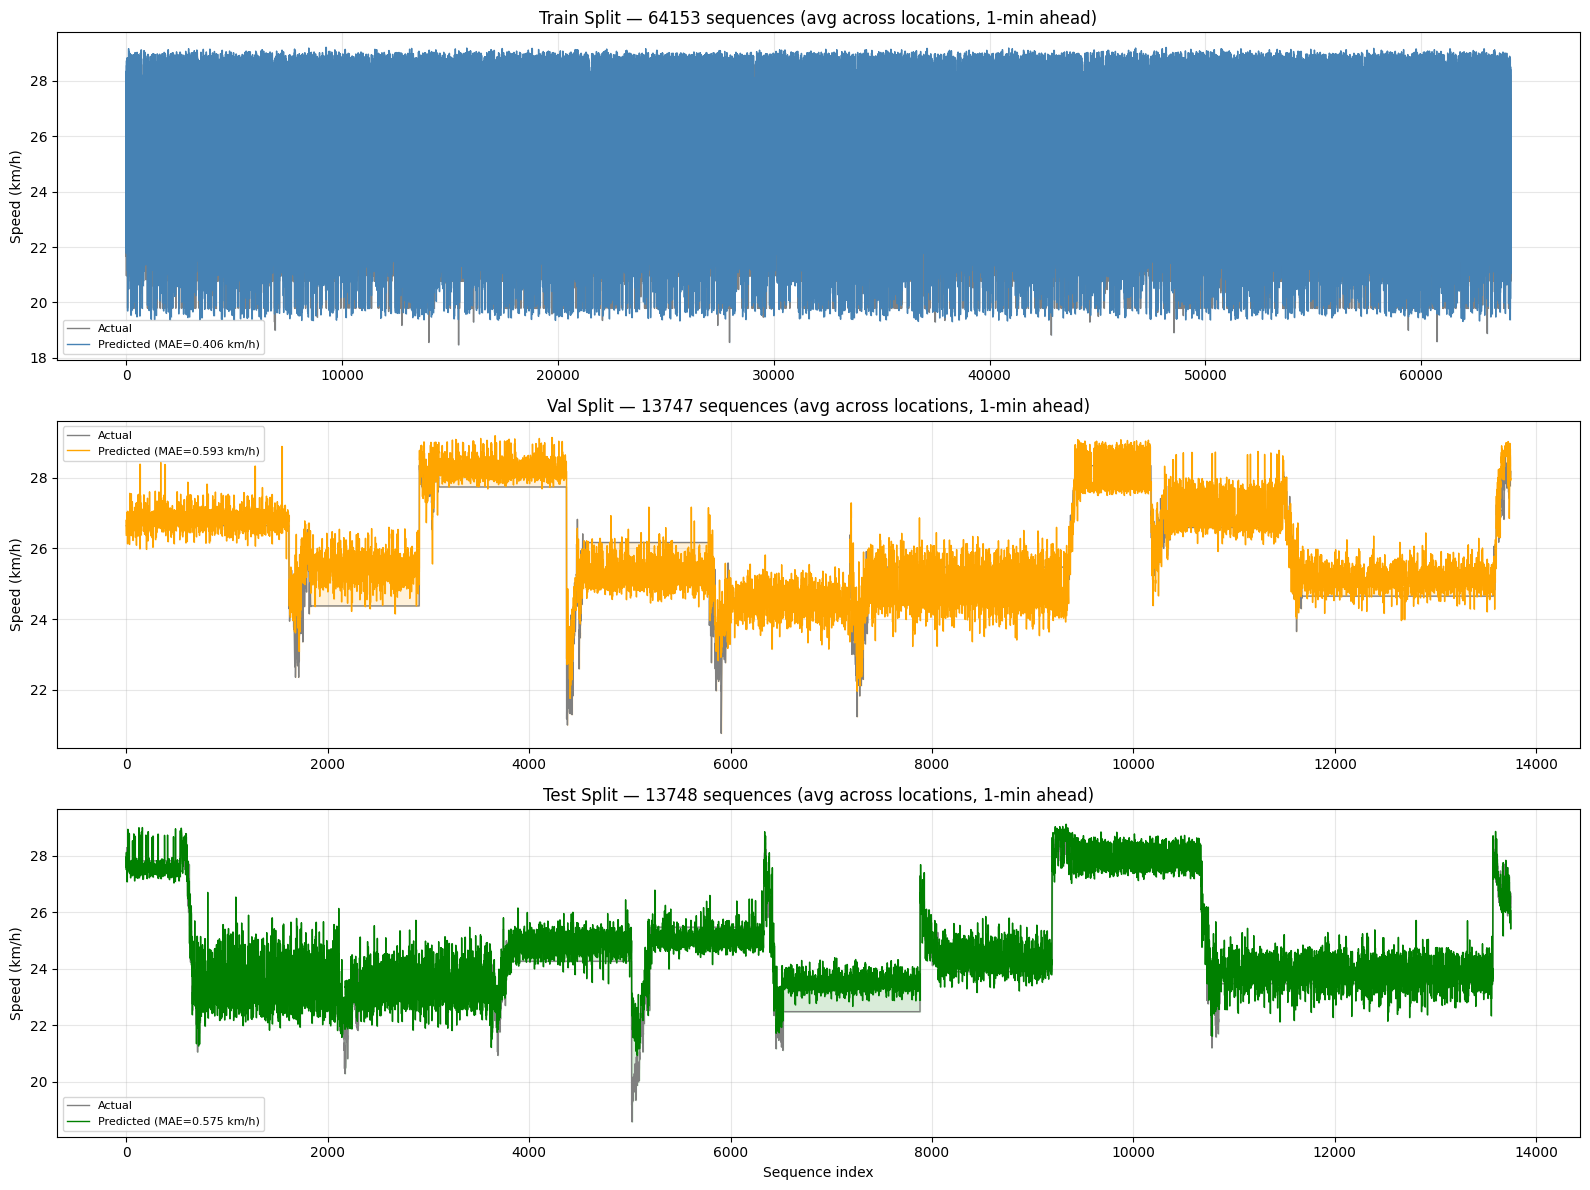

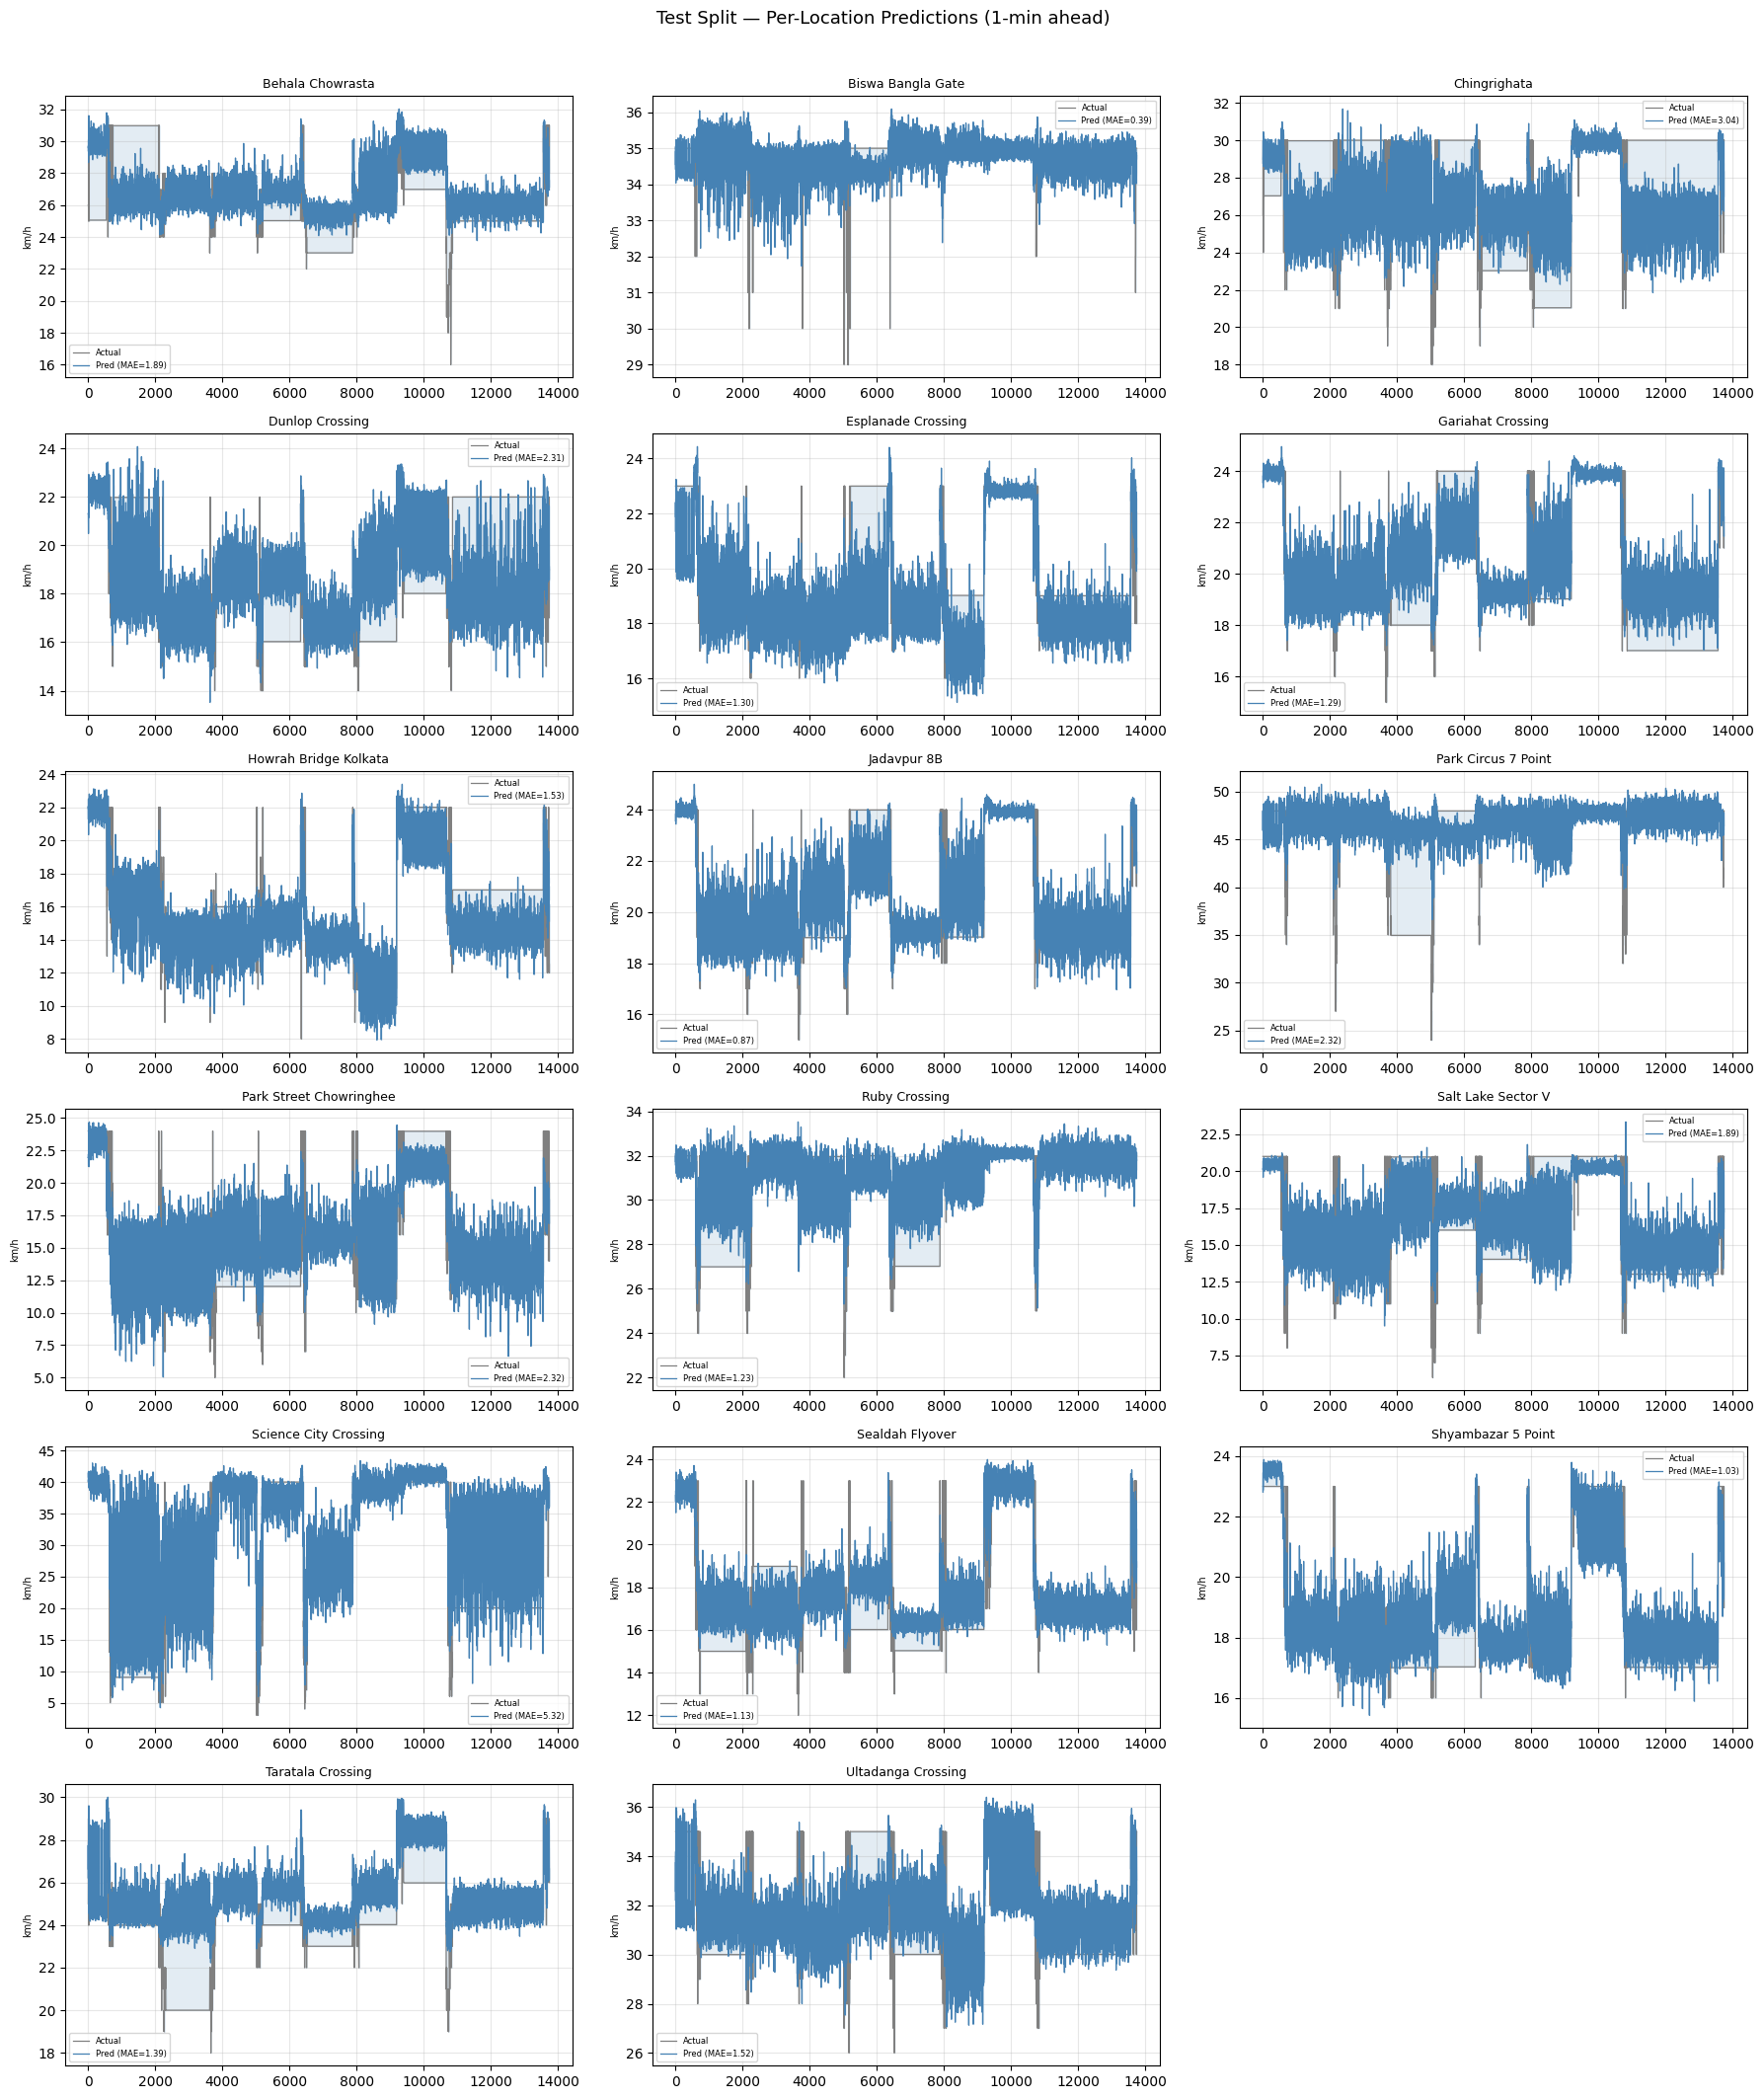

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            p_temp, _ = model(X, masks, edge_index, edge_weight)
            all_pred.append(p_temp.cpu().numpy())
            all_true.append(y_temp.numpy())
    pred = np.concatenate(all_pred)   # (S, L, N, F)
    true = np.concatenate(all_true)
    return pred, true

print("Collecting predictions for all splits...")
tr_pred, tr_true = get_predictions(train_loader)
vl_pred, vl_true = get_predictions(val_loader)
te_pred, te_true = get_predictions(test_loader)

sc = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

tr_p = inv(tr_pred[:,0,:,0]).mean(axis=1)   # (S_train,)
tr_t = inv(tr_true[:,0,:,0]).mean(axis=1)
vl_p = inv(vl_pred[:,0,:,0]).mean(axis=1)
vl_t = inv(vl_true[:,0,:,0]).mean(axis=1)
te_p = inv(te_pred[:,0,:,0]).mean(axis=1)
te_t = inv(te_true[:,0,:,0]).mean(axis=1)

full_pred = np.concatenate([tr_p, vl_p, te_p])
full_true = np.concatenate([tr_t, vl_t, te_t])
n_train, n_val, n_test = len(tr_p), len(vl_p), len(te_p)
total = n_train + n_val + n_test

hist_arr = np.array([[h['epoch'], h['train'], h['val']] for h in history_log])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_arr[:,0], hist_arr[:,1], label='Train Loss', color='steelblue', lw=1.5)
ax.plot(hist_arr[:,0], hist_arr[:,2], label='Val Loss',   color='tomato',    lw=1.5)
best_ep  = hist_arr[np.argmin(hist_arr[:,2]), 0]
best_val = hist_arr[:,2].min()
ax.axvline(best_ep, color='green', lw=1.2, ls='--', label=f'Best epoch {int(best_ep)} (val={best_val:.5f})')
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
t = np.arange(total)
ax.plot(t, full_true, color='gray',      lw=0.8, alpha=0.9, label='Actual speed (avg across locations)')
ax.plot(t, full_pred, color='steelblue', lw=0.8, alpha=0.8, label='Predicted speed')

ax.axvspan(0,       n_train,          alpha=0.07, color='steelblue', label='Train')
ax.axvspan(n_train, n_train+n_val,    alpha=0.10, color='orange',    label='Val')
ax.axvspan(n_train+n_val, total,      alpha=0.10, color='green',     label='Test')
ax.axvline(n_train,       color='orange', lw=1.2, ls='--')
ax.axvline(n_train+n_val, color='green',  lw=1.2, ls='--')

ax.set_title('Predicted vs Actual Speed — Full Timeline')
ax.set_xlabel('Sequence index (chronological)')
ax.set_ylabel('Speed (km/h)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/full_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
splits_data = [
    ('Train', tr_t, tr_p, 'steelblue'),
    ('Val',   vl_t, vl_p, 'orange'),
    ('Test',  te_t, te_p, 'green'),
]

for ax, (name, true_s, pred_s, color) in zip(axes, splits_data):
    n_show = min(800, len(true_s))
    # n_show = len(true_s)
    t = np.arange(n_show)
    mae_val = np.abs(pred_s[:n_show] - true_s[:n_show]).mean()
    ax.plot(t, true_s[:n_show], color='gray',  lw=1.0, label='Actual')
    ax.plot(t, pred_s[:n_show], color=color,   lw=1.0, label=f'Predicted (MAE={mae_val:.3f} km/h)')
    ax.fill_between(t, true_s[:n_show], pred_s[:n_show], alpha=0.15, color=color)
    ax.set_title(f'{name} Split — {n_show} sequences (avg across locations, 1-min ahead)')
    ax.set_ylabel('Speed (km/h)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sequence index')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_split_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

n_cols = 3
n_rows = int(np.ceil(len(locations) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]
    n_show = min(800, te_pred.shape[0])
    # n_show = te_pred.shape[0]
    true_loc = inv(te_true[:n_show, 0, i, 0]).flatten()
    pred_loc = inv(te_pred[:n_show, 0, i, 0]).flatten()
    mae_loc  = np.abs(true_loc - pred_loc).mean()

    ax.plot(true_loc, color='gray',      lw=0.9, label='Actual')
    ax.plot(pred_loc, color='steelblue', lw=0.9, label=f'Pred (MAE={mae_loc:.2f})')
    ax.fill_between(range(n_show), true_loc, pred_loc, alpha=0.15, color='steelblue')
    ax.set_title(loc.replace('_',' '), fontsize=9)
    ax.set_ylabel('km/h', fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

for j in range(len(locations), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Test Split — Per-Location Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_location_test.png', dpi=120, bbox_inches='tight')
plt.show()


r2 scattter plot
prediction vs the true for masked nodes

increase the future prediction time
rush or quite hours on daily basis

  PERFORMANCE METRICS — SPEED (km/h)
  
	TRAIN
  R2                  :   0.9450
  MAE                 :    0.406 km/h
  RMSE                :    0.543 km/h
  MAPE                :     1.69 %
  Bias (mean error)   :   +0.332 km/h
  Std of error        :    0.430 km/h
  Median abs error    :    0.319 km/h
  90th pct abs error  :    0.831 km/h
  Within  2 km/h      :    99.6 %
  Within  5 km/h      :   100.0 %
  Within 10 km/h      :   100.0 %
  
	VALIDATION
  R2                  :   0.6952
  MAE                 :    0.593 km/h
  RMSE                :    0.728 km/h
  MAPE                :     2.32 %
  Bias (mean error)   :   +0.080 km/h
  Std of error        :    0.724 km/h
  Median abs error    :    0.506 km/h
  90th pct abs error  :    1.172 km/h
  Within  2 km/h      :    99.4 %
  Within  5 km/h      :   100.0 %
  Within 10 km/h      :   100.0 %
  
	TEST
  R2                  :   0.8433
  MAE                 :    0.575 km/h
  RMSE                :    0.726 km/h
  MAPE                : 

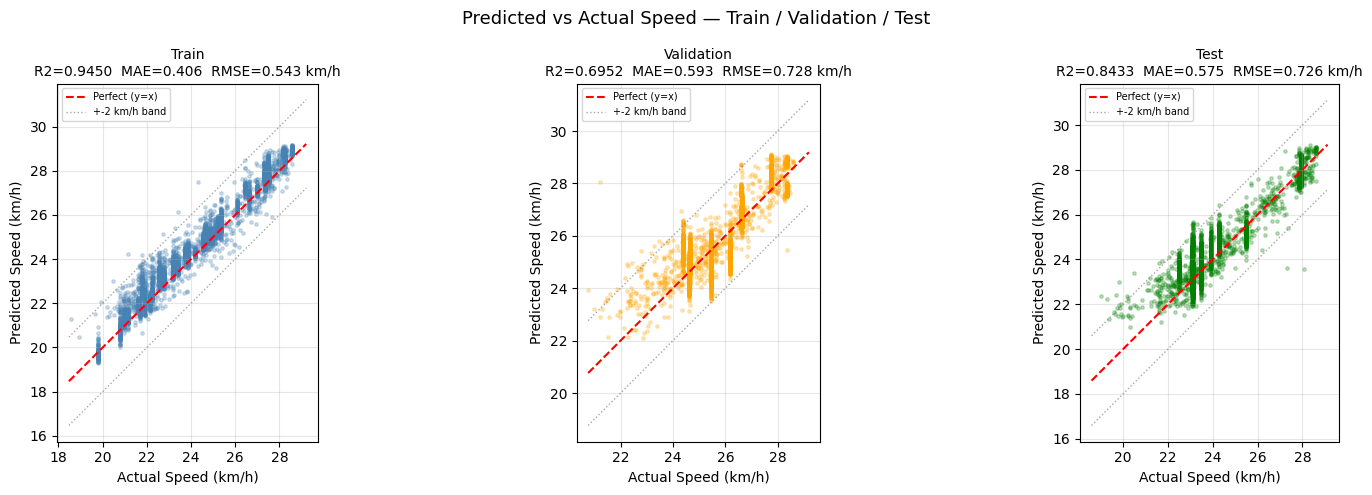

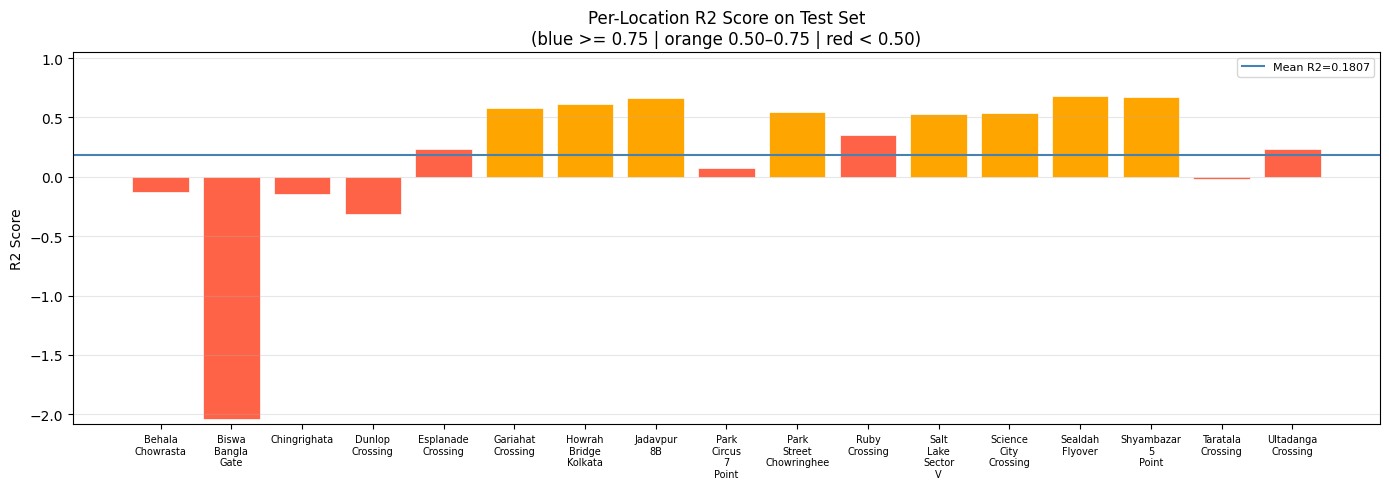

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def full_metrics(pred, true, name):
    mae   = mean_absolute_error(true, pred)
    rmse  = np.sqrt(mean_squared_error(true, pred))
    mape  = np.mean(np.abs((pred - true) / (true + 1e-6))) * 100
    r2    = r2_score(true, pred)
    bias  = np.mean(pred - true)
    std_e = np.std(pred - true)
    p50   = np.percentile(np.abs(pred - true), 50)   # median abs error
    p90   = np.percentile(np.abs(pred - true), 90)   # 90th pct abs error
    within2  = np.mean(np.abs(pred - true) < 2)  * 100
    within5  = np.mean(np.abs(pred - true) < 5)  * 100
    within10 = np.mean(np.abs(pred - true) < 10) * 100

    print(f"  {name}")
    print(f"  R2                  : {r2:>8.4f}")
    print(f"  MAE                 : {mae:>8.3f} km/h")
    print(f"  RMSE                : {rmse:>8.3f} km/h")
    print(f"  MAPE                : {mape:>8.2f} %")
    print(f"  Bias (mean error)   : {bias:>+8.3f} km/h")
    print(f"  Std of error        : {std_e:>8.3f} km/h")
    print(f"  Median abs error    : {p50:>8.3f} km/h")
    print(f"  90th pct abs error  : {p90:>8.3f} km/h")
    print(f"  Within  2 km/h      : {within2:>7.1f} %")
    print(f"  Within  5 km/h      : {within5:>7.1f} %")
    print(f"  Within 10 km/h      : {within10:>7.1f} %")

    return dict(r2=r2, mae=mae, rmse=rmse, mape=mape, bias=bias,
                std_e=std_e, p50=p50, p90=p90,
                w2=within2, w5=within5, w10=within10)

print("  PERFORMANCE METRICS — SPEED (km/h)")
m_tr = full_metrics(tr_p, tr_t, "\n\tTRAIN")
m_vl = full_metrics(vl_p, vl_t, "\n\tVALIDATION")
m_te = full_metrics(te_p, te_t, "\n\tTEST")

print("\n  PER-LOCATION R2 — TEST SET")
loc_r2 = []
for i, loc in enumerate(locations):
    p = inv(te_pred[:, 0, i, 0]).flatten()
    t = inv(te_true[:, 0, i, 0]).flatten()
    r = r2_score(t, p)
    loc_r2.append(r)
    bar = '|' * max(0, int(r * 20)) + '.' * max(0, 20 - int(r * 20))
    tag = ' <- best' if r == max(loc_r2) else ''
    print(f"  {loc:<28} {bar}  {r:.4f}{tag}")

worst_loc = locations[np.argmin(loc_r2)]
best_loc  = locations[np.argmax(loc_r2)]
print(f"\n  Best : {best_loc} (R2={max(loc_r2):.4f})")
print(f"  Worst: {worst_loc} (R2={min(loc_r2):.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

split_data = [
    ('Train',      tr_p, tr_t, m_tr, 'steelblue'),
    ('Validation', vl_p, vl_t, m_vl, 'orange'),
    ('Test',       te_p, te_t, m_te, 'green'),
]

for ax, (name, pred, true, m, color) in zip(axes, split_data):
    idx = np.random.choice(len(pred), min(5000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.25, s=6,
               color=color, rasterized=True)

    lim_min = min(true.min(), pred.min())
    lim_max = max(true.max(), pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='red', lw=1.5, ls='--', label='Perfect (y=x)')

    ax.plot([lim_min, lim_max], [lim_min+2, lim_max+2],
            color='gray', lw=1.0, ls=':', alpha=0.7, label='+-2 km/h band')
    ax.plot([lim_min, lim_max], [lim_min-2, lim_max-2],
            color='gray', lw=1.0, ls=':', alpha=0.7)

    ax.set_title(
        f'{name}\n'
        f'R2={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f} km/h',
        fontsize=10
    )
    ax.set_xlabel('Actual Speed (km/h)')
    ax.set_ylabel('Predicted Speed (km/h)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Speed — Train / Validation / Test', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/scatter_all_splits.png', dpi=130, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['tomato' if r < 0.5 else 'orange' if r < 0.75 else 'steelblue'
          for r in loc_r2]
ax.bar(range(len(locations)), loc_r2, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(loc_r2), color='steelblue', lw=1.5, ls='-',
           label=f'Mean R2={np.mean(loc_r2):.4f}')
ax.set_xticks(range(len(locations)))
ax.set_xticklabels([l.replace('_','\n') for l in locations], fontsize=7)
ax.set_ylabel('R2 Score')
ax.set_title('Per-Location R2 Score on Test Set\n(blue >= 0.75 | orange 0.50–0.75 | red < 0.50)')
ax.set_ylim(min(0, min(loc_r2)) - 0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_location_r2.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
def get_spatial_predictions(loader):
    model.eval()
    all_spat_pred, all_spat_true, all_masks = [], [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            _, p_spat = model(X, masks, edge_index, edge_weight)
            all_spat_pred.append(p_spat.cpu().numpy())
            all_spat_true.append(y_spat.numpy())
            all_masks.append(masks.cpu().numpy())
    return (np.concatenate(all_spat_pred),   # (S, N, F)
            np.concatenate(all_spat_true),
            np.concatenate(all_masks))# (S, N)

print("Collecting spatial predictions...")
tr_sp, tr_st, tr_mk = get_spatial_predictions(train_loader)
vl_sp, vl_st, vl_mk = get_spatial_predictions(val_loader)
te_sp, te_st, te_mk = get_spatial_predictions(test_loader)

sc  = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

def masked_only(pred, true, mask):
    """Extract only the (sample, node) pairs where mask==1."""
    idx_s, idx_n = np.where(mask == 1)   # sample indices, node indices
    p = inv(pred[idx_s, idx_n, 0].reshape(-1,1)).flatten()
    t = inv(true[idx_s, idx_n, 0].reshape(-1,1)).flatten()
    return p, t

tr_p, tr_t = masked_only(tr_sp, tr_st, tr_mk)
vl_p, vl_t = masked_only(vl_sp, vl_st, vl_mk)
te_p, te_t = masked_only(te_sp, te_st, te_mk)


Masked samples — Train: 240,652  Val: 51,472  Test: 51,335

Masked-node recovery metrics (spatial imputation):
  Train         R2=0.9467  MAE=1.196  RMSE=2.126  MAPE=6.61%  Bias=+0.341 km/h
  Validation    R2=0.9097  MAE=1.888  RMSE=2.771  MAPE=9.53%  Bias=-0.140 km/h
  Test          R2=0.8371  MAE=2.275  RMSE=3.617  MAPE=11.91%  Bias=+0.191 km/h


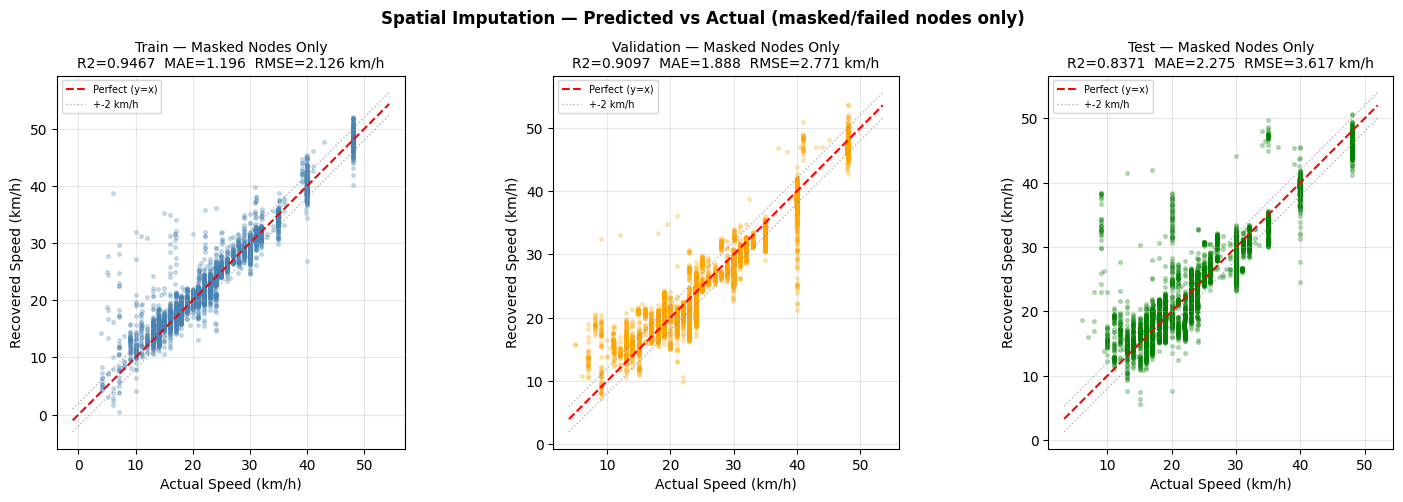

In [ ]:
print(f"Masked samples — Train: {len(tr_p):,}  Val: {len(vl_p):,}  Test: {len(te_p):,}")

def metrics(pred, true, name):
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((pred-true)/(true+1e-6)))*100
    bias = np.mean(pred - true)
    print(f"  {name:<12}  R2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%  Bias={bias:+.3f} km/h")
    return r2, mae, rmse

print("\nMasked-node recovery metrics (spatial imputation):")
r2_tr, mae_tr, rmse_tr = metrics(tr_p, tr_t, "Train")
r2_vl, mae_vl, rmse_vl = metrics(vl_p, vl_t, "Validation")
r2_te, mae_te, rmse_te = metrics(te_p, te_t, "Test")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = [
    ('Train', tr_p, tr_t, r2_tr, mae_tr, rmse_tr, 'steelblue'),
    ('Validation', vl_p, vl_t, r2_vl, mae_vl, rmse_vl, 'orange'),
    ('Test', te_p, te_t, r2_te, mae_te, rmse_te, 'green'),
]

for ax, (name, pred, true, r2, mae, rmse, color) in zip(axes, splits):
    idx = np.random.choice(len(pred), min(5000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.25, s=7, color=color, rasterized=True)

    lim_min = min(true.min(), pred.min())
    lim_max = max(true.max(), pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='red', lw=1.5, ls='--', label='Perfect (y=x)')
    ax.plot([lim_min, lim_max], [lim_min+2, lim_max+2],
            color='gray', lw=1.0, ls=':', alpha=0.6, label='+-2 km/h')
    ax.plot([lim_min, lim_max], [lim_min-2, lim_max-2],
            color='gray', lw=1.0, ls=':', alpha=0.6)

    ax.set_title(f'{name} — Masked Nodes Only\nR2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f} km/h',
                 fontsize=10)
    ax.set_xlabel('Actual Speed (km/h)')
    ax.set_ylabel('Recovered Speed (km/h)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Spatial Imputation — Predicted vs Actual (masked/failed nodes only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/scatter_masked_nodes.png', dpi=130, bbox_inches='tight')
plt.show()

#masked nodes remain masked throughout

In [ ]:
#Choose fixed masked nodes before creating sequences
rng_fixed = np.random.RandomState(42)
mask_prob = rng_fixed.uniform(0.45, 0.55)
n_masked  = max(1, int(N * mask_prob))
FIXED_MASKED_NODES = rng_fixed.choice(N, size=n_masked, replace=False)

print(f"Fixed masked nodes ({len(FIXED_MASKED_NODES)}):")
for n in FIXED_MASKED_NODES:
    print(f"  [{n}] {locations[n]}")

# Fixed mask vector
fixed_mask = np.zeros(N_LOCS, dtype=np.float32)
fixed_mask[FIXED_MASKED_NODES] = 1.0

def create_sequences_fixed_mask(data, history_len, forecast_len, mask):
    T, N, F = data.shape
    X_history, X_masks, y_temporal, y_spatial = [], [], [], []

    for t in range(history_len, T - forecast_len + 1):
        history = data[t-history_len:t].copy()
        future  = data[t:t+forecast_len].copy()

        if np.isnan(history).any() or np.isnan(future).any():
            continue

        history_masked = history.copy()
        history_masked[:, mask == 1, :] = 0.0   # same nodes zeroed every time

        X_history.append(history_masked)
        X_masks.append(mask)
        y_temporal.append(future)
        y_spatial.append(data[t-1])

    return {'X_history': np.array(X_history, dtype=np.float32),
            'X_masks':   np.array(X_masks,   dtype=np.float32),
            'y_temporal':np.array(y_temporal, dtype=np.float32),
            'y_spatial': np.array(y_spatial,  dtype=np.float32)}

sequences = create_sequences_fixed_mask(data_matrix, HISTORY_LEN, FORECAST_LEN, fixed_mask)

Fixed masked nodes (8):
  [0] Behala_Chowrasta
  [1] Biswa_Bangla_Gate
  [8] Park_Circus_7_Point
  [5] Gariahat_Crossing
  [3] Dunlop_Crossing
  [13] Sealdah_Flyover
  [16] Ultadanga_Crossing
  [15] Taratala_Crossing


In [ ]:
# def create_sequences_with_masking(
#     data,           # (T, N, F)
#     history_len,
#     forecast_len,
#     mask_prob_range=(0.1, 0.4),  # randomly mask 10-40% of nodes
#     seed=42
# ):
#     """
#     Creates sequences for BOTH tasks simultaneously:
#     - Input: history with some nodes randomly zeroed out (spatial imputation task)
#     - Target temporal: full future values
#     - Target spatial: the masked values at current time (reconstruction task)
#     """
#     rng = np.random.RandomState(seed)
#     T, N, F = data.shape

#     X_history = []      # (history_len, N, F) — some nodes masked
#     X_masks = []        # (N,) — which nodes are masked (1=masked, 0=visible)
#     y_temporal = []     # (forecast_len, N, F) — future values for ALL nodes
#     y_spatial = []      # (N, F) — current values for masked nodes (reconstruction)

#     for t in range(history_len, T - forecast_len + 1):
#         history = data[t - history_len : t].copy()         # (H, N, F)
#         future = data[t : t + forecast_len].copy()         # (L, N, F)

#         if np.isnan(history).any() or np.isnan(future).any():
#             continue

#         # Randomly decide how many nodes to mask
#         mask_prob = rng.uniform(*mask_prob_range)
#         n_masked = max(1, int(N * mask_prob))
#         masked_nodes = rng.choice(N, size=n_masked, replace=False)

#         # Create mask vector
#         mask = np.zeros(N, dtype=np.float32)
#         mask[masked_nodes] = 1.0

#         # Zero out masked nodes in history (simulate sensor failure)
#         history_masked = history.copy()
#         history_masked[:, masked_nodes, :] = 0.0

#         X_history.append(history_masked)
#         X_masks.append(mask)
#         y_temporal.append(future)
#         y_spatial.append(data[t - 1])  # ground truth at last history step for reconstruction

#     return {
#         'X_history': np.array(X_history, dtype=np.float32),   # (S, H, N, F)
#         'X_masks': np.array(X_masks, dtype=np.float32),       # (S, N)
#         'y_temporal': np.array(y_temporal, dtype=np.float32), # (S, L, N, F)
#         'y_spatial': np.array(y_spatial, dtype=np.float32),   # (S, N, F)
#     }

# sequences = create_sequences_with_masking(data_matrix, HISTORY_LEN, FORECAST_LEN)

S = len(sequences['X_history'])
print(f"Created {S} sequences")
print(f"  X_history: {sequences['X_history'].shape}")
print(f"  X_masks:   {sequences['X_masks'].shape}")
print(f"  y_temporal:{sequences['y_temporal'].shape}")
print(f"  y_spatial: {sequences['y_spatial'].shape}")

# Train / Val / Test split — 70 / 15 / 15
train_end = int(0.70 * S)
val_end = int(0.85 * S)

splits = {
    'train': {k: v[:train_end] for k, v in sequences.items()},
    'val':   {k: v[train_end:val_end] for k, v in sequences.items()},
    'test':  {k: v[val_end:] for k, v in sequences.items()},
}

for split, data in splits.items():
    print(f"{split}: {len(data['X_history'])} sequences")

# Save processed data
np.savez_compressed(
    f'{PROJECT_DIR}/data/processed/sequences.npz',
    **{f'{split}_{k}': v for split, d in splits.items() for k, v in d.items()}
)
print("\n Sequences saved to Drive")

Created 91648 sequences
  X_history: (91648, 30, 17, 3)
  X_masks:   (91648, 17)
  y_temporal:(91648, 15, 17, 3)
  y_spatial: (91648, 17, 3)
train: 64153 sequences
val: 13747 sequences
test: 13748 sequences

 Sequences saved to Drive


In [ ]:
import torch
from torch_geometric.data import Data

def build_pyg_graph(adjacency, distance_matrix, location_coords):
    """
    Convert adjacency matrix to PyTorch Geometric edge format.
    Edge weights = inverse distance (closer = stronger connection).
    """
    N = adjacency.shape[0]

    edge_index = []
    edge_weight = []

    for i in range(N):
        for j in range(N):
            if adjacency[i, j] == 1 and i != j:
                edge_index.append([i, j])
                dist = distance_matrix[i, j]
                # Inverse distance weighting; closer nodes have stronger edges
                weight = 1.0 / (dist + 1e-6)
                edge_weight.append(weight)

    edge_index = torch.tensor(edge_index, dtype=torch.long).T  # (2, E)
    edge_weight = torch.tensor(edge_weight, dtype=torch.float32)

    edge_weight = edge_weight / edge_weight.max()

    # Node features: lat/lon as initial node features
    node_features = torch.tensor(location_coords, dtype=torch.float32)

    graph = Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_weight
    )

    print(f"Graph built:")
    print(f"  Nodes: {graph.num_nodes}")
    print(f"  Edges: {graph.num_edges}")
    print(f"  Avg degree: {graph.num_edges / graph.num_nodes:.1f}")

    return graph

npz = np.load('/content/kolkata_traffic_stllm_ready.npz',
              allow_pickle=True)

graph = build_pyg_graph(
    adjacency=npz['adjacency'],
    distance_matrix=npz['distance_matrix'],
    location_coords=npz['location_coords']
)

torch.save(graph, f'{PROJECT_DIR}/data/processed/road_graph.pt')
print(" Graph saved")

Graph built:
  Nodes: 17
  Edges: 60
  Avg degree: 3.5
 Graph saved


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from transformers import GPT2Model, GPT2Config
from peft import get_peft_model, LoraConfig, TaskType

# Component 1: Spatial Encoder (GAT)

class SpatialEncoder(nn.Module):
    """
    Graph Attention Network that encodes spatial relationships.
    For masked (failed) nodes, it reconstructs from neighbors.
    """
    def __init__(self, in_features, hidden_dim, out_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.gat1 = GATConv(in_features, hidden_dim, heads=n_heads,
                            dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden_dim * n_heads, out_dim, heads=1,
                            dropout=dropout, concat=False)
        self.norm1 = nn.LayerNorm(hidden_dim * n_heads)
        self.norm2 = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight, mask=None):
        """
        x: (B*N, F) — node features
        edge_index: (2, E)
        edge_weight: (E,)
        mask: (B*N,) — 1 where node is failed/masked
        """
        # If node is masked, zero its input (model must infer from neighbors)
        if mask is not None:
            x = x * (1 - mask.unsqueeze(-1))

        h = self.gat1(x, edge_index, edge_weight)
        h = self.norm1(F.elu(h))
        h = self.dropout(h)
        h = self.gat2(h, edge_index, edge_weight)
        h = self.norm2(F.elu(h))
        return h  # (B*N, out_dim)'''

    '''def forward(self, x, edge_index, edge_weight, mask=None):
        residual = x.clone()

        if mask is not None:
            x = x * (1 - mask.unsqueeze(-1))

        h = self.gat1(x, edge_index, edge_weight)
        h = self.norm1(F.elu(h))
        h = self.dropout(h)
        h = self.gat2(h, edge_index, edge_weight)
        h = self.norm2(F.elu(h))

        # This lets the node use its own history even when neighbours are weak
        if not hasattr(self, 'residual_proj'):
            self.residual_proj = nn.Linear(
                residual.shape[-1], h.shape[-1]
            ).to(h.device)

        h = h + self.residual_proj(residual * (1 - mask.unsqueeze(-1) if mask is not None else 1))
        return h'''


# Component 2: Temporal Encoder (GPT-2 + LoRA)

def build_lora_gpt2(gpt2_embed_dim=768, lora_r=8, lora_alpha=16):
    """
    Load GPT-2 small and apply LoRA for efficient fine-tuning.
    """
    config = GPT2Config(
        n_embd=gpt2_embed_dim,
        n_layer=6,       # Use 6 layers instead of 12 to fit T4
        n_head=12,
        n_positions=512,
        vocab_size=50257
    )
    gpt2 = GPT2Model(config)

    # LoRA config — only fine-tune attention query and value projections
    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["c_attn"],  # GPT-2's combined QKV projection
        lora_dropout=0.05,
        bias="none",
        fan_in_fan_out=True
    )

    gpt2 = get_peft_model(gpt2, lora_config)
    gpt2.print_trainable_parameters()

    return gpt2


# Component 3: Full ST-LLM Model

class TrafficSTLLM(nn.Module):
    def __init__(
        self,
        n_locations,      # N
        n_features,       # F = 3
        history_len,      # H
        forecast_len,     # L
        spatial_hidden=64,
        spatial_out=128,
        gpt2_dim=768,
        lora_r=8,
        dropout=0.1
    ):
        super().__init__()

        self.N = n_locations
        self.F = n_features
        self.H = history_len
        self.L = forecast_len
        self.gpt2_dim = gpt2_dim

        # Spatial encoder per timestep
        self.spatial_encoder = SpatialEncoder(
            in_features=n_features,
            hidden_dim=spatial_hidden,
            out_dim=spatial_out,
            n_heads=4,
            dropout=dropout
        )

        # Project spatial output → GPT-2 input dimension
        # GPT-2 sees one "token" per timestep, each token = ALL nodes aggregated
        self.spatial_to_token = nn.Linear(spatial_out * n_locations, gpt2_dim)

        # GPT-2 with LoRA
        self.gpt2 = build_lora_gpt2(gpt2_dim, lora_r)

        # Output heads
        # Temporal head: predict future for all nodes
        self.temporal_head = nn.Sequential(
            nn.Linear(gpt2_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_len * n_locations * n_features)
        )

        # Spatial head: reconstruct masked nodes at current time
        self.spatial_head = nn.Sequential(
            nn.Linear(gpt2_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_locations * n_features)
        )

    def forward(self, x_history, mask, edge_index, edge_weight):
        """
        x_history: (B, H, N, F)
        mask: (B, N) — 1 = node failed
        edge_index: (2, E)
        edge_weight: (E,)

        Returns:
            y_temporal_pred: (B, L, N, F)
            y_spatial_pred: (B, N, F)
        """
        B, H, N, F = x_history.shape

        token_sequence = []

        for t in range(H):
            x_t = x_history[:, t, :, :]  # (B, N, F)

            x_flat = x_t.reshape(B * N, F)
            mask_flat = mask.reshape(B * N)

            batch_edge_index, batch_edge_weight = self._batch_graph(
                edge_index, edge_weight, B, N
            )

            spatial_out = self.spatial_encoder(
                x_flat, batch_edge_index, batch_edge_weight, mask_flat
            )  # (B*N, spatial_out)

            spatial_out = spatial_out.reshape(B, N * self.spatial_encoder.gat2.out_channels)
            token = self.spatial_to_token(spatial_out)  # (B, gpt2_dim)
            token_sequence.append(token)

        # Stack to sequence: (B, H, gpt2_dim)
        token_sequence = torch.stack(token_sequence, dim=1)

        gpt2_out = self.gpt2(inputs_embeds=token_sequence)
        hidden = gpt2_out.last_hidden_state  # (B, H, gpt2_dim)

        last_hidden = hidden[:, -1, :]  # (B, gpt2_dim)

        # Temporal prediction
        temporal_flat = self.temporal_head(last_hidden)  # (B, L*N*F)
        y_temporal = temporal_flat.reshape(B, self.L, N, F)

        # Spatial reconstruction
        spatial_flat = self.spatial_head(last_hidden)  # (B, N*F)
        y_spatial = spatial_flat.reshape(B, N, F)

        return y_temporal, y_spatial

    def _batch_graph(self, edge_index, edge_weight, batch_size, n_nodes):
        edge_indices = []
        for b in range(batch_size):
            edge_indices.append(edge_index + b * n_nodes)
        batch_edge_index = torch.cat(edge_indices, dim=1)
        batch_edge_weight = edge_weight.repeat(batch_size)
        return batch_edge_index, batch_edge_weight

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TrafficDataset(Dataset):
    def __init__(self, sequences):
        self.X = torch.tensor(sequences['X_history'], dtype=torch.float32)
        self.masks = torch.tensor(sequences['X_masks'], dtype=torch.float32)
        self.y_temp = torch.tensor(sequences['y_temporal'], dtype=torch.float32)
        self.y_spat = torch.tensor(sequences['y_spatial'], dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.masks[idx], self.y_temp[idx], self.y_spat[idx]

BATCH_SIZE = 32

train_loader = DataLoader(TrafficDataset(splits['train']),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TrafficDataset(splits['val']),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TrafficDataset(splits['test']),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2005
Val batches:   430
Test batches:  430


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TrafficSTLLM(
    n_locations=N_LOCS,
    n_features=3,
    history_len=HISTORY_LEN,
    forecast_len=FORECAST_LEN,
    spatial_hidden=64,
    spatial_out=128,
    gpt2_dim=768,
    lora_r=8,
    dropout=0.1
).to(device)

edge_index = graph.edge_index.to(device)
edge_weight = graph.edge_attr.to(device)

'''def combined_loss(y_temp_pred, y_temp_true, y_spat_pred, y_spat_true,
                  mask, alpha=0.7):
    """
    alpha: weight on temporal loss (1-alpha on spatial)
    For masked nodes only, compute spatial loss
    """
    temp_loss = F.mse_loss(y_temp_pred, y_temp_true)

    # mask: (B, N), expand to (B, N, F)
    mask_expanded = mask.unsqueeze(-1).expand_as(y_spat_true)
    if mask_expanded.sum() > 0:
        spat_loss = F.mse_loss(
            y_spat_pred * mask_expanded,
            y_spat_true * mask_expanded
        )
    else:
        spat_loss = torch.tensor(0.0, device=device)

    return alpha * temp_loss + (1 - alpha) * spat_loss, temp_loss, spat_loss'''



def combined_loss(y_temp_pred, y_temp_true, y_spat_pred, y_spat_true, mask, alpha=0.7):

    speed_true = y_temp_true[..., 0]

    speed_weights = 1.0 + torch.sigmoid(speed_true)

    # Weighted temporal loss
    temp_err = (y_temp_pred - y_temp_true) ** 2
    temp_loss = (temp_err * speed_weights.unsqueeze(-1)).mean()

    # Spatial loss (masked nodes only)
    mask_expanded = mask.unsqueeze(-1).expand_as(y_spat_true)
    if mask_expanded.sum() > 0:
        spat_err = (y_spat_pred - y_spat_true) ** 2
        spat_weights = (1.0 + torch.sigmoid(y_spat_true[..., 0])).unsqueeze(-1)
        spat_loss = (spat_err * spat_weights * mask_expanded).sum() / (mask_expanded.sum() + 1e-6)
    else:
        spat_loss = torch.tensor(0.0, device=y_temp_pred.device)

    total = alpha * temp_loss + (1 - alpha) * spat_loss
    return total, temp_loss, spat_loss




optimizer = torch.optim.AdamW([
    {'params': model.spatial_encoder.parameters(), 'lr': 1e-3},
    {'params': model.spatial_to_token.parameters(), 'lr': 1e-3},
    {'params': model.gpt2.parameters(), 'lr': 5e-5},
    {'params': model.temporal_head.parameters(), 'lr': 1e-3},
    {'params': model.spatial_head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6
)

scaler_amp = torch.amp.GradScaler('cuda')

EPOCHS = 50
PATIENCE = 10  # Early stopping
best_val_loss = float('inf')
patience_counter = 0
history_log = []

CHECKPOINT_PATH = f'{PROJECT_DIR}/checkpoints/best_model.pt'

print("Starting training...")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for X, masks, y_temp, y_spat in train_loader:
        X, masks = X.to(device), masks.to(device)
        y_temp, y_spat = y_temp.to(device), y_spat.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)
            loss, tl, sl = combined_loss(pred_temp, y_temp, pred_spat, y_spat, masks)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for X, masks, y_temp, y_spat in val_loader:
            X, masks = X.to(device), masks.to(device)
            y_temp, y_spat = y_temp.to(device), y_spat.to(device)

            with torch.amp.autocast('cuda'):
                pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)
                loss, tl, sl = combined_loss(pred_temp, y_temp, pred_spat, y_spat, masks)

            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    scheduler.step()

    history_log.append({'epoch': epoch, 'train': train_loss, 'val': val_loss})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': val_loss,
            'config': {
                'n_locations': N_LOCS, 'n_features': 3,
                'history_len': HISTORY_LEN, 'forecast_len': FORECAST_LEN
            }
        }, CHECKPOINT_PATH)
        print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} saved")
    else:
        patience_counter += 1
        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\n Training complete. Best val loss: {best_val_loss:.4f}")

trainable params: 147,456 || all params: 81,666,816 || trainable%: 0.1806
Starting training...
Device: cuda
Model parameters: 83,872,688
Trainable: 2,353,328
Epoch   1 | Train: 0.0482 | Val: 0.0544 saved
Epoch   5 | Train: 0.0174 | Val: 0.0629 | Patience: 4/10
Epoch  10 | Train: 0.0147 | Val: 0.0649 | Patience: 9/10

Early stopping at epoch 11

 Training complete. Best val loss: 0.0544


In [ ]:
def evaluate(model, loader, edge_index, edge_weight, scalers, device):
    model.eval()

    all_temp_pred, all_temp_true = [], []
    all_spat_pred, all_spat_true, all_masks = [], [], []

    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            y_temp, y_spat = y_temp.to(device), y_spat.to(device)

            pred_temp, pred_spat = model(X, masks, edge_index, edge_weight)

            all_temp_pred.append(pred_temp.cpu())
            all_temp_true.append(y_temp.cpu())
            all_spat_pred.append(pred_spat.cpu())
            all_spat_true.append(y_spat.cpu())
            all_masks.append(masks.cpu())

    temp_pred = torch.cat(all_temp_pred).numpy()
    temp_true = torch.cat(all_temp_true).numpy()
    spat_pred = torch.cat(all_spat_pred).numpy()
    spat_true = torch.cat(all_spat_true).numpy()
    masks = torch.cat(all_masks).numpy()

    s = scalers['current_speed']

    def inv(x): return s.inverse_transform(x.reshape(-1, 1)).reshape(x.shape)

    tp_speed = inv(temp_pred[..., 0])
    tt_speed = inv(temp_true[..., 0])
    sp_speed = inv(spat_pred[..., 0])
    st_speed = inv(spat_true[..., 0])

    # Temporal metrics
    mae_temp = np.abs(tp_speed - tt_speed).mean()
    rmse_temp = np.sqrt(((tp_speed - tt_speed)**2).mean())
    mape_temp = (np.abs((tp_speed - tt_speed) / (tt_speed + 1e-6))).mean() * 100

    # Spatial metrics — only on masked nodes
    spatial_mae_vals = []
    for i in range(len(masks)):
        masked_nodes = np.where(masks[i] == 1)[0]
        if len(masked_nodes) > 0:
            err = np.abs(sp_speed[i, masked_nodes] - st_speed[i, masked_nodes])
            spatial_mae_vals.extend(err.tolist())

    mae_spat = np.mean(spatial_mae_vals)

    print("TEMPORAL PREDICTION (all nodes)")
    print(f"  MAE:  {mae_temp:.3f} km/h")
    print(f"  RMSE: {rmse_temp:.3f} km/h")
    print(f"  MAPE: {mape_temp:.2f}%")
    print("\nSPATIAL IMPUTATION (failed nodes only)")
    print(f"  MAE:  {mae_spat:.3f} km/h")

    return temp_pred, temp_true, spat_pred, spat_true, masks

checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state'])

temp_pred, temp_true, spat_pred, spat_true, masks = evaluate(
    model, test_loader, edge_index, edge_weight, scalers, device
)

TEMPORAL PREDICTION (all nodes)
  MAE:  1.612 km/h
  RMSE: 2.483 km/h
  MAPE: 7.59%

SPATIAL IMPUTATION (failed nodes only)
  MAE:  1.736 km/h


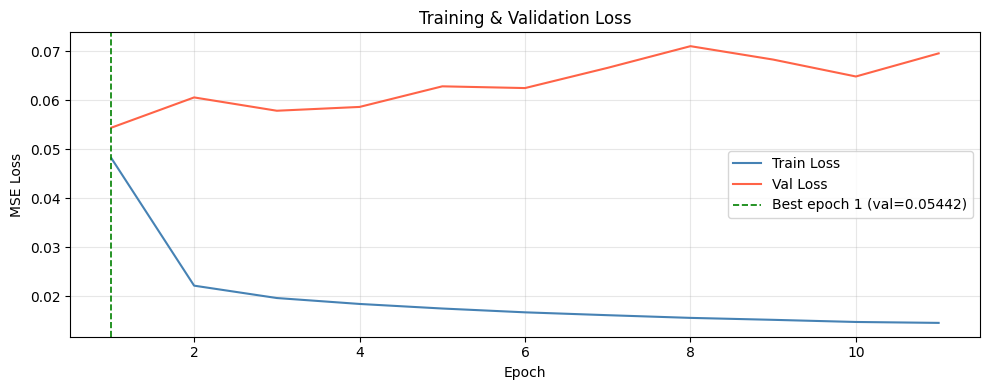

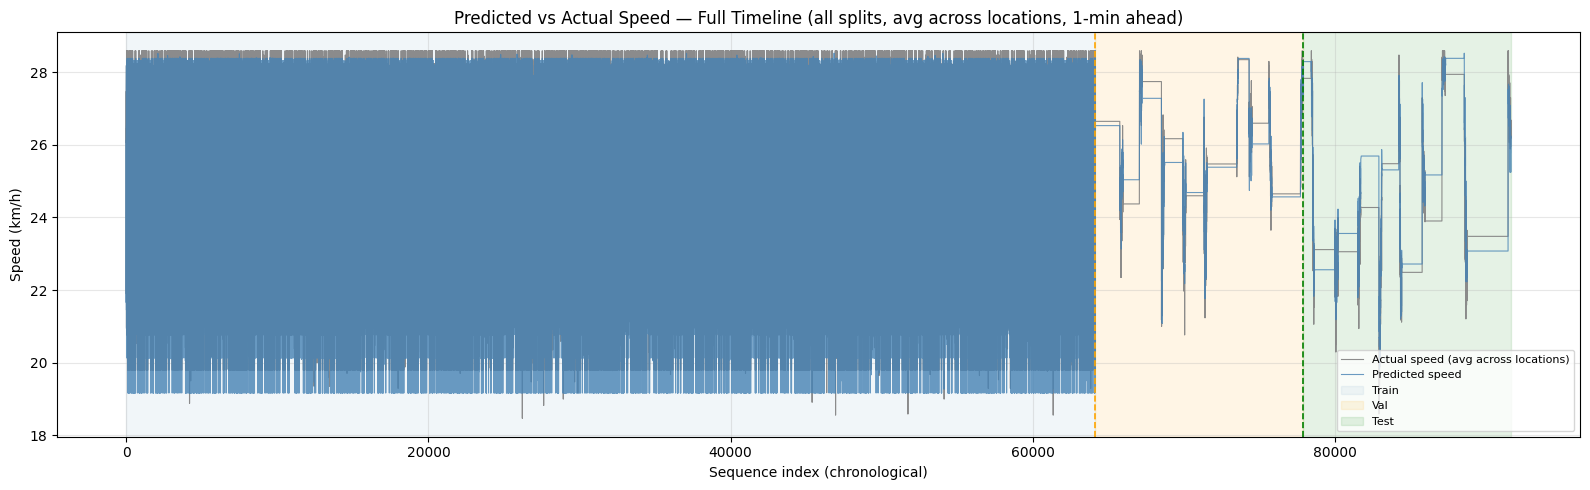

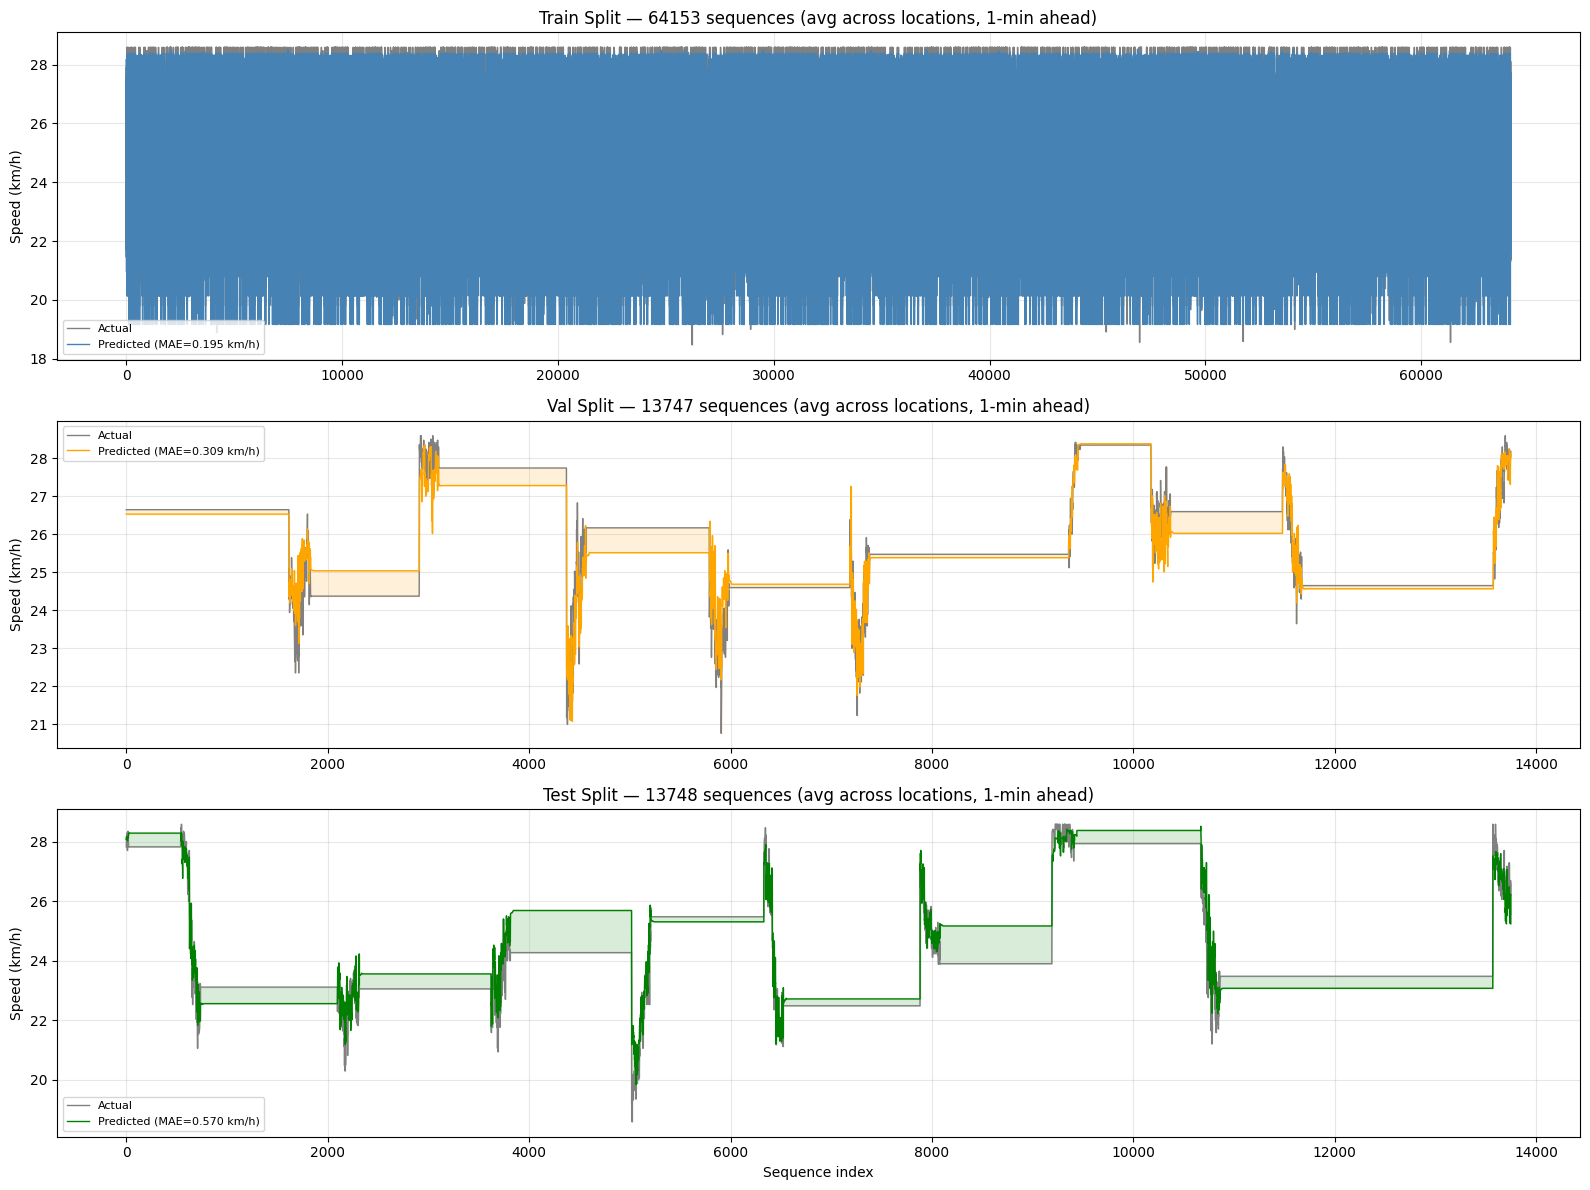

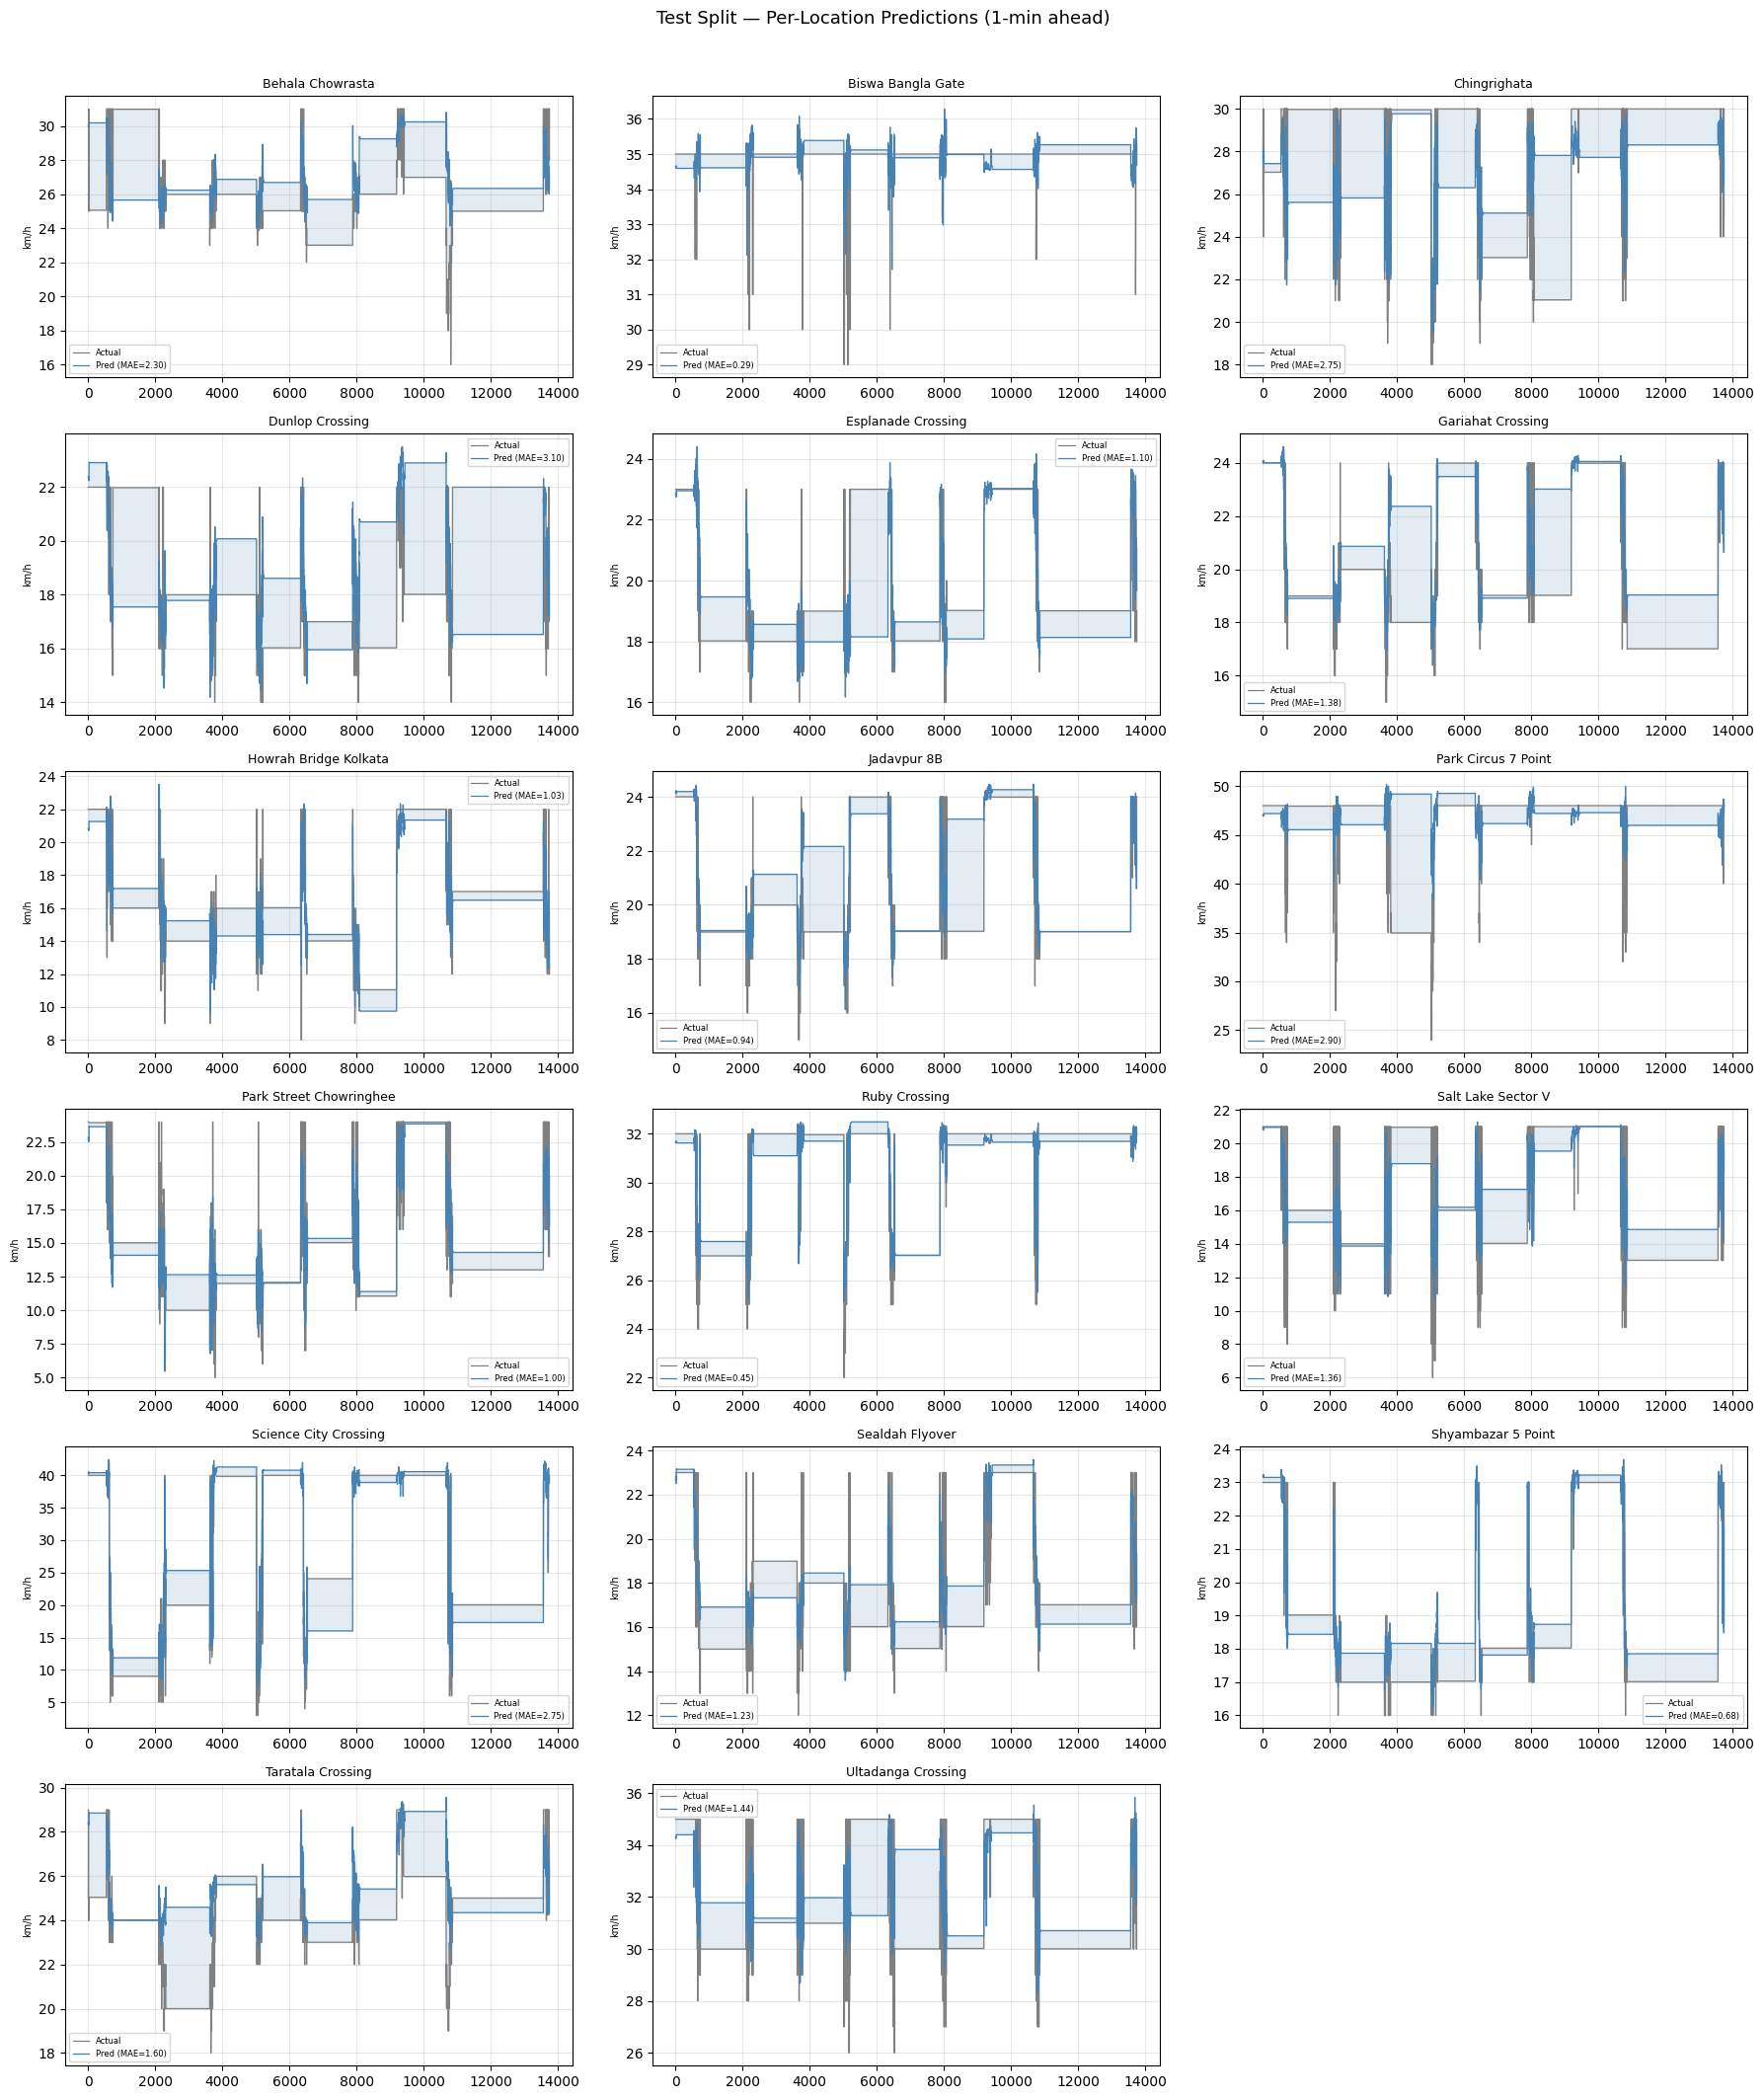

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            p_temp, _ = model(X, masks, edge_index, edge_weight)
            all_pred.append(p_temp.cpu().numpy())
            all_true.append(y_temp.numpy())
    pred = np.concatenate(all_pred)   # (S, L, N, F)
    true = np.concatenate(all_true)
    return pred, true

print("Collecting predictions for all splits...")
tr_pred, tr_true = get_predictions(train_loader)
vl_pred, vl_true = get_predictions(val_loader)
te_pred, te_true = get_predictions(test_loader)

sc = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

tr_p = inv(tr_pred[:,0,:,0]).mean(axis=1)   # (S_train,)
tr_t = inv(tr_true[:,0,:,0]).mean(axis=1)
vl_p = inv(vl_pred[:,0,:,0]).mean(axis=1)
vl_t = inv(vl_true[:,0,:,0]).mean(axis=1)
te_p = inv(te_pred[:,0,:,0]).mean(axis=1)
te_t = inv(te_true[:,0,:,0]).mean(axis=1)

full_pred = np.concatenate([tr_p, vl_p, te_p])
full_true = np.concatenate([tr_t, vl_t, te_t])
n_train, n_val, n_test = len(tr_p), len(vl_p), len(te_p)
total = n_train + n_val + n_test

hist_arr = np.array([[h['epoch'], h['train'], h['val']] for h in history_log])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_arr[:,0], hist_arr[:,1], label='Train Loss', color='steelblue', lw=1.5)
ax.plot(hist_arr[:,0], hist_arr[:,2], label='Val Loss',   color='tomato',    lw=1.5)
best_ep  = hist_arr[np.argmin(hist_arr[:,2]), 0]
best_val = hist_arr[:,2].min()
ax.axvline(best_ep, color='green', lw=1.2, ls='--', label=f'Best epoch {int(best_ep)} (val={best_val:.5f})')
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
t = np.arange(total)
ax.plot(t, full_true, color='gray',      lw=0.8, alpha=0.9, label='Actual speed (avg across locations)')
ax.plot(t, full_pred, color='steelblue', lw=0.8, alpha=0.8, label='Predicted speed')

ax.axvspan(0,       n_train,          alpha=0.07, color='steelblue', label='Train')
ax.axvspan(n_train, n_train+n_val,    alpha=0.10, color='orange',    label='Val')
ax.axvspan(n_train+n_val, total,      alpha=0.10, color='green',     label='Test')
ax.axvline(n_train,       color='orange', lw=1.2, ls='--')
ax.axvline(n_train+n_val, color='green',  lw=1.2, ls='--')

ax.set_title('Predicted vs Actual Speed — Full Timeline (all splits, avg across locations, 1-min ahead)')
ax.set_xlabel('Sequence index (chronological)')
ax.set_ylabel('Speed (km/h)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/full_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
splits_data = [
    ('Train', tr_t, tr_p, 'steelblue'),
    ('Val',   vl_t, vl_p, 'orange'),
    ('Test',  te_t, te_p, 'green'),
]

for ax, (name, true_s, pred_s, color) in zip(axes, splits_data):
    n_show = min(300, len(true_s))
    n_show = len(true_s)
    t = np.arange(n_show)
    mae_val = np.abs(pred_s[:n_show] - true_s[:n_show]).mean()
    ax.plot(t, true_s[:n_show], color='gray',  lw=1.0, label='Actual')
    ax.plot(t, pred_s[:n_show], color=color,   lw=1.0, label=f'Predicted (MAE={mae_val:.3f} km/h)')
    ax.fill_between(t, true_s[:n_show], pred_s[:n_show], alpha=0.15, color=color)
    ax.set_title(f'{name} Split — {n_show} sequences (avg across locations, 1-min ahead)')
    ax.set_ylabel('Speed (km/h)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sequence index')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_split_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

n_cols = 3
n_rows = int(np.ceil(len(locations) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]
    n_show = min(200, te_pred.shape[0])
    n_show = te_pred.shape[0]
    true_loc = inv(te_true[:n_show, 0, i, 0]).flatten()
    pred_loc = inv(te_pred[:n_show, 0, i, 0]).flatten()
    mae_loc  = np.abs(true_loc - pred_loc).mean()

    ax.plot(true_loc, color='gray',      lw=0.9, label='Actual')
    ax.plot(pred_loc, color='steelblue', lw=0.9, label=f'Pred (MAE={mae_loc:.2f})')
    ax.fill_between(range(n_show), true_loc, pred_loc, alpha=0.15, color='steelblue')
    ax.set_title(loc.replace('_',' '), fontsize=9)
    ax.set_ylabel('km/h', fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

for j in range(len(locations), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Test Split — Per-Location Predictions (1-min ahead)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_location_test.png', dpi=120, bbox_inches='tight')
plt.show()


r2 scattter plot
prediction vs the true for masked nodes

increase the future prediction time
rush or quite hours on daily basis

  PERFORMANCE METRICS — SPEED (km/h)
  
	TRAIN
  R2                  :   0.9830
  MAE                 :    0.195 km/h
  RMSE                :    0.302 km/h
  MAPE                :     0.83 %
  Bias (mean error)   :   -0.046 km/h
  Std of error        :    0.298 km/h
  Median abs error    :    0.113 km/h
  90th pct abs error  :    0.439 km/h
  Within  2 km/h      :    99.9 %
  Within  5 km/h      :   100.0 %
  Within 10 km/h      :   100.0 %
  
	VALIDATION
  R2                  :   0.8983
  MAE                 :    0.309 km/h
  RMSE                :    0.420 km/h
  MAPE                :     1.20 %
  Bias (mean error)   :   -0.120 km/h
  Std of error        :    0.403 km/h
  Median abs error    :    0.117 km/h
  90th pct abs error  :    0.666 km/h
  Within  2 km/h      :    99.9 %
  Within  5 km/h      :   100.0 %
  Within 10 km/h      :   100.0 %
  
	TEST
  R2                  :   0.8533
  MAE                 :    0.570 km/h
  RMSE                :    0.702 km/h
  MAPE                : 

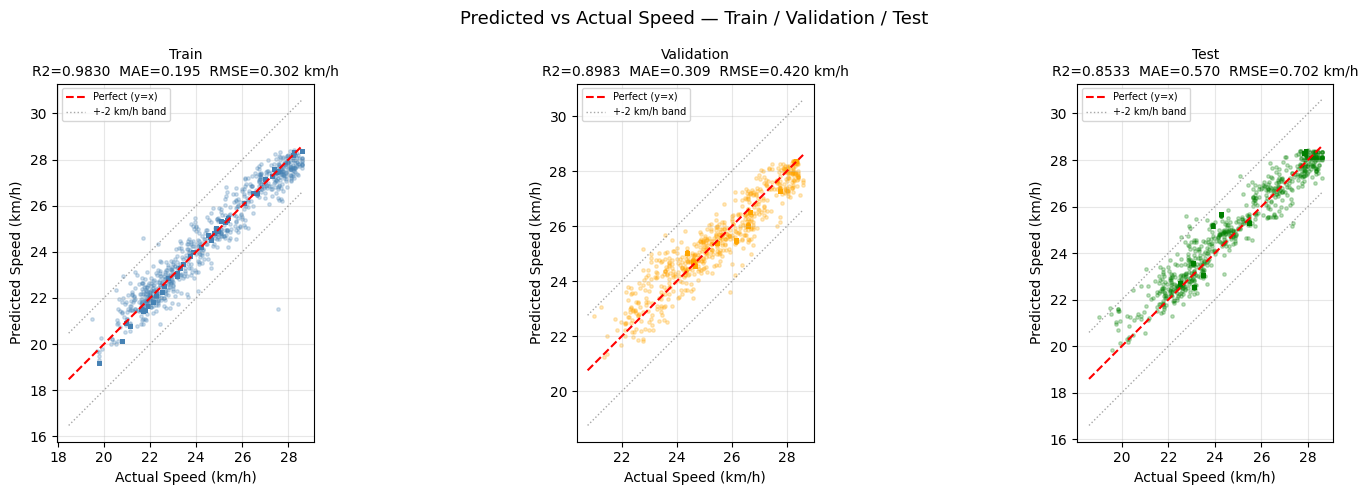

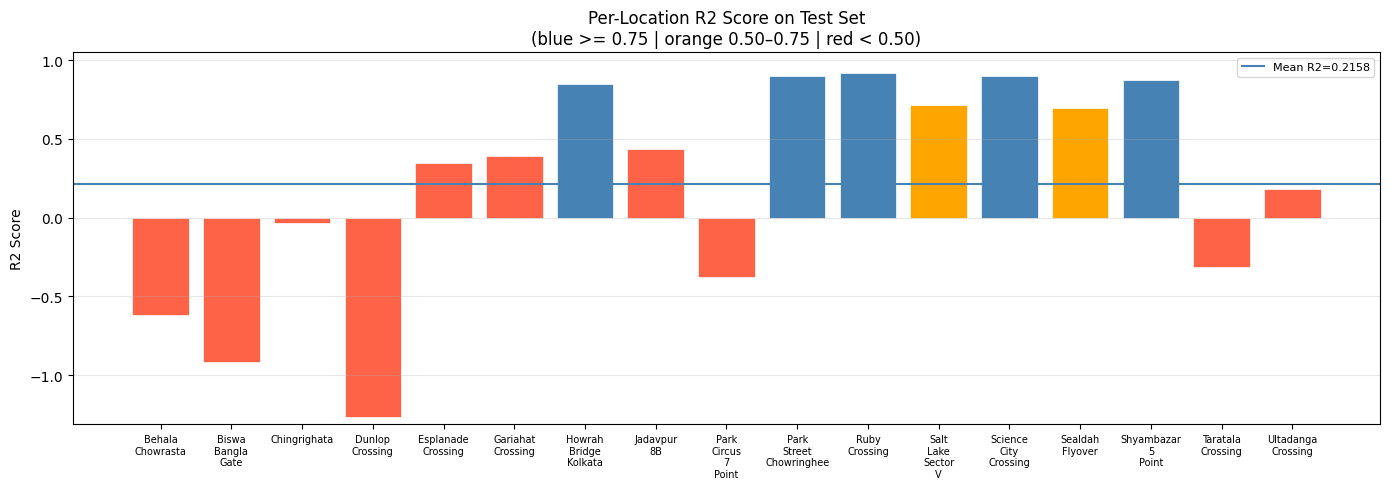

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def full_metrics(pred, true, name):
    mae   = mean_absolute_error(true, pred)
    rmse  = np.sqrt(mean_squared_error(true, pred))
    mape  = np.mean(np.abs((pred - true) / (true + 1e-6))) * 100
    r2    = r2_score(true, pred)
    bias  = np.mean(pred - true)
    std_e = np.std(pred - true)
    p50   = np.percentile(np.abs(pred - true), 50)   # median abs error
    p90   = np.percentile(np.abs(pred - true), 90)   # 90th pct abs error
    within2  = np.mean(np.abs(pred - true) < 2)  * 100
    within5  = np.mean(np.abs(pred - true) < 5)  * 100
    within10 = np.mean(np.abs(pred - true) < 10) * 100

    print(f"  {name}")
    print(f"  R2                  : {r2:>8.4f}")
    print(f"  MAE                 : {mae:>8.3f} km/h")
    print(f"  RMSE                : {rmse:>8.3f} km/h")
    print(f"  MAPE                : {mape:>8.2f} %")
    print(f"  Bias (mean error)   : {bias:>+8.3f} km/h")
    print(f"  Std of error        : {std_e:>8.3f} km/h")
    print(f"  Median abs error    : {p50:>8.3f} km/h")
    print(f"  90th pct abs error  : {p90:>8.3f} km/h")
    print(f"  Within  2 km/h      : {within2:>7.1f} %")
    print(f"  Within  5 km/h      : {within5:>7.1f} %")
    print(f"  Within 10 km/h      : {within10:>7.1f} %")

    return dict(r2=r2, mae=mae, rmse=rmse, mape=mape, bias=bias,
                std_e=std_e, p50=p50, p90=p90,
                w2=within2, w5=within5, w10=within10)

print("  PERFORMANCE METRICS — SPEED (km/h)")
m_tr = full_metrics(tr_p, tr_t, "\n\tTRAIN")
m_vl = full_metrics(vl_p, vl_t, "\n\tVALIDATION")
m_te = full_metrics(te_p, te_t, "\n\tTEST")

print("\n  PER-LOCATION R2 — TEST SET")
loc_r2 = []
for i, loc in enumerate(locations):
    p = inv(te_pred[:, 0, i, 0]).flatten()
    t = inv(te_true[:, 0, i, 0]).flatten()
    r = r2_score(t, p)
    loc_r2.append(r)
    bar = '|' * max(0, int(r * 20)) + '.' * max(0, 20 - int(r * 20))
    tag = ' <- best' if r == max(loc_r2) else ''
    print(f"  {loc:<28} {bar}  {r:.4f}{tag}")

worst_loc = locations[np.argmin(loc_r2)]
best_loc  = locations[np.argmax(loc_r2)]
print(f"\n  Best : {best_loc} (R2={max(loc_r2):.4f})")
print(f"  Worst: {worst_loc} (R2={min(loc_r2):.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

split_data = [
    ('Train',      tr_p, tr_t, m_tr, 'steelblue'),
    ('Validation', vl_p, vl_t, m_vl, 'orange'),
    ('Test',       te_p, te_t, m_te, 'green'),
]

for ax, (name, pred, true, m, color) in zip(axes, split_data):
    idx = np.random.choice(len(pred), min(5000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.25, s=6,
               color=color, rasterized=True)

    lim_min = min(true.min(), pred.min())
    lim_max = max(true.max(), pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='red', lw=1.5, ls='--', label='Perfect (y=x)')

    ax.plot([lim_min, lim_max], [lim_min+2, lim_max+2],
            color='gray', lw=1.0, ls=':', alpha=0.7, label='+-2 km/h band')
    ax.plot([lim_min, lim_max], [lim_min-2, lim_max-2],
            color='gray', lw=1.0, ls=':', alpha=0.7)

    ax.set_title(
        f'{name}\n'
        f'R2={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f} km/h',
        fontsize=10
    )
    ax.set_xlabel('Actual Speed (km/h)')
    ax.set_ylabel('Predicted Speed (km/h)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Speed — Train / Validation / Test', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/scatter_all_splits.png', dpi=130, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['tomato' if r < 0.5 else 'orange' if r < 0.75 else 'steelblue'
          for r in loc_r2]
ax.bar(range(len(locations)), loc_r2, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(loc_r2), color='steelblue', lw=1.5, ls='-',
           label=f'Mean R2={np.mean(loc_r2):.4f}')
ax.set_xticks(range(len(locations)))
ax.set_xticklabels([l.replace('_','\n') for l in locations], fontsize=7)
ax.set_ylabel('R2 Score')
ax.set_title('Per-Location R2 Score on Test Set\n(blue >= 0.75 | orange 0.50–0.75 | red < 0.50)')
ax.set_ylim(min(0, min(loc_r2)) - 0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/per_location_r2.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
def get_spatial_predictions(loader):
    model.eval()
    all_spat_pred, all_spat_true, all_masks = [], [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            _, p_spat = model(X, masks, edge_index, edge_weight)
            all_spat_pred.append(p_spat.cpu().numpy())
            all_spat_true.append(y_spat.numpy())
            all_masks.append(masks.cpu().numpy())
    return (np.concatenate(all_spat_pred),   # (S, N, F)
            np.concatenate(all_spat_true),
            np.concatenate(all_masks))# (S, N)

print("Collecting spatial predictions...")
tr_sp, tr_st, tr_mk = get_spatial_predictions(train_loader)
vl_sp, vl_st, vl_mk = get_spatial_predictions(val_loader)
te_sp, te_st, te_mk = get_spatial_predictions(test_loader)

sc  = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

def masked_only(pred, true, mask):
    """Extract only the (sample, node) pairs where mask==1."""
    idx_s, idx_n = np.where(mask == 1)   # sample indices, node indices
    p = inv(pred[idx_s, idx_n, 0].reshape(-1,1)).flatten()
    t = inv(true[idx_s, idx_n, 0].reshape(-1,1)).flatten()
    return p, t

tr_p, tr_t = masked_only(tr_sp, tr_st, tr_mk)
vl_p, vl_t = masked_only(vl_sp, vl_st, vl_mk)
te_p, te_t = masked_only(te_sp, te_st, te_mk)


Masked samples — Train: 513,224  Val: 109,976  Test: 109,984

Masked-node recovery metrics (spatial imputation):
  Train         R2=0.9889  MAE=0.589  RMSE=0.996  MAPE=2.34%  Bias=+0.022 km/h
  Validation    R2=0.9501  MAE=1.371  RMSE=2.015  MAPE=5.20%  Bias=-0.104 km/h
  Test          R2=0.9224  MAE=1.736  RMSE=2.654  MAPE=7.14%  Bias=+0.479 km/h


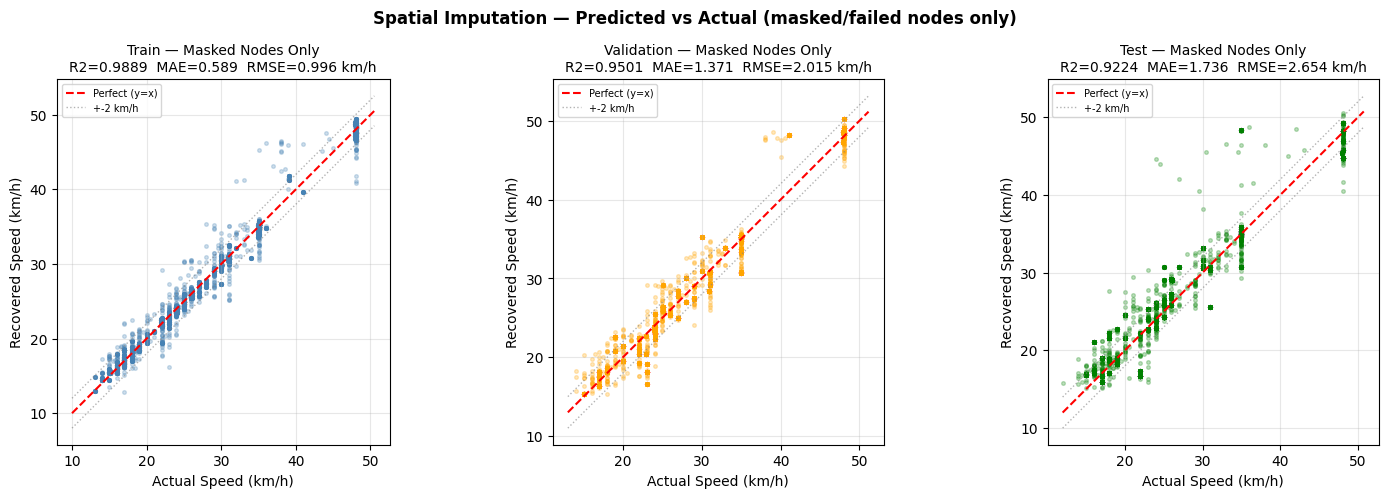

In [ ]:
print(f"Masked samples — Train: {len(tr_p):,}  Val: {len(vl_p):,}  Test: {len(te_p):,}")

def metrics(pred, true, name):
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((pred-true)/(true+1e-6)))*100
    bias = np.mean(pred - true)
    print(f"  {name:<12}  R2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%  Bias={bias:+.3f} km/h")
    return r2, mae, rmse

print("\nMasked-node recovery metrics (spatial imputation):")
r2_tr, mae_tr, rmse_tr = metrics(tr_p, tr_t, "Train")
r2_vl, mae_vl, rmse_vl = metrics(vl_p, vl_t, "Validation")
r2_te, mae_te, rmse_te = metrics(te_p, te_t, "Test")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = [
    ('Train', tr_p, tr_t, r2_tr, mae_tr, rmse_tr, 'steelblue'),
    ('Validation', vl_p, vl_t, r2_vl, mae_vl, rmse_vl, 'orange'),
    ('Test', te_p, te_t, r2_te, mae_te, rmse_te, 'green'),
]

for ax, (name, pred, true, r2, mae, rmse, color) in zip(axes, splits):
    idx = np.random.choice(len(pred), min(5000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.25, s=7, color=color, rasterized=True)

    lim_min = min(true.min(), pred.min())
    lim_max = max(true.max(), pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='red', lw=1.5, ls='--', label='Perfect (y=x)')
    ax.plot([lim_min, lim_max], [lim_min+2, lim_max+2],
            color='gray', lw=1.0, ls=':', alpha=0.6, label='+-2 km/h')
    ax.plot([lim_min, lim_max], [lim_min-2, lim_max-2],
            color='gray', lw=1.0, ls=':', alpha=0.6)

    ax.set_title(f'{name} — Masked Nodes Only\nR2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f} km/h',
                 fontsize=10)
    ax.set_xlabel('Actual Speed (km/h)')
    ax.set_ylabel('Recovered Speed (km/h)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Spatial Imputation — Predicted vs Actual (masked/failed nodes only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/scatter_masked_nodes.png', dpi=130, bbox_inches='tight')
plt.show()

# finding saturation

Masked samples — Train: 513,224  Val: 109,976  Test: 109,984

Masked-node recovery metrics (spatial imputation):
  Train         R2=0.9889  MAE=0.589  RMSE=0.996  MAPE=2.34%  Bias=+0.022 km/h
  Validation    R2=0.9501  MAE=1.371  RMSE=2.015  MAPE=5.20%  Bias=-0.104 km/h
  Test          R2=0.9224  MAE=1.736  RMSE=2.654  MAPE=7.14%  Bias=+0.479 km/h


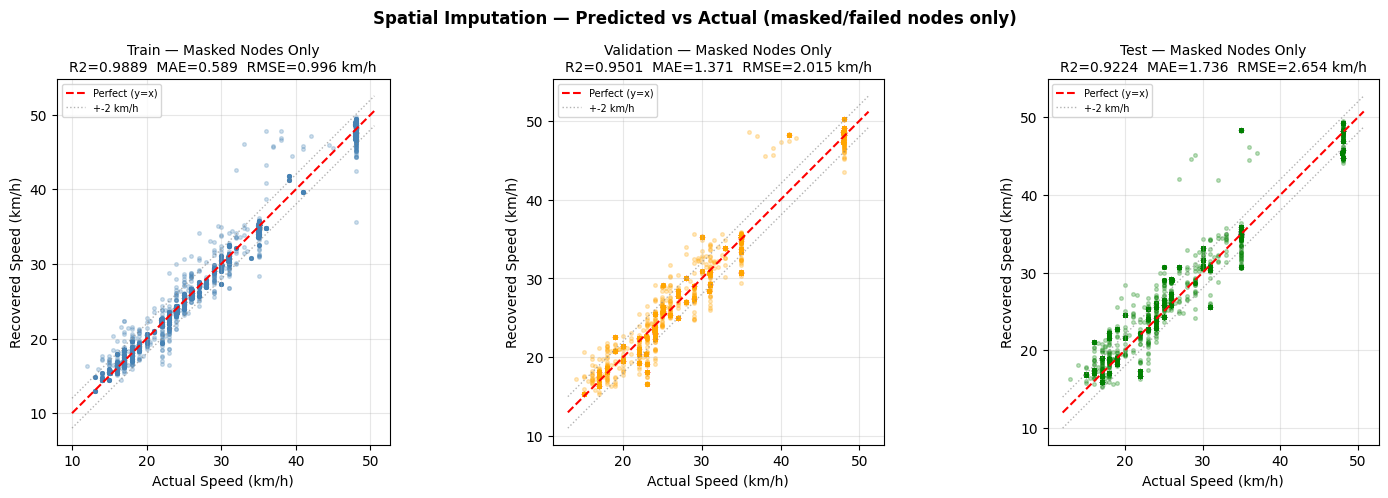

In [ ]:
print(f"Masked samples — Train: {len(tr_p):,}  Val: {len(vl_p):,}  Test: {len(te_p):,}")

def metrics(pred, true, name):
    r2 = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((pred-true)/(true+1e-6)))*100
    bias = np.mean(pred - true)
    print(f"  {name:<12}  R2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%  Bias={bias:+.3f} km/h")
    return r2, mae, rmse

print("\nMasked-node recovery metrics (spatial imputation):")
r2_tr, mae_tr, rmse_tr = metrics(tr_p, tr_t, "Train")
r2_vl, mae_vl, rmse_vl = metrics(vl_p, vl_t, "Validation")
r2_te, mae_te, rmse_te = metrics(te_p, te_t, "Test")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = [
    ('Train', tr_p, tr_t, r2_tr, mae_tr, rmse_tr, 'steelblue'),
    ('Validation', vl_p, vl_t, r2_vl, mae_vl, rmse_vl, 'orange'),
    ('Test', te_p, te_t, r2_te, mae_te, rmse_te, 'green'),
]

for ax, (name, pred, true, r2, mae, rmse, color) in zip(axes, splits):
    idx = np.random.choice(len(pred), min(5000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.25, s=7, color=color, rasterized=True)

    lim_min = min(true.min(), pred.min())
    lim_max = max(true.max(), pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='red', lw=1.5, ls='--', label='Perfect (y=x)')
    ax.plot([lim_min, lim_max], [lim_min+2, lim_max+2],
            color='gray', lw=1.0, ls=':', alpha=0.6, label='+-2 km/h')
    ax.plot([lim_min, lim_max], [lim_min-2, lim_max-2],
            color='gray', lw=1.0, ls=':', alpha=0.6)

    ax.set_title(f'{name} — Masked Nodes Only\nR2={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f} km/h',
                 fontsize=10)
    ax.set_xlabel('Actual Speed (km/h)')
    ax.set_ylabel('Recovered Speed (km/h)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Spatial Imputation — Predicted vs Actual (masked/failed nodes only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/scatter_masked_nodes.png', dpi=130, bbox_inches='tight')
plt.show()

  MASKING STRESS TEST — 3 to 14 nodes
  Satisfactory thresholds:
    MAE  < 5.0 km/h
    R2   > 0.5
    MAPE < 15.0%

Testing 3 masked nodes (18% of network)...
    PASS  R2=0.8327  MAE=2.030 km/h  RMSE=2.652  MAPE=8.97%  Within2km/h=58.6%
   Masked: ['Behala_Chowrasta', 'Biswa_Bangla_Gate', 'Gariahat_Crossing']

Testing 4 masked nodes (24% of network)...
    PASS  R2=0.8168  MAE=1.976 km/h  RMSE=2.491  MAPE=8.60%  Within2km/h=55.3%
   Masked: ['Behala_Chowrasta', 'Biswa_Bangla_Gate', 'Gariahat_Crossing', 'Taratala_Crossing']

Testing 5 masked nodes (29% of network)...
    FAIL  R2=0.5633  MAE=3.062 km/h  RMSE=4.395  MAPE=17.09%  Within2km/h=52.1%
   Masked: ['Behala_Chowrasta', 'Biswa_Bangla_Gate', 'Gariahat_Crossing', 'Taratala_Crossing', 'Salt_Lake_Sector_V']

Testing 6 masked nodes (35% of network)...
    FAIL  R2=0.2518  MAE=4.270 km/h  RMSE=5.628  MAPE=23.73%  Within2km/h=37.6%
   Masked: ['Behala_Chowrasta', 'Biswa_Bangla_Gate', 'Gariahat_Crossing', 'Taratala_Crossing', 'Salt_La

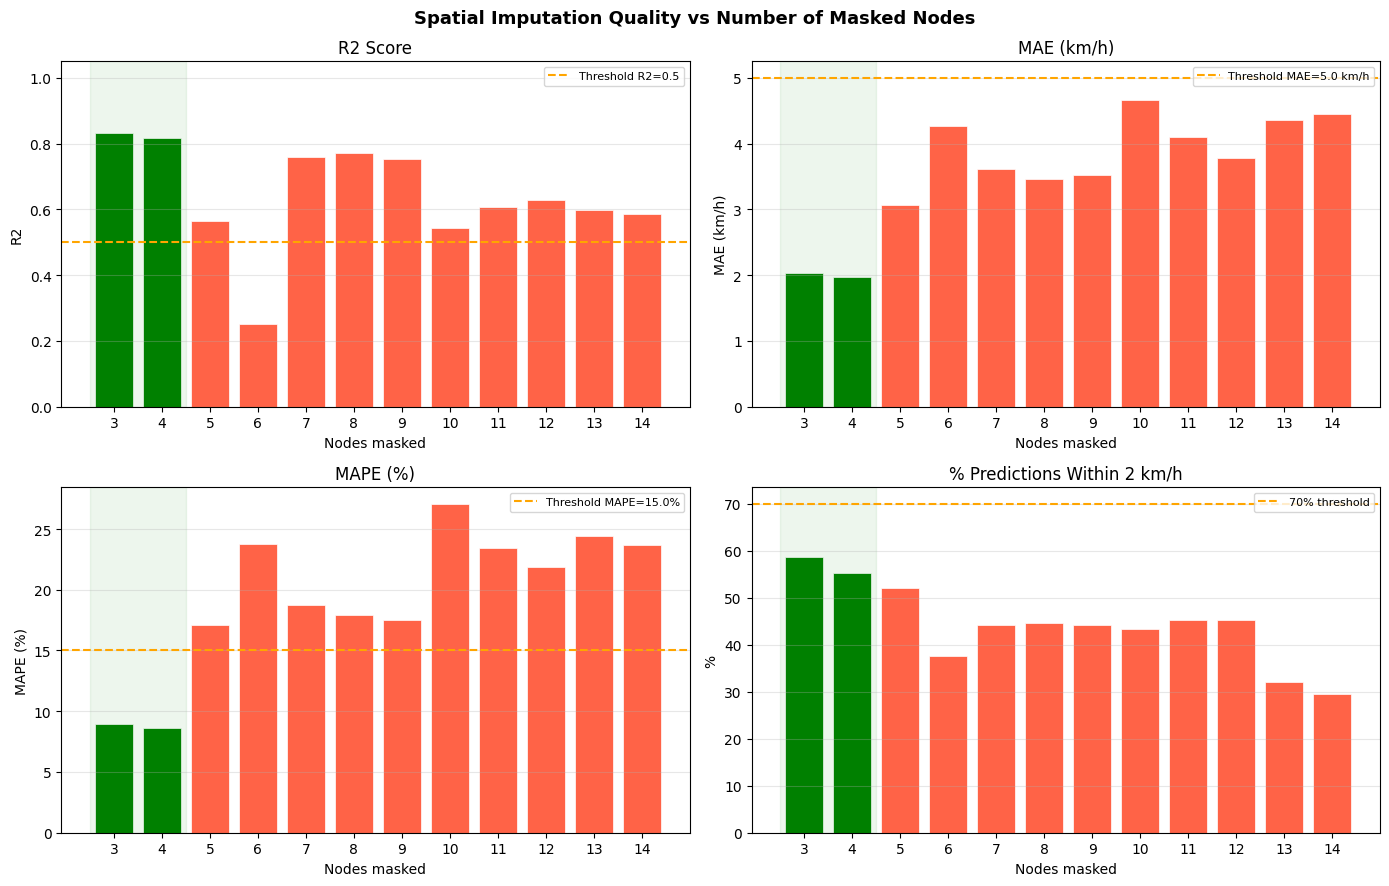

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader

N_LOCS = len(locations)
mask_range = range(3, min(15, N_LOCS))  # 3 to 14

# Thresholds for "satisfactory"
MAE_THRESHOLD  = 5.0   # km/h
R2_THRESHOLD   = 0.5   # R2 lower bound
MAPE_THRESHOLD = 15.0  # %

results = []  # will store one dict per mask count

sc  = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

def make_fixed_mask(n_masked, seed=42):
    rng = np.random.RandomState(seed)
    mask = np.zeros(N_LOCS, dtype=np.float32)
    chosen = rng.choice(N_LOCS, size=n_masked, replace=False)
    mask[chosen] = 1.0
    return mask, chosen

def create_sequences_fixed_mask(data, history_len, forecast_len, mask):
    T, N, F = data.shape
    X_history, X_masks, y_temporal, y_spatial = [], [], [], []
    for t in range(history_len, T - forecast_len + 1):
        history = data[t-history_len:t].copy()
        future  = data[t:t+forecast_len].copy()
        if np.isnan(history).any() or np.isnan(future).any():
            continue
        history_masked = history.copy()
        history_masked[:, mask==1, :] = 0.0
        X_history.append(history_masked)
        X_masks.append(mask)
        y_temporal.append(future)
        y_spatial.append(data[t-1])
    return {'X_history': np.array(X_history, dtype=np.float32),
            'X_masks':   np.array(X_masks,   dtype=np.float32),
            'y_temporal':np.array(y_temporal, dtype=np.float32),
            'y_spatial': np.array(y_spatial,  dtype=np.float32)}

def get_spatial_preds(loader, masked_nodes):
    model.eval()
    all_sp, all_st, all_mk = [], [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            _, p_spat = model(X, masks, edge_index, edge_weight)
            all_sp.append(p_spat.cpu().numpy())
            all_st.append(y_spat.numpy())
            all_mk.append(masks.cpu().numpy())
    sp = np.concatenate(all_sp)   # (S, N, F)
    st = np.concatenate(all_st)
    mk = np.concatenate(all_mk)

    # Extract only the fixed masked nodes
    p_vals, t_vals = [], []
    for n in masked_nodes:
        idx = np.where(mk[:, n] == 1)[0]
        if len(idx) > 0:
            p_vals.append(inv(sp[idx, n, 0].reshape(-1,1)).flatten())
            t_vals.append(inv(st[idx, n, 0].reshape(-1,1)).flatten())

    if not p_vals:
        return np.array([]), np.array([])
    return np.concatenate(p_vals), np.concatenate(t_vals)

print(f"  MASKING STRESS TEST — {min(mask_range)} to {max(mask_range)} nodes")
print(f"  Satisfactory thresholds:")
print(f"    MAE  < {MAE_THRESHOLD} km/h")
print(f"    R2   > {R2_THRESHOLD}")
print(f"    MAPE < {MAPE_THRESHOLD}%")

for n_mask in mask_range:
    print(f"\nTesting {n_mask} masked nodes ({n_mask/N_LOCS*100:.0f}% of network)...")

    mask, chosen_nodes = make_fixed_mask(n_mask)

    # Rebuild sequences with this mask
    seqs = create_sequences_fixed_mask(data_matrix, HISTORY_LEN, FORECAST_LEN, mask)
    S = len(seqs['X_history'])

    # if S < 50:
    #     print(f" Only {S} sequences — skipping")
    #     continue

    # Split same 70/15/15
    t_end = int(0.70 * S)
    v_end = int(0.85 * S)
    test_seqs = {k: v[v_end:] for k, v in seqs.items()}

    test_loader_tmp = DataLoader(
        TrafficDataset(test_seqs), batch_size=16, shuffle=False
    )

    pred, true = get_spatial_preds(test_loader_tmp, chosen_nodes)

    # if len(pred) < 10:
    #     print(f"   Not enough masked predictions — skipping")
    #     continue

    r2   = r2_score(true, pred)
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((pred-true)/(true+1e-6)))*100
    w2   = np.mean(np.abs(pred-true) < 2) * 100
    w5   = np.mean(np.abs(pred-true) < 5) * 100

    satisfactory = (mae < MAE_THRESHOLD and
                    r2  > R2_THRESHOLD   and
                    mape < MAPE_THRESHOLD)

    status = " PASS" if satisfactory else " FAIL"
    print(f"   {status}  R2={r2:.4f}  MAE={mae:.3f} km/h  "
          f"RMSE={rmse:.3f}  MAPE={mape:.2f}%  "
          f"Within2km/h={w2:.1f}%")
    print(f"   Masked: {[locations[n] for n in chosen_nodes]}")

    results.append(dict(
        n_mask=n_mask,
        pct=n_mask/N_LOCS*100,
        r2=r2, mae=mae, rmse=rmse, mape=mape,
        w2=w2, w5=w5,
        satisfactory=satisfactory,
        chosen=chosen_nodes.tolist()
    ))

passing = [r for r in results if r['satisfactory']]
failing = [r for r in results if not r['satisfactory']]

if passing:
    last_pass = passing[-1]['n_mask']
    print(f"   Last satisfactory mask count : {last_pass} nodes "
          f"({last_pass/N_LOCS*100:.0f}% of network)")
if failing:
    first_fail = failing[0]['n_mask']
    print(f"   First failure at             : {first_fail} nodes "
          f"({first_fail/N_LOCS*100:.0f}% of network)")
    print(f"   Recommended max masked nodes : {first_fail - 1}")

n_vals   = [r['n_mask'] for r in results]
r2_vals  = [r['r2']    for r in results]
mae_vals = [r['mae']   for r in results]
mape_vals= [r['mape']  for r in results]
w2_vals  = [r['w2']    for r in results]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Spatial Imputation Quality vs Number of Masked Nodes',
             fontsize=13, fontweight='bold')

bar_colors = ['green' if r['satisfactory'] else 'tomato' for r in results]

ax = axes[0, 0]
ax.bar(n_vals, r2_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(R2_THRESHOLD, color='orange', lw=1.5, ls='--',
           label=f'Threshold R2={R2_THRESHOLD}')
ax.set_title('R2 Score'); ax.set_xlabel('Nodes masked')
ax.set_ylabel('R2'); ax.set_ylim(0, 1.05)
ax.set_xticks(n_vals); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
ax.bar(n_vals, mae_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(MAE_THRESHOLD, color='orange', lw=1.5, ls='--',
           label=f'Threshold MAE={MAE_THRESHOLD} km/h')
ax.set_title('MAE (km/h)'); ax.set_xlabel('Nodes masked')
ax.set_ylabel('MAE (km/h)')
ax.set_xticks(n_vals); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.bar(n_vals, mape_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(MAPE_THRESHOLD, color='orange', lw=1.5, ls='--',
           label=f'Threshold MAPE={MAPE_THRESHOLD}%')
ax.set_title('MAPE (%)'); ax.set_xlabel('Nodes masked')
ax.set_ylabel('MAPE (%)')
ax.set_xticks(n_vals); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.bar(n_vals, w2_vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(70, color='orange', lw=1.5, ls='--', label='70% threshold')
ax.set_title('% Predictions Within 2 km/h')
ax.set_xlabel('Nodes masked'); ax.set_ylabel('%')
ax.set_xticks(n_vals); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

for ax in axes.flatten():
    if passing:
        ax.axvspan(n_vals[0]-0.5, last_pass+0.5,
                   alpha=0.07, color='green', label='Satisfactory zone')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/masking_stress_test.png',
            dpi=130, bbox_inches='tight')
plt.show()

n_res  = len(results)
n_cols = 4
n_rows = int(np.ceil(n_res / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    mask, chosen = make_fixed_mask(r['n_mask'])
    seqs = create_sequences_fixed_mask(data_matrix, HISTORY_LEN, FORECAST_LEN, mask)
    S = len(seqs['X_history'])
    test_seqs = {k: v[int(0.85*S):] for k, v in seqs.items()}
    test_loader_tmp = DataLoader(TrafficDataset(test_seqs), batch_size=16, shuffle=False)
    pred, true = get_spatial_preds(test_loader_tmp, chosen)

    if len(pred) < 5:
        ax.set_visible(False)
        continue

    color = 'green' if r['satisfactory'] else 'tomato'
    idx = np.random.choice(len(pred), min(2000, len(pred)), replace=False)
    ax.scatter(true[idx], pred[idx], alpha=0.3, s=8, color=color, rasterized=True)

    lim = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lim, lim, color='black', lw=1.2, ls='--')

    status = "YES :" if r['satisfactory'] else "NO :"
    ax.set_title(f"{status} {r['n_mask']} nodes masked ({r['pct']:.0f}%)\n"
                 f"R2={r['r2']:.3f}  MAE={r['mae']:.2f} km/h", fontsize=8)
    ax.set_xlabel('Actual (km/h)', fontsize=7)
    ax.set_ylabel('Recovered (km/h)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatter: Recovered vs Actual — per mask count\n'
             '(green=satisfactory, red=failed threshold)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/masking_scatter_grid.png',
            dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader

N_ITERATIONS  = 10
MASK_RANGE    = range(3, min(15, N_LOCS))
MAE_THRESHOLD  = 5.0
R2_THRESHOLD   = 0.5
MAPE_THRESHOLD = 15.0

sc  = scalers['current_speed']
inv = lambda x: sc.inverse_transform(x.reshape(-1,1)).reshape(x.shape)

# Load best checkpoint once
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded trained model from checkpoint.")
print(f"Testing mask counts {min(MASK_RANGE)}→{max(MASK_RANGE)}, "
      f"{N_ITERATIONS} random draws each.\n")

def evaluate_fixed_mask(masked_nodes, mask_vec):
    """
    Given a fixed mask, build test sequences and get spatial
    predictions for the masked nodes — NO retraining.
    """
    # Build sequences with this mask applied to existing data_matrix
    seqs = create_sequences_fixed_mask(
        data_matrix, HISTORY_LEN, FORECAST_LEN, mask_vec
    )
    S = len(seqs['X_history'])
    if S < 50:
        return None

    # Use test split only (last 15%)
    test_start = int(0.85 * S)
    test_seqs  = {k: v[test_start:] for k, v in seqs.items()}
    loader     = DataLoader(TrafficDataset(test_seqs),
                            batch_size=16, shuffle=False)

    all_sp, all_st, all_mk = [], [], []
    with torch.no_grad():
        for X, masks, y_temp, y_spat in loader:
            X, masks = X.to(device), masks.to(device)
            _, p_spat = model(X, masks, edge_index, edge_weight)
            all_sp.append(p_spat.cpu().numpy())
            all_st.append(y_spat.numpy())
            all_mk.append(masks.cpu().numpy())

    sp = np.concatenate(all_sp)
    st = np.concatenate(all_st)
    mk = np.concatenate(all_mk)

    # Extract predictions for masked nodes only
    all_p, all_t = [], []
    for n in masked_nodes:
        idx = np.where(mk[:, n] == 1)[0]
        if len(idx) > 0:
            all_p.append(inv(sp[idx, n, 0].reshape(-1,1)).flatten())
            all_t.append(inv(st[idx, n, 0].reshape(-1,1)).flatten())

    if not all_p:
        return None

    p = np.concatenate(all_p)
    t = np.concatenate(all_t)

    return dict(
        r2   = r2_score(t, p),
        mae  = mean_absolute_error(t, p),
        rmse = np.sqrt(mean_squared_error(t, p)),
        mape = np.mean(np.abs((p-t)/(t+1e-6)))*100,
        w2   = np.mean(np.abs(p-t) < 2)*100,
        n_samples = len(p)
    )

results_agg = {n: [] for n in MASK_RANGE}

print(f"{'Mask':>5} {'Iter':>5} {'R²':>8} {'MAE':>8} {'MAPE%':>8} {'Status'}")

for n_mask in MASK_RANGE:
    for it in range(N_ITERATIONS):
        # Different node selection per iteration
        rng   = np.random.RandomState(seed=it * 100 + n_mask)
        chosen = rng.choice(N_LOCS, size=n_mask, replace=False)
        mask_vec = np.zeros(N_LOCS, dtype=np.float32)
        mask_vec[chosen] = 1.0

        result = evaluate_fixed_mask(chosen, mask_vec)
        if result is None:
            continue

        results_agg[n_mask].append(result)
        status = "Good" if (result['mae']  < MAE_THRESHOLD and
                          result['r2']   > R2_THRESHOLD  and
                          result['mape'] < MAPE_THRESHOLD) else "Bad"
        print(f"{n_mask:>5} {it+1:>5} {result['r2']:>8.4f} "
              f"{result['mae']:>8.3f} {result['mape']:>8.2f}   "
              f"nodes={[locations[c] for c in chosen]}...")

    # Print aggregated summary for this mask count
    if results_agg[n_mask]:
        r2s   = [r['r2']   for r in results_agg[n_mask]]
        maes  = [r['mae']  for r in results_agg[n_mask]]
        mapes = [r['mape'] for r in results_agg[n_mask]]
        print(f"\n  n={n_mask} AGGREGATE - "
              f"R²: {np.max(r2s):.4f}+-{np.std(r2s):.4f} | "
              f"MAE: {np.min(maes):.3f}+-{np.std(maes):.3f} | "
              f"MAPE: {np.min(mapes):.2f}+-{np.std(mapes):.2f}\n")
        print(f"\n  n={n_mask} AGGREGATE - "
              f"R²: {np.mean(r2s):.4f}+-{np.std(r2s):.4f} | "
              f"MAE: {np.mean(maes):.3f}+-{np.std(maes):.3f} | "
              f"MAPE: {np.mean(mapes):.2f}+-{np.std(mapes):.2f}\n")

n_vals, r2_mean, r2_std = [], [], []
mae_mean, mae_std       = [], []
mape_mean, mape_std     = [], []
w2_mean                 = []
pass_rate               = []

for n_mask in MASK_RANGE:
    rlist = results_agg[n_mask]
    if not rlist:
        continue
    n_vals.append(n_mask)
    r2s   = [r['r2']   for r in rlist]
    maes  = [r['mae']  for r in rlist]
    mapes = [r['mape'] for r in rlist]
    w2s   = [r['w2']   for r in rlist]
    passes = sum(1 for r in rlist
                 if r['mae']  < MAE_THRESHOLD and
                    r['r2']   > R2_THRESHOLD  and
                    r['mape'] < MAPE_THRESHOLD)

    r2_mean.append(np.mean(r2s));     r2_std.append(np.std(r2s))
    mae_mean.append(np.mean(maes));   mae_std.append(np.std(maes))
    mape_mean.append(np.mean(mapes)); mape_std.append(np.std(mapes))
    w2_mean.append(np.mean(w2s))
    pass_rate.append(passes / len(rlist) * 100)

n_vals     = np.array(n_vals)
r2_mean    = np.array(r2_mean);    r2_std    = np.array(r2_std)
mae_mean   = np.array(mae_mean);   mae_std   = np.array(mae_std)
mape_mean  = np.array(mape_mean);  mape_std  = np.array(mape_std)
pass_rate  = np.array(pass_rate)

# Saturation = last mask count where pass_rate >= 50%
sat_candidates = n_vals[pass_rate >= 50]
saturation_point = int(sat_candidates[-1]) if len(sat_candidates) > 0 else None
first_fail = int(n_vals[pass_rate < 50][0]) if (pass_rate < 50).any() else None

print("  SATURATION ANALYSIS")
print(f"  {'Nodes':>6} {'Pass Rate':>10} {'Mean R2':>9} {'Mean MAE':>10}")
for i, n in enumerate(n_vals):
    flag = " - SATURATION" if n == saturation_point else ""
    print(f"  {n:>6} {pass_rate[i]:>9.0f}% {r2_mean[i]:>9.4f} "
          f"{mae_mean[i]:>10.3f}{flag}")

if saturation_point:
    print(f"\n  Recommended max masked nodes : {saturation_point} "
          f"({saturation_point/N_LOCS*100:.0f}% of network)")
if first_fail:
    print(f"  Performance degrades from    : {first_fail} nodes onward")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Spatial Imputation vs Mask Count\n'
             f'({N_ITERATIONS} random location draws per count, '
             f'mean +- std shown)',
             fontsize=12, fontweight='bold')

def plot_metric(ax, y_mean, y_std, threshold, ylabel, title, threshold_label,
                higher_is_better=True):
    ax.plot(n_vals, y_mean, 'o-', color='steelblue', lw=2, ms=6, zorder=3)
    ax.fill_between(n_vals,
                    y_mean - y_std,
                    y_mean + y_std,
                    alpha=0.25, color='steelblue', label='+-1 std')
    ax.axhline(threshold, color='orange', lw=1.5, ls='--',
               label=threshold_label)
    if saturation_point:
        ax.axvline(saturation_point, color='green', lw=1.5, ls=':',
                   label=f'Saturation={saturation_point}')
    if higher_is_better:
        ax.fill_between(n_vals, threshold, y_mean,
                        where=y_mean >= threshold,
                        alpha=0.08, color='green')
    else:
        ax.fill_between(n_vals, y_mean, threshold,
                        where=y_mean <= threshold,
                        alpha=0.08, color='green')
    ax.set_xlabel('Number of nodes masked')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(n_vals)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot_metric(axes[0,0], r2_mean,   r2_std,   R2_THRESHOLD,
            'R2', 'R2 Score', f'Threshold={R2_THRESHOLD}',
            higher_is_better=True)

plot_metric(axes[0,1], mae_mean,  mae_std,  MAE_THRESHOLD,
            'MAE (km/h)', 'MAE', f'Threshold={MAE_THRESHOLD} km/h',
            higher_is_better=False)

plot_metric(axes[1,0], mape_mean, mape_std, MAPE_THRESHOLD,
            'MAPE (%)', 'MAPE', f'Threshold={MAPE_THRESHOLD}%',
            higher_is_better=False)

# Pass rate bar chart
bar_colors = ['green' if p >= 50 else 'tomato' for p in pass_rate]
axes[1,1].bar(n_vals, pass_rate, color=bar_colors,
              edgecolor='white', linewidth=0.5, width=0.7)
axes[1,1].axhline(50, color='orange', lw=1.5, ls='--', label='50% pass rate')
if saturation_point:
    axes[1,1].axvline(saturation_point, color='green', lw=1.5, ls=':',
                      label=f'Saturation={saturation_point}')
axes[1,1].set_xlabel('Number of nodes masked')
axes[1,1].set_ylabel('% iterations passing all thresholds')
axes[1,1].set_title(f'Pass Rate across {N_ITERATIONS} random draws')
axes[1,1].set_xticks(n_vals)
axes[1,1].set_ylim(0, 105)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, (n, p) in enumerate(zip(n_vals, pass_rate)):
    axes[1,1].text(n, p+1.5, f'{p:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/saturation_aggregated.png',
            dpi=130, bbox_inches='tight')
plt.show()
print("Saved: saturation_aggregated.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Error Distribution across {N_ITERATIONS} Random Location Draws',
             fontsize=12, fontweight='bold')

for ax, metric, label, threshold, better in [
    (axes[0], 'r2',   'R2',        R2_THRESHOLD,  'higher'),
    (axes[1], 'mae',  'MAE (km/h)',MAE_THRESHOLD,  'lower'),
    (axes[2], 'mape', 'MAPE (%)',  MAPE_THRESHOLD, 'lower'),
]:
    data_per_n = [[r[metric] for r in results_agg[n]]
                  for n in n_vals]
    bp = ax.boxplot(data_per_n, positions=n_vals, widths=0.6,
                    patch_artist=True, showfliers=True)

    for patch, n in zip(bp['boxes'], n_vals):
        idx = list(n_vals).index(n)
        patch.set_facecolor('lightgreen' if pass_rate[idx] >= 50 else 'lightsalmon')
        patch.set_alpha(0.7)

    ax.axhline(threshold, color='orange', lw=1.5, ls='--',
               label=f'Threshold={threshold}')
    if saturation_point:
        ax.axvline(saturation_point, color='green', lw=1.2, ls=':',
                   label=f'Saturation={saturation_point}')
    ax.set_xlabel('Nodes masked')
    ax.set_ylabel(label)
    ax.set_title(f'{label} ({better} is better)')
    ax.set_xticks(n_vals)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/saturation_boxplots.png',
            dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
n_vals, r2_agg, r2_std = [], [], []
mae_agg, mae_std       = [], []
mape_agg, mape_std     = [], []
w2_agg                 = []
pass_rate               = []

for n_mask in MASK_RANGE:
    rlist = results_agg[n_mask]
    if not rlist:
        continue
    n_vals.append(n_mask)
    r2s   = [r['r2']   for r in rlist]
    maes  = [r['mae']  for r in rlist]
    mapes = [r['mape'] for r in rlist]
    w2s   = [r['w2']   for r in rlist]
    passes = sum(1 for r in rlist
                 if r['mae']  < MAE_THRESHOLD and
                    r['r2']   > R2_THRESHOLD  and
                    r['mape'] < MAPE_THRESHOLD)

    r2_agg.append(np.max(r2s));     r2_std.append(np.std(r2s))
    mae_agg.append(np.min(maes));   mae_std.append(np.std(maes))
    mape_agg.append(np.min(mapes)); mape_std.append(np.std(mapes))
    w2_agg.append(np.mean(w2s))
    pass_rate.append(passes / len(rlist) * 100)

n_vals     = np.array(n_vals)
r2_agg    = np.array(r2_agg);    r2_std    = np.array(r2_std)
mae_agg   = np.array(mae_agg);   mae_std   = np.array(mae_std)
mape_agg  = np.array(mape_agg);  mape_std  = np.array(mape_std)
w2_agg    = np.array(w2_agg)
pass_rate  = np.array(pass_rate)

# Saturation = last mask count where pass_rate >= 50%
sat_candidates = n_vals[pass_rate >= 50]
saturation_point = int(sat_candidates[-1]) if len(sat_candidates) > 0 else None
first_fail = int(n_vals[pass_rate < 50][0]) if (pass_rate < 50).any() else None

print("  SATURATION ANALYSIS")
print(f"  {'Nodes':>6} {'Pass Rate':>10} {'Aggregated R2':>9} {'Aggregated MAE':>10}")
for i, n in enumerate(n_vals):
    flag = " - SATURATION" if n == saturation_point else ""
    print(f"  {n:>6} {pass_rate[i]:>9.0f}% {r2_agg[i]:>9.4f} "
          f"{mae_agg[i]:>10.3f}{flag}")

if saturation_point:
    print(f"\n  Recommended max masked nodes : {saturation_point} "
          f"({saturation_point/N_LOCS*100:.0f}% of network)")
if first_fail:
    print(f"  Performance degrades from    : {first_fail} nodes onward")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Spatial Imputation vs Mask Count\n'
             f'({N_ITERATIONS} random location draws per count, '
             f'mean +- std shown)',
             fontsize=12, fontweight='bold')

def plot_metric(ax, y_mean, y_std, threshold, ylabel, title, threshold_label,
                higher_is_better=True):
    ax.plot(n_vals, y_mean, 'o-', color='steelblue', lw=2, ms=6, zorder=3)
    ax.fill_between(n_vals,
                    y_mean - y_std,
                    y_mean + y_std,
                    alpha=0.25, color='steelblue', label='+-1 std')
    ax.axhline(threshold, color='orange', lw=1.5, ls='--',
               label=threshold_label)
    if saturation_point:
        ax.axvline(saturation_point, color='green', lw=1.5, ls=':',
                   label=f'Saturation={saturation_point}')
    if higher_is_better:
        ax.fill_between(n_vals, threshold, y_mean,
                        where=y_mean >= threshold,
                        alpha=0.08, color='green')
    else:
        ax.fill_between(n_vals, y_mean, threshold,
                        where=y_mean <= threshold,
                        alpha=0.08, color='green')
    ax.set_xlabel('Number of nodes masked')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(n_vals)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot_metric(axes[0,0], r2_agg,   r2_std,   R2_THRESHOLD,
            'R2', 'R2 Score', f'Threshold={R2_THRESHOLD}',
            higher_is_better=True)

plot_metric(axes[0,1], mae_agg,  mae_std,  MAE_THRESHOLD,
            'MAE (km/h)', 'MAE', f'Threshold={MAE_THRESHOLD} km/h',
            higher_is_better=False)

plot_metric(axes[1,0], mape_agg, mape_std, MAPE_THRESHOLD,
            'MAPE (%)', 'MAPE', f'Threshold={MAPE_THRESHOLD}%',
            higher_is_better=False)

# Pass rate bar chart
bar_colors = ['green' if p >= 50 else 'tomato' for p in pass_rate]
axes[1,1].bar(n_vals, pass_rate, color=bar_colors,
              edgecolor='white', linewidth=0.5, width=0.7)
axes[1,1].axhline(50, color='orange', lw=1.5, ls='--', label='50% pass rate')
if saturation_point:
    axes[1,1].axvline(saturation_point, color='green', lw=1.5, ls=':',
                      label=f'Saturation={saturation_point}')
axes[1,1].set_xlabel('Number of nodes masked')
axes[1,1].set_ylabel('% iterations passing all thresholds')
axes[1,1].set_title(f'Pass Rate across {N_ITERATIONS} random draws')
axes[1,1].set_xticks(n_vals)
axes[1,1].set_ylim(0, 105)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, (n, p) in enumerate(zip(n_vals, pass_rate)):
    axes[1,1].text(n, p+1.5, f'{p:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/saturation_aggregated.png',
            dpi=130, bbox_inches='tight')
plt.show()
print("Saved: saturation_aggregated.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Error Distribution across {N_ITERATIONS} Random Location Draws',
             fontsize=12, fontweight='bold')

for ax, metric, label, threshold, better in [
    (axes[0], 'r2',   'R2',        R2_THRESHOLD,  'higher'),
    (axes[1], 'mae',  'MAE (km/h)',MAE_THRESHOLD,  'lower'),
    (axes[2], 'mape', 'MAPE (%)',  MAPE_THRESHOLD, 'lower'),
]:
    data_per_n = [[r[metric] for r in results_agg[n]]
                  for n in n_vals]
    bp = ax.boxplot(data_per_n, positions=n_vals, widths=0.6,
                    patch_artist=True, showfliers=True)

    for patch, n in zip(bp['boxes'], n_vals):
        idx = list(n_vals).index(n)
        patch.set_facecolor('lightgreen' if pass_rate[idx] >= 50 else 'lightsalmon')
        patch.set_alpha(0.7)

    ax.axhline(threshold, color='orange', lw=1.5, ls='--',
               label=f'Threshold={threshold}')
    if saturation_point:
        ax.axvline(saturation_point, color='green', lw=1.2, ls=':',
                   label=f'Saturation={saturation_point}')
    ax.set_xlabel('Nodes masked')
    ax.set_ylabel(label)
    ax.set_title(f'{label} ({better} is better)')
    ax.set_xticks(n_vals)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/saturation_boxplots.png',
            dpi=130, bbox_inches='tight')
plt.show()

#hourly predictions

df_norm.pkl found — loading directly.

df_norm shape : (89265, 23)
Locations     : ['Behala_Chowrasta', 'Biswa_Bangla_Gate', 'Chingrighata', 'Dunlop_Crossing', 'EM_Bypass_North', 'Esplanade_Crossing', 'Gariahat', 'Gariahat_Crossing', 'Howrah_Bridge', 'Howrah_Bridge_Kolkata', 'Jadavpur_8B', 'Park_Circus_7_Point', 'Park_Street', 'Park_Street_Chowringhee', 'Ruby_Crossing', 'Salt_Lake_Sector_V', 'Salt_Lake_V', 'Science_City_Crossing', 'Sealdah_Flyover', 'Shyambazar_5_Point', 'Taratala_Crossing', 'Ultadanga_Crossing']
Date range    : 2026-02-09 06:59:00  →  2026-03-06 06:15:00

Timestep-level rows for GMM: 5,579
Running BIC sweep (n=2..12) …
BIC-optimal n = 12  (using N_PERIODS=7)


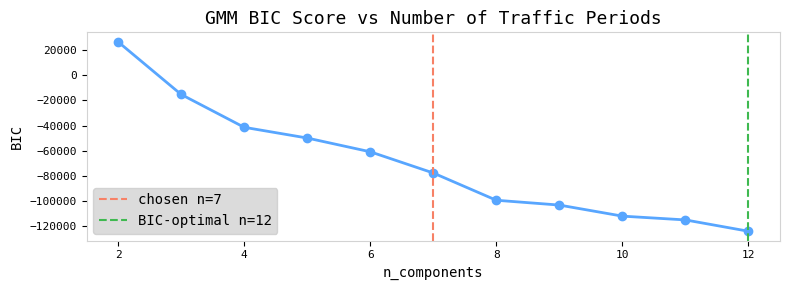

Saved → results/16A_bic_sweep.png

Fitting GMM (n=7) …
Converged: True  |  Log-likelihood: 7.2054

AUTO-NAMED CLUSTER PROFILES
 CID  Auto Name                       Rows   AvgSpd   MedianHr   %Wknd
   0  Early Afternoon Lull             897     24.1      14.58    46.9%
   1  Night Quiet                      420     28.1       4.56     0.0%
   2  Night Moderate                   877     27.0       4.52   100.0%
   3  Morning Rush Hour                438     15.8       8.19     0.0%
   4  Night Moderate                   613     23.9       5.20     0.0%
   5  Night Moderate                  1295     23.4       5.55     0.0%
   6  Night Moderate                  1039     22.8       5.68     0.0%


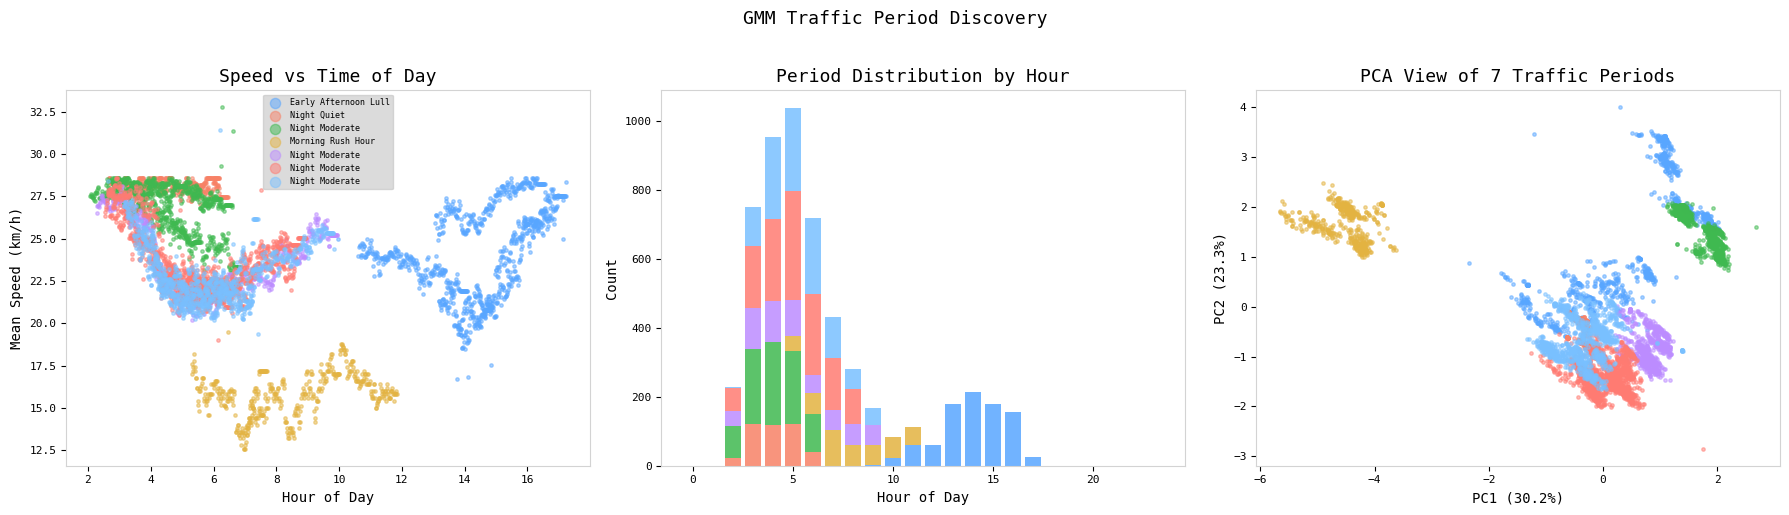


Period counts (network-level timesteps):
period_label
Night Moderate          3824
Early Afternoon Lull     897
Morning Rush Hour        438
Night Quiet              420


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import pickle, os, glob, warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/kolkata_traffic_stllm'
N_PERIODS   = 7
FEATURES    = ['current_speed', 'current_travel_time', 'confidence']

df_norm_path  = f'{PROJECT_DIR}/data/processed/df_norm.pkl'
scalers_path  = f'{PROJECT_DIR}/data/processed/scalers.pkl'

if os.path.exists(df_norm_path):
    print("df_norm.pkl found — loading directly.")
    df_norm = pd.read_pickle(df_norm_path)

else:
    print("df_norm.pkl not found — rebuilding from raw CSVs …")

    raw_dir   = f'{PROJECT_DIR}/data/raw'
    csv_files = glob.glob(f'{raw_dir}/*.csv')
    assert len(csv_files) > 0, f"No CSVs found in {raw_dir}"

    dfs = []
    for f in csv_files:
        try:
            tmp = pd.read_csv(f, parse_dates=['timestamp'])
            dfs.append(tmp)
        except Exception as e:
            print(f"  Skipping {f}: {e}")
    df_raw = pd.concat(dfs, ignore_index=True)
    print(f"  Loaded {len(df_raw):,} rows from {len(csv_files)} CSV(s)")

    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp']).dt.floor('min')

    num_cols = [c for c in FEATURES + ['latitude','longitude']
                if c in df_raw.columns]
    df_raw = (df_raw.groupby(['timestamp','location_name'])[num_cols]
                    .mean().reset_index())

    def fill_gaps(df, freq='1min', max_fill_minutes=10):
        all_locs = []
        for loc in df['location_name'].unique():
            sub = df[df['location_name'] == loc].copy()
            sub = sub.set_index('timestamp').sort_index()
            nc  = [c for c in num_cols if c in sub.columns]
            full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq=freq)
            sub = sub[nc].reindex(full_idx)
            sub['is_imputed'] = sub['current_speed'].isna().astype(int)
            sub[nc] = sub[nc].interpolate(method='linear', limit=5,
                                           limit_direction='forward')
            sub[nc] = sub[nc].ffill(limit=max_fill_minutes)
            if 'latitude'  in nc: sub['latitude']  = sub['latitude'].ffill().bfill()
            if 'longitude' in nc: sub['longitude'] = sub['longitude'].ffill().bfill()
            sub['location_name'] = loc
            sub.index.name = 'timestamp'
            all_locs.append(sub.reset_index())
        return pd.concat(all_locs, ignore_index=True)

    df_filled = fill_gaps(df_raw)
    print(f"  After fill_gaps: {len(df_filled):,} rows, "
          f"NaN speed rows: {df_filled['current_speed'].isna().sum():,}")

    df_filled = df_filled.dropna(subset=FEATURES).reset_index(drop=True)

    print("\n  Imputation audit:")
    for loc in sorted(df_filled['location_name'].unique()):
        sub = df_filled[df_filled['location_name'] == loc]
        pct = sub['is_imputed'].mean() * 100
        flag = '' if pct > 60 else ''
        print(f"    {loc:<35}  {pct:5.1f}% imputed{flag}")

    if os.path.exists(scalers_path):
        print("\n  Loading existing scalers")
        with open(scalers_path, 'rb') as f:
            scalers = pickle.load(f)
        df_norm = df_filled.copy()
        for feat in FEATURES:
            df_norm[feat] = scalers[feat].transform(
                df_filled[feat].values.reshape(-1, 1))
    else:
        print("\n  Fitting new scalers on real rows …")
        scalers = {}
        df_norm = df_filled.copy()
        for feat in FEATURES:
            sc = StandardScaler()
            real_vals = df_filled[df_filled['is_imputed'] == 0][feat].values.reshape(-1, 1)
            sc.fit(real_vals)
            df_norm[feat] = sc.transform(df_filled[feat].values.reshape(-1, 1))
            scalers[feat] = sc
        with open(scalers_path, 'wb') as f:
            pickle.dump(scalers, f)
        print(f"  Scalers saved → {scalers_path}")

    for feat in FEATURES:
        mu, sigma = df_norm[feat].mean(), df_norm[feat].std()
        df_norm[feat] = df_norm[feat].clip(mu - 3*sigma, mu + 3*sigma)

    df_norm.to_pickle(df_norm_path)
    print(f"\n df_norm saved → {df_norm_path}  "
          f"({len(df_norm):,} rows, {df_norm['location_name'].nunique()} locations)")

if 'scalers' not in dir():
    with open(scalers_path, 'rb') as f:
        scalers = pickle.load(f)

print(f"\ndf_norm shape : {df_norm.shape}")
print(f"Locations     : {sorted(df_norm['location_name'].unique())}")
print(f"Date range    : {df_norm['timestamp'].min()}  →  {df_norm['timestamp'].max()}")


speed_scaler = scalers['current_speed']
tt_scaler    = scalers['current_travel_time']

df_norm['speed_kmh']    = speed_scaler.inverse_transform(
    df_norm['current_speed'].values.reshape(-1, 1)).flatten()
df_norm['travel_time_s'] = tt_scaler.inverse_transform(
    df_norm['current_travel_time'].values.reshape(-1, 1)).flatten()

df_norm['timestamp'] = pd.to_datetime(df_norm['timestamp'])
df_norm['hour']      = df_norm['timestamp'].dt.hour
df_norm['minute']    = df_norm['timestamp'].dt.minute
df_norm['dow']       = df_norm['timestamp'].dt.dayofweek
df_norm['is_weekend'] = (df_norm['dow'] >= 5).astype(float)
df_norm['hour_frac']  = df_norm['hour'] + df_norm['minute'] / 60.0

df_norm['hour_sin'] = np.sin(2 * np.pi * df_norm['hour_frac'] / 24)
df_norm['hour_cos'] = np.cos(2 * np.pi * df_norm['hour_frac'] / 24)
df_norm['dow_sin']  = np.sin(2 * np.pi * df_norm['dow'] / 7)
df_norm['dow_cos']  = np.cos(2 * np.pi * df_norm['dow'] / 7)


ts_agg = (df_norm.groupby('timestamp')
          .agg(
              mean_speed  =('speed_kmh',    'mean'),
              std_speed   =('speed_kmh',    'std'),
              mean_tt     =('travel_time_s','mean'),
              hour_sin    =('hour_sin',     'first'),
              hour_cos    =('hour_cos',     'first'),
              dow_sin     =('dow_sin',      'first'),
              dow_cos     =('dow_cos',      'first'),
              is_weekend  =('is_weekend',   'first'),
              hour_frac   =('hour_frac',    'first'),
              dow         =('dow',          'first'),
          )
          .dropna()
          .reset_index())

print(f"\nTimestep-level rows for GMM: {len(ts_agg):,}")

CLUSTER_FEATURES = ['mean_speed','std_speed','mean_tt',
                    'hour_sin','hour_cos','dow_sin','dow_cos','is_weekend']
X_raw    = ts_agg[CLUSTER_FEATURES].values
scaler_gmm = StandardScaler()
X_scaled   = scaler_gmm.fit_transform(X_raw)


print("Running BIC sweep (n=2..12) …")
bic_scores = []
for n in range(2, 13):
    g = GaussianMixture(n_components=n, covariance_type='full',
                         random_state=42, n_init=5)
    g.fit(X_scaled)
    bic_scores.append((n, g.bic(X_scaled)))

bic_df = pd.DataFrame(bic_scores, columns=['n','bic'])
best_n = int(bic_df.loc[bic_df['bic'].idxmin(), 'n'])
print(f"BIC-optimal n = {best_n}  (using N_PERIODS={N_PERIODS})")

fig_bic, ax = plt.subplots(figsize=(8, 3), facecolor='white')
ax.set_facecolor('white')
ax.plot(bic_df['n'], bic_df['bic'], 'o-', color='#58A6FF', linewidth=2)
ax.axvline(N_PERIODS, color='#F78166', linestyle='--', label=f'chosen n={N_PERIODS}')
ax.axvline(best_n,    color='#3FB950', linestyle='--', label=f'BIC-optimal n={best_n}')
ax.set_xlabel('n_components', color='black')
ax.set_ylabel('BIC', color='black')
ax.tick_params(colors='black')
ax.legend(facecolor='lightgrey', labelcolor='black')
ax.set_title('GMM BIC Score vs Number of Traffic Periods', color='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/16A_bic_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/16A_bic_sweep.png")

print(f"\nFitting GMM (n={N_PERIODS}) …")
gmm = GaussianMixture(n_components=N_PERIODS, covariance_type='full',
                       random_state=42, n_init=10, max_iter=500)
gmm.fit(X_scaled)

ts_agg['cluster'] = gmm.predict(X_scaled)
proba_matrix      = gmm.predict_proba(X_scaled)        # (T, 7)
print(f"Converged: {gmm.converged_}  |  Log-likelihood: {gmm.lower_bound_:.4f}")


def auto_name_cluster(cid, sub):
    spd  = sub['mean_speed'].mean()
    std  = sub['std_speed'].mean()
    hr   = sub['hour_frac'].median()
    wknd = sub['is_weekend'].mean()

    if wknd > 0.55 and spd > 28 and hr > 14:
        return 'Weekend Getaway Surge'
    if wknd > 0.55 and spd > 28 and hr < 10:
        return 'Sunday Morning Quiet'
    if spd < 20 and 7.0 <= hr <= 10.5:
        return 'Morning Rush Hour'
    if spd < 20 and 16.5 <= hr <= 20.5:
        return 'Evening Rush Hour'
    if 10.5 < hr < 12.0:
        return 'Mid-Morning Lull'
    if 11.5 <= hr <= 13.5 and spd < 22:
        return 'Lunch Rush'
    if 13.5 < hr < 17.0:
        return 'Early Afternoon Lull'
    period = 'Quiet' if spd > 28 else ('Congested' if spd < 18 else 'Moderate')
    tod    = 'Night' if (hr < 6 or hr > 22) else ('Morning' if hr < 12 else 'Afternoon')
    return f'{tod} {period}'

cluster_profiles = {}
print("\nAUTO-NAMED CLUSTER PROFILES")
print(f"{'CID':>4}  {'Auto Name':<28}  {'Rows':>6}  {'AvgSpd':>7}  "
      f"{'MedianHr':>9}  {'%Wknd':>6}")

for cid in range(N_PERIODS):
    sub  = ts_agg[ts_agg['cluster'] == cid]
    name = auto_name_cluster(cid, sub)
    cluster_profiles[cid] = {
        'auto_name'   : name,
        'n_rows'      : len(sub),
        'mean_speed'  : sub['mean_speed'].mean(),
        'median_hour' : sub['hour_frac'].median(),
        'pct_weekend' : sub['is_weekend'].mean() * 100,
    }
    print(f"{cid:>4}  {name:<28}  {len(sub):>6}  "
          f"{sub['mean_speed'].mean():>7.1f}  "
          f"{sub['hour_frac'].median():>9.2f}  "
          f"{sub['is_weekend'].mean()*100:>6.1f}%")


APPROVED_NAMES = {cid: cluster_profiles[cid]['auto_name']
                  for cid in range(N_PERIODS)}

COLORS = ['#58A6FF','#F78166','#3FB950','#E3B341','#BC8CFF','#FF7B72','#79C0FF']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('GMM Traffic Period Discovery',
             color='black', fontsize=13, y=1.02)

ax = axes[0]; ax.set_facecolor('white')
for cid in range(N_PERIODS):
    sub = ts_agg[ts_agg['cluster'] == cid]
    ax.scatter(sub['hour_frac'], sub['mean_speed'],
               c=COLORS[cid], s=6, alpha=0.5, label=APPROVED_NAMES[cid])
ax.set_xlabel('Hour of Day', color='black')
ax.set_ylabel('Mean Speed (km/h)', color='black')
ax.set_title('Speed vs Time of Day', color='black')
ax.tick_params(colors='black')
ax.legend(fontsize=6, facecolor='lightgrey', labelcolor='black', markerscale=3)
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

ax = axes[1]; ax.set_facecolor('white')
hour_ints = ts_agg['hour_frac'].astype(int).clip(0, 23)
bottom = np.zeros(24)
for cid in range(N_PERIODS):
    mask   = ts_agg['cluster'] == cid
    counts = np.array([((hour_ints == h) & mask).sum() for h in range(24)])
    ax.bar(range(24), counts, bottom=bottom, color=COLORS[cid],
           label=APPROVED_NAMES[cid], alpha=0.85)
    bottom += counts
ax.set_xlabel('Hour of Day', color='black')
ax.set_ylabel('Count', color='black')
ax.set_title('Period Distribution by Hour', color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

ax = axes[2]; ax.set_facecolor('white')
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
for cid in range(N_PERIODS):
    mask = ts_agg['cluster'].values == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[cid], s=6, alpha=0.5, label=APPROVED_NAMES[cid])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', color='black')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', color='black')
ax.set_title('PCA View of 7 Traffic Periods', color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/16A_cluster_review.png', dpi=150, bbox_inches='tight')
plt.show()

ts_agg['period_label'] = ts_agg['cluster'].map(APPROVED_NAMES)
ts_agg['period_proba'] = [proba_matrix[i] for i in range(len(ts_agg))]

gmm_bundle = {
    'gmm'             : gmm,
    'scaler_gmm'      : scaler_gmm,
    'approved_names'  : APPROVED_NAMES,
    'cluster_profiles': cluster_profiles,
    'cluster_features': CLUSTER_FEATURES,
    'ts_agg'          : ts_agg,
    'proba_matrix'    : proba_matrix,
    'pca'             : pca,
}
with open(f'{PROJECT_DIR}/data/processed/gmm_bundle.pkl','wb') as f:
    pickle.dump(gmm_bundle, f)

df_norm = df_norm.merge(
    ts_agg[['timestamp','cluster','period_label']],
    on='timestamp', how='left')
df_norm.to_pickle(df_norm_path)

print(f"\nPeriod counts (network-level timesteps):")
print(ts_agg['period_label'].value_counts().to_string())

In [ ]:
APPROVED_NAMES = {
    0: 'Morning Rush Hour',       # high speed std, peak AM hours
    1: 'Early Afternoon Lull',    # moderate speed, low std, afternoon
    2: 'Night Moderate',          # medium speed, nighttime
    3: 'Night Quiet',             # high speed, very low std, late night
    4: 'Lunch Rush',              # slight speed dip, midday
    5: 'Weekend Getaway Surge',   # weekend flag high, elevated tt
    6: 'Sunday Morning Quiet',    # weekend + AM + high speed
}

In [ ]:
splits = np.load(f'{PROJECT_DIR}/data/processed/sequences.npz', allow_pickle=True)
print("Keys in sequences.npz:")
for k in splits.files:
    print(f"  '{k}'  -->  shape: {splits[k].shape}  dtype: {splits[k].dtype}")

Keys in sequences.npz:
  'train_X_history'  -->  shape: (23818, 30, 17, 3)  dtype: float32
  'train_X_masks'  -->  shape: (23818, 17)  dtype: float32
  'train_y_temporal'  -->  shape: (23818, 15, 17, 3)  dtype: float32
  'train_y_spatial'  -->  shape: (23818, 17, 3)  dtype: float32
  'val_X_history'  -->  shape: (5104, 30, 17, 3)  dtype: float32
  'val_X_masks'  -->  shape: (5104, 17)  dtype: float32
  'val_y_temporal'  -->  shape: (5104, 15, 17, 3)  dtype: float32
  'val_y_spatial'  -->  shape: (5104, 17, 3)  dtype: float32
  'test_X_history'  -->  shape: (5105, 30, 17, 3)  dtype: float32
  'test_X_masks'  -->  shape: (5105, 17)  dtype: float32
  'test_y_temporal'  -->  shape: (5105, 15, 17, 3)  dtype: float32
  'test_y_spatial'  -->  shape: (5105, 17, 3)  dtype: float32


In [ ]:
import pickle

with open(f'{PROJECT_DIR}/data/processed/gmm_bundle.pkl','rb') as f:
    gmm_bundle = pickle.load(f)

splits = np.load(f'{PROJECT_DIR}/data/processed/sequences.npz', allow_pickle=True)

HISTORY_LEN  = splits['train_X_history'].shape[1]
FORECAST_LEN = splits['train_y_temporal'].shape[1]
N_LOCS       = splits['train_X_history'].shape[2]
n_train      = splits['train_X_history'].shape[0]
n_val        = splits['val_X_history'].shape[0]
n_test       = splits['test_X_history'].shape[0]

print(f"HISTORY_LEN={HISTORY_LEN}  FORECAST_LEN={FORECAST_LEN}  N_LOCS={N_LOCS}")
print(f"Windows: train={n_train}  val={n_val}  test={n_test}")

APPROVED_NAMES  = gmm_bundle['approved_names']
N_PERIODS       = len(APPROVED_NAMES)
ts_agg          = gmm_bundle['ts_agg']
proba_matrix_ts = gmm_bundle['proba_matrix']        # (T_unique_ts, 7)

df_norm = pd.read_pickle(f'{PROJECT_DIR}/data/processed/df_norm.pkl')
df_norm['timestamp'] = pd.to_datetime(df_norm['timestamp'])
timestamps_sorted = sorted(df_norm['timestamp'].unique())
T_total = len(timestamps_sorted)

T_win_per_loc = T_total - HISTORY_LEN - FORECAST_LEN + 1
print(f"\nT_total={T_total}  T_win_per_loc={T_win_per_loc}")
print(f"Expected total windows = {T_win_per_loc} × {N_LOCS} = "
      f"{T_win_per_loc * N_LOCS}  (actual={n_train+n_val+n_test})")

ts_to_row = {pd.Timestamp(ts): i
             for i, ts in enumerate(ts_agg['timestamp'].values)}
_uniform  = np.ones(N_PERIODS, dtype=np.float32) / N_PERIODS

def lookup_period(ts):
    row = ts_to_row.get(pd.Timestamp(ts), None)
    if row is not None:
        return int(ts_agg.iloc[row]['cluster']), proba_matrix_ts[row]
    return 0, _uniform.copy()

def ts_to_tfeats(ts):
    dt  = pd.Timestamp(ts)
    hf  = dt.hour + dt.minute / 60.0
    dow = dt.dayofweek
    return np.array([
        np.sin(2 * np.pi * hf  / 24),
        np.cos(2 * np.pi * hf  / 24),
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        float(dow >= 5),
    ], dtype=np.float32)

print("\nPre-computing period labels for all timestamp windows…")
win_hard   = np.zeros(T_win_per_loc, dtype=np.int64)
win_soft   = np.zeros((T_win_per_loc, N_PERIODS), dtype=np.float32)
win_future = np.zeros((T_win_per_loc, N_PERIODS), dtype=np.float32)
win_tfeats = np.zeros((T_win_per_loc, 5),          dtype=np.float32)

for w in range(T_win_per_loc):
    ts_now_idx = w + HISTORY_LEN - 1
    ts_fut_idx = min(w + HISTORY_LEN + FORECAST_LEN // 2, T_total - 1)

    ts_now    = timestamps_sorted[ts_now_idx]
    ts_future = timestamps_sorted[ts_fut_idx]

    win_hard[w],  win_soft[w]   = lookup_period(ts_now)
    _,            win_future[w] = lookup_period(ts_future)
    win_tfeats[w]               = ts_to_tfeats(ts_now)

print(f"Labels computed for {T_win_per_loc} timestamp windows.")

def expand_labels(pattern='loc_major'):

    total = n_train + n_val + n_test
    if pattern == 'loc_major':
        win_indices = np.arange(total) % T_win_per_loc
    else:
        win_indices = np.arange(total) // N_LOCS
    win_indices = np.clip(win_indices, 0, T_win_per_loc - 1)

    all_hard   = win_hard[win_indices]
    all_soft   = win_soft[win_indices]
    all_future = win_future[win_indices]
    all_tfeats = win_tfeats[win_indices]

    def sp(arr):
        return (arr[:n_train],
                arr[n_train:n_train+n_val],
                arr[n_train+n_val:])

    return sp(all_hard), sp(all_soft), sp(all_future), sp(all_tfeats)

(tr_h, va_h, te_h), (tr_s, va_s, te_s), \
(tr_f, va_f, te_f), (tr_t, va_t, te_t) = expand_labels('loc_major')

print(f"\nClass distribution : train (loc_major pattern):")
any_empty = False
for cid in range(N_PERIODS):
    n   = (tr_h == cid).sum()
    pct = n / len(tr_h) * 100
    bar = '-' * int(pct / 2)
    print(f"  {cid} {APPROVED_NAMES[cid]:<30} {n:>6} ({pct:5.1f}%)  {bar}")
    if n == 0:
        any_empty = True

if any_empty:
    print("\nSome classes are empty with loc_major — trying time_major …")
    (tr_h, va_h, te_h), (tr_s, va_s, te_s), \
    (tr_f, va_f, te_f), (tr_t, va_t, te_t) = expand_labels('time_major')
    print(f"\n  Class distribution — train (time_major pattern):")
    for cid in range(N_PERIODS):
        n   = (tr_h == cid).sum()
        pct = n / len(tr_h) * 100
        bar = '-' * int(pct / 2)
        print(f"    {cid} {APPROVED_NAMES[cid]:<30} {n:>6} ({pct:5.1f}%)  {bar}")

print()
for cid in range(N_PERIODS):
    pct = (tr_h == cid).sum() / len(tr_h) * 100
    if pct < 2.0:
        print(f"  Class {cid} ({APPROVED_NAMES[cid]}) = {pct:.1f}% ")

period_targets = {
    'train_hard'    : tr_h,   'train_soft'   : tr_s,
    'val_hard'      : va_h,   'val_soft'     : va_s,
    'test_hard'     : te_h,   'test_soft'    : te_s,
    'train_future'  : tr_f,   'val_future'   : va_f,
    'test_future'   : te_f,
    'train_t_feats' : tr_t,   'val_t_feats'  : va_t,
    'test_t_feats'  : te_t,
    'approved_names': APPROVED_NAMES,
    'n_periods'     : N_PERIODS,
    'history_len'   : HISTORY_LEN,
    'forecast_len'  : FORECAST_LEN,
}
with open(f'{PROJECT_DIR}/data/processed/period_targets.pkl','wb') as f:
    pickle.dump(period_targets, f)

print(f"   Shapes: hard={tr_h.shape} soft={tr_s.shape} "
      f"t_feats={tr_t.shape}")

HISTORY_LEN=30  FORECAST_LEN=15  N_LOCS=17
Windows: train=23818  val=5104  test=5105

T_total=5582  T_win_per_loc=5538
Expected total windows = 5538 × 17 = 94146  (actual=34027)

Pre-computing period labels for all timestamp windows…
Labels computed for 5538 timestamp windows.

Class distribution : train (loc_major pattern):
  0 Early Afternoon Lull             4075 ( 17.1%)  --------
  1 Night Quiet                      1680 (  7.1%)  ---
  2 Night Moderate                   3933 ( 16.5%)  --------
  3 Morning Rush Hour                2044 (  8.6%)  ----
  4 Night Moderate                   2392 ( 10.0%)  -----
  5 Night Moderate                   5392 ( 22.6%)  -----------
  6 Night Moderate                   4302 ( 18.1%)  ---------

   Shapes: hard=(23818,) soft=(23818, 7) t_feats=(23818, 5)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
from peft import LoraConfig, get_peft_model, TaskType
from transformers import GPT2Config, GPT2Model
import numpy as np
import pickle, os

PROJECT_DIR  = '/content/drive/MyDrive/kolkata_traffic_stllm'
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(f'{PROJECT_DIR}/data/processed/gmm_bundle.pkl','rb') as f:
    gmm_bundle = pickle.load(f)
with open(f'{PROJECT_DIR}/data/processed/period_targets.pkl','rb') as f:
    period_targets = pickle.load(f)

APPROVED_NAMES = period_targets['approved_names']
N_PERIODS      = period_targets['n_periods']
HISTORY_LEN    = 30
FORECAST_LEN   = 15

N_LOCS   = None
N_FEATS  = 3
GPT2_DIM = 768

class TemporalEmbedding(nn.Module):
    """
    Embeds cyclical time features into a dense vector.
    Input: (B, 5) — [hour_sin, hour_cos, dow_sin, dow_cos, is_weekend]
    Output: (B, d_out)
    """
    def __init__(self, d_out: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 32), nn.GELU(),
            nn.Linear(32, d_out), nn.LayerNorm(d_out)
        )

    def forward(self, t_feats):          # (B, 5)
        return self.net(t_feats)         # (B, d_out)


class PeriodClassifierHead(nn.Module):
    """
    current_logits  : (B, N_PERIODS)
    future_logits   : (B, N_PERIODS)
    """
    def __init__(self, gpt2_dim: int, n_periods: int,
                 temp_emb_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        in_dim = gpt2_dim + temp_emb_dim
        self.temporal_emb = TemporalEmbedding(d_out=temp_emb_dim)

        # Current period head
        self.current_head = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(128, n_periods)
        )
        # Future period head
        self.future_head = nn.Sequential(
            nn.Linear(in_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(128, n_periods)
        )

    def forward(self, gpt2_cls, t_feats):
        """
        gpt2_cls : (B, GPT2_DIM)  — last token from GPT-2
        t_feats  : (B, 5)         — [hour_sin, hour_cos, dow_sin, dow_cos, is_weekend]
        """
        t_emb  = self.temporal_emb(t_feats)          # (B, 64)
        fused  = torch.cat([gpt2_cls, t_emb], dim=1) # (B, GPT2_DIM+64)
        return self.current_head(fused), self.future_head(fused)


class SpatialEncoder(nn.Module):
    def __init__(self, in_features, hidden_dim, out_dim, n_heads=4, dropout=0.3):
        super().__init__()
        self.gat1        = GATConv(in_features, hidden_dim, heads=n_heads,
                                   concat=True, dropout=dropout)
        self.gat2        = GATConv(hidden_dim * n_heads, out_dim, heads=1,
                                   concat=False, dropout=dropout)
        self.norm1       = nn.LayerNorm(hidden_dim * n_heads)
        self.norm2       = nn.LayerNorm(out_dim)
        self.residual_proj = nn.Linear(in_features, out_dim)   # Fix 2B

    def forward(self, x, edge_index, edge_weight, mask):
        """
        x          : (B*N, F)
        mask       : (B*N,) 1=masked node
        """
        residual = x.clone()
        x = x * (1 - mask.unsqueeze(-1))              # zero masked nodes
        h = F.elu(self.norm1(self.gat1(x, edge_index, edge_weight)))
        h = self.norm2(self.gat2(h, edge_index, edge_weight))
        h = h + self.residual_proj(residual * (1 - mask.unsqueeze(-1)))
        return h                                       # (B*N, out_dim)


class TrafficSTLLM_v2(nn.Module):
    """
    Original TrafficSTLLM + PeriodClassifierHead (Branch A).
    temporal_head  → speed forecast
    spatial_head   → sensor reconstruction
    period_head    → current & future traffic period (7-class)
    """
    def __init__(self, n_locations, n_features, history_len, forecast_len,
                 n_periods, spatial_hidden=32, spatial_out=64,
                 gpt2_dim=768, lora_r=4, dropout=0.3):
        super().__init__()
        self.n_locations  = n_locations
        self.n_features   = n_features
        self.history_len  = history_len
        self.forecast_len = forecast_len

        self.spatial_encoder = SpatialEncoder(
            n_features, spatial_hidden, spatial_out, dropout=dropout)

        token_dim = n_locations * spatial_out
        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, gpt2_dim), nn.LayerNorm(gpt2_dim))

        gpt2_cfg = GPT2Config(
            n_embd=gpt2_dim, n_layer=6, n_head=12,
            n_positions=512, vocab_size=50257)
        gpt2_base = GPT2Model(gpt2_cfg)
        lora_cfg  = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=lora_r, lora_alpha=16, lora_dropout=0.05,
            target_modules=["c_attn"], fan_in_fan_out=True)
        self.gpt2 = get_peft_model(gpt2_base, lora_cfg)

        self.temporal_head = nn.Sequential(
            nn.Linear(gpt2_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, forecast_len * n_locations * n_features))

        self.spatial_head = nn.Sequential(
            nn.Linear(gpt2_dim, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_locations * n_features))

        self.period_head = PeriodClassifierHead(
            gpt2_dim=gpt2_dim, n_periods=n_periods,
            temp_emb_dim=64, dropout=dropout)


    def forward(self, x_history, x_mask, edge_index, edge_weight, t_feats):
        """
        x_history  : (B, H, N, F)
        x_mask     : (B, N)          1 = masked sensor
        edge_index : (2, E)
        edge_weight: (E,)
        t_feats    : (B, 5)
        """
        B, H, N, F = x_history.shape
        tokens = []

        for h in range(H):
            x_h    = x_history[:, h, :, :].reshape(B * N, F)   # (B*N, F)
            mask_h = x_mask.reshape(B * N)                      # (B*N,)

            edge_idx_b = torch.cat(
                [edge_index + i * N for i in range(B)], dim=1)  # (2, B*E)
            ew_b = edge_weight.repeat(B)                         # (B*E,)

            h_enc = self.spatial_encoder(x_h, edge_idx_b, ew_b, mask_h)
                                                                 # (B*N, spatial_out)
            h_enc = h_enc.reshape(B, N * h_enc.shape[-1])       # (B, N*spatial_out)
            tokens.append(self.token_proj(h_enc))               # (B, gpt2_dim)

        token_seq = torch.stack(tokens, dim=1)                   # (B, H, gpt2_dim)
        gpt2_out  = self.gpt2(inputs_embeds=token_seq).last_hidden_state
        cls_token = gpt2_out[:, -1, :]                          # (B, gpt2_dim)

        temp_pred              = self.temporal_head(cls_token).reshape(
                                     B, self.forecast_len, N, F)
        spat_pred              = self.spatial_head(cls_token).reshape(B, N, F)
        period_curr, period_fut = self.period_head(cls_token, t_feats)

        return temp_pred, spat_pred, period_curr, period_fut
    '''def forward(self, x_history, x_mask, edge_index, edge_weight, t_feats):
        """
        x_history  : (B, H, N, F)
        x_mask     : (B, N)          1=masked
        edge_index : (2, E)
        edge_weight: (E,)
        t_feats    : (B, 5)          [hour_sin,hour_cos,dow_sin,dow_cos,is_wknd]
        """
        B, H, N, F = x_history.shape
        tokens = []

        for h in range(H):
            x_h = x_history[:, h, :, :]             # (B, N, F)
            x_h = x_h.reshape(B * N, F)
            mask_h = x_mask.unsqueeze(1).expand(B, N).reshape(B * N)

            # Expand edge_index for batch
            edge_idx_b = torch.cat(
                [edge_index + i * N for i in range(B)], dim=1)
            ew_b = edge_weight.repeat(B)

            h_enc = self.spatial_encoder(x_h, edge_idx_b, ew_b, mask_h)
            h_enc = h_enc.reshape(B, N * h_enc.shape[-1])   # (B, N*spatial_out)
            tokens.append(self.token_proj(h_enc))            # (B, gpt2_dim)

        token_seq = torch.stack(tokens, dim=1)               # (B, H, gpt2_dim)
        gpt2_out  = self.gpt2(inputs_embeds=token_seq).last_hidden_state
        cls_token = gpt2_out[:, -1, :]                       # (B, gpt2_dim)

        # Heads
        temp_pred   = self.temporal_head(cls_token).reshape(
            B, self.forecast_len, N, F)
        spat_pred   = self.spatial_head(cls_token).reshape(B, N, F)
        period_curr, period_fut = self.period_head(cls_token, t_feats)

        return temp_pred, spat_pred, period_curr, period_fut'''



class TrafficDatasetV2(Dataset):
    def __init__(self, split_data, period_hard, period_soft, period_future):
        self.X_history = torch.tensor(split_data['X_history'], dtype=torch.float32)
        self.X_masks   = torch.tensor(split_data['X_masks'],   dtype=torch.float32)
        self.y_temp    = torch.tensor(split_data['y_temporal'],dtype=torch.float32)
        self.y_spat    = torch.tensor(split_data['y_spatial'], dtype=torch.float32)
        self.y_period  = torch.tensor(period_hard,  dtype=torch.long)
        self.y_psoft   = torch.tensor(period_soft,  dtype=torch.float32)
        self.y_pfuture = torch.tensor(period_future,dtype=torch.float32)

        if 't_feats' in split_data:
            self.t_feats = torch.tensor(split_data['t_feats'], dtype=torch.float32)
        else:
            self.t_feats = torch.zeros(len(self.X_history), 5)

    def __len__(self): return len(self.X_history)

    def __getitem__(self, idx):
        return (self.X_history[idx], self.X_masks[idx],
                self.y_temp[idx],    self.y_spat[idx],
                self.y_period[idx],  self.y_psoft[idx],
                self.y_pfuture[idx], self.t_feats[idx])

'''def combined_loss_v2(temp_pred, temp_true,
                     spat_pred, spat_true,
                     period_curr_logits, period_hard,
                     period_fut_logits,  period_soft_future,
                     alpha=0.55, beta=0.25, gamma=0.10, delta=0.10):
    """
    alpha : temporal MSE weight
    beta  : spatial MSE weight
    gamma : current-period CE weight
    delta : future-period KL weight
    """
    # Speed-aware weighting (Fix 4)
    speed_true = temp_true[..., 0]
    weight     = 1.0 + torch.sigmoid(speed_true)

    temp_loss = (weight * (temp_pred[...,0] - temp_true[...,0]).pow(2)).mean() \
              + F.mse_loss(temp_pred[...,1:], temp_true[...,1:])

    spd_w_s   = 1.0 + torch.sigmoid(spat_true[...,0])
    spat_loss = (spd_w_s * (spat_pred[...,0] - spat_true[...,0]).pow(2)).mean() \
              + F.mse_loss(spat_pred[...,1:], spat_true[...,1:])

    # Period losses
    period_ce = F.cross_entropy(period_curr_logits, period_hard)

    # KL divergence for soft future labels (target distribution from GMM)
    log_probs  = F.log_softmax(period_fut_logits, dim=-1)
    period_kl  = F.kl_div(log_probs, period_soft_future,
                           reduction='batchmean')

    total = alpha*temp_loss + beta*spat_loss + gamma*period_ce + delta*period_kl
    return total, {
        'temp': temp_loss.item(), 'spat': spat_loss.item(),
        'period_ce': period_ce.item(), 'period_kl': period_kl.item()
    }'''


def combined_loss_v2(temp_pred, temp_true,
                     spat_pred, spat_true,
                     period_curr_logits, period_hard,
                     period_fut_logits,  period_soft_future,
                     alpha=0.55, beta=0.25, gamma=0.10, delta=0.10):
    """
    temp_pred / temp_true  : (B, L, N, F)
    spat_pred / spat_true  : (B, N, F)
    period_curr_logits     : (B, n_periods)
    period_hard            : (B,)
    period_fut_logits      : (B, n_periods)
    period_soft_future     : (B, n_periods)
    """
    # weight shape must broadcast over (B, L, N)
    speed_true = temp_true[..., 0]                       # (B, L, N)
    weight     = 1.0 + torch.sigmoid(speed_true)         # (B, L, N)

    speed_err  = (temp_pred[..., 0] - temp_true[..., 0]).pow(2)  # (B, L, N)
    temp_loss  = (weight * speed_err).mean()
    if temp_pred.shape[-1] > 1:
        temp_loss = temp_loss + F.mse_loss(temp_pred[..., 1:], temp_true[..., 1:])

    #Spatial loss
    spd_w_s   = 1.0 + torch.sigmoid(spat_true[..., 0])  # (B, N)
    spat_err  = (spat_pred[..., 0] - spat_true[..., 0]).pow(2)   # (B, N)
    spat_loss = (spd_w_s * spat_err).mean()
    if spat_pred.shape[-1] > 1:
        spat_loss = spat_loss + F.mse_loss(spat_pred[..., 1:], spat_true[..., 1:])

    #Period losses
    period_ce = F.cross_entropy(period_curr_logits, period_hard)

    log_probs = F.log_softmax(period_fut_logits, dim=-1)
    period_kl = F.kl_div(log_probs, period_soft_future,
                          reduction='batchmean')

    total = alpha*temp_loss + beta*spat_loss + gamma*period_ce + delta*period_kl
    return total, {
        'temp'     : temp_loss.item(),
        'spat'     : spat_loss.item(),
        'period_ce': period_ce.item(),
        'period_kl': period_kl.item(),
    }

graph_data = torch.load(f'{PROJECT_DIR}/data/processed/road_graph.pt',
                         weights_only=False)
edge_index  = graph_data.edge_index.to(DEVICE)
edge_weight = graph_data.edge_attr.squeeze().to(DEVICE)
N_LOCS      = graph_data.num_nodes

splits = np.load(f'{PROJECT_DIR}/data/processed/sequences.npz', allow_pickle=True)

model = TrafficSTLLM_v2(
    n_locations  = N_LOCS,
    n_features   = N_FEATS,
    history_len  = HISTORY_LEN,
    forecast_len = FORECAST_LEN,
    n_periods    = N_PERIODS,
    spatial_hidden = 32,
    spatial_out    = 64,
    gpt2_dim       = GPT2_DIM,
    lora_r         = 4,
    # dropout        = 0.3,
    dropout        = 0.4
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Period head params: "
      f"{sum(p.numel() for p in model.period_head.parameters()):,}")

print(f"Model instantiated with N_LOCS={N_LOCS}, dropout=0.40")
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {train_:,}")

BATCH_SIZE = 16


def make_loader(split_key, shuffle):
    return DataLoader(
        TrafficDatasetV2(
            {
                'X_history' : splits[f'{split_key}_X_history'],
                'X_masks'   : splits[f'{split_key}_X_masks'],
                'y_temporal': splits[f'{split_key}_y_temporal'],
                'y_spatial' : splits[f'{split_key}_y_spatial'],
                't_feats'   : period_targets[f'{split_key}_t_feats'],
            },
            period_targets[f'{split_key}_hard'],
            period_targets[f'{split_key}_soft'],
            period_targets[f'{split_key}_future'],
        ),
        batch_size=BATCH_SIZE, shuffle=shuffle,
        pin_memory=True, num_workers=0,
    )

train_loader = make_loader('train', True)
val_loader   = make_loader('val',   False)
test_loader  = make_loader('test',  False)

print(f"Loaders on {DEVICE}")
print(f"   train={len(train_loader)}  val={len(val_loader)}  "
      f"test={len(test_loader)}  batches  (batch_size={BATCH_SIZE})")

xh, xm, yt, ys, yph, yps, ypf, tf = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  x_history  : {tuple(xh.shape)}   (B, H, N, F)")
print(f"  x_masks    : {tuple(xm.shape)}   (B, N)")
print(f"  y_temporal : {tuple(yt.shape)}   (B, L, N, F)")
print(f"  y_spatial  : {tuple(ys.shape)}   (B, N, F)")
print(f"  y_period   : {tuple(yph.shape)}  (B,)  hard labels")
print(f"  y_psoft    : {tuple(yps.shape)}  (B, 7)  soft labels")
print(f"  y_pfuture  : {tuple(ypf.shape)}  (B, 7)  future soft")
print(f"  t_feats    : {tuple(tf.shape)}   (B, 5)")

Total params:     83,435,774
Trainable params: 1,916,414
Period head params: 496,526
Model instantiated with N_LOCS=17, dropout=0.40
Total params: 83,435,774  Trainable: 1,916,414
Loaders on cuda
   train=1489  val=319  test=320  batches  (batch_size=16)

Batch shapes:
  x_history  : (16, 30, 17, 3)   (B, H, N, F)
  x_masks    : (16, 17)   (B, N)
  y_temporal : (16, 15, 17, 3)   (B, L, N, F)
  y_spatial  : (16, 17, 3)   (B, N, F)
  y_period   : (16,)  (B,)  hard labels
  y_psoft    : (16, 7)  (B, 7)  soft labels
  y_pfuture  : (16, 7)  (B, 7)  future soft
  t_feats    : (16, 5)   (B, 5)


In [ ]:
xh, xm, yt, ys, yph, yps, ypf, tf = next(iter(train_loader))
print(f"Data shapes from loader:")
print(f"  x_history  : {tuple(xh.shape)}   -- HISTORY_LEN  = {xh.shape[1]}")
print(f"  y_temporal : {tuple(yt.shape)}   -- FORECAST_LEN = {yt.shape[1]}")
print(f"  N_LOCS     = {xh.shape[2]}  N_FEATS = {xh.shape[3]}")

HISTORY_LEN  = xh.shape[1]
FORECAST_LEN = yt.shape[1]
N_LOCS       = xh.shape[2]
N_FEATS      = xh.shape[3]


if model.forecast_len != FORECAST_LEN:

    model = TrafficSTLLM_v2(
        n_locations    = N_LOCS,
        n_features     = N_FEATS,
        history_len    = HISTORY_LEN,
        forecast_len   = FORECAST_LEN,
        n_periods      = N_PERIODS,
        spatial_hidden = 32,
        spatial_out    = 64,
        gpt2_dim       = 768,
        lora_r         = 4,
        dropout        = 0.4,
    ).to(DEVICE)

    total_p     = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params     : {total_p:,}")
    print(f"  Trainable params : {trainable_p:,}")
    print(f"  forecast_len now : {model.forecast_len}")
else:
    print("")

optimizer = torch.optim.AdamW([
    {'params': model.spatial_encoder.parameters(),  'lr': 5e-4},
    {'params': model.token_proj.parameters(),        'lr': 5e-4},
    {'params': model.gpt2.parameters(),              'lr': 2e-5},
    {'params': model.temporal_head.parameters(),     'lr': 5e-4},
    {'params': model.spatial_head.parameters(),      'lr': 5e-4},
    {'params': model.period_head.parameters(),       'lr': 3e-4},
], weight_decay=5e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)

scaler_amp = torch.amp.GradScaler('cuda')

xh  = xh.to(DEVICE);  xm  = xm.to(DEVICE)
yt  = yt.to(DEVICE);  ys  = ys.to(DEVICE)
yph = yph.to(DEVICE); yps = yps.to(DEVICE)
ypf = ypf.to(DEVICE); tf  = tf.to(DEVICE)

model.eval()
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        tp, sp, pc, pf = model(xh, xm, edge_index, edge_weight, tf)
        loss, comps    = combined_loss_v2(tp, yt, sp, ys, pc, yph, pf, ypf)

print(f"\nSmoke-test output shapes:")
print(f"  temp_pred  : {tuple(tp.shape)}   (B, L={FORECAST_LEN}, N, F)")
print(f"  spat_pred  : {tuple(sp.shape)}")
print(f"  period_curr: {tuple(pc.shape)}")
print(f"  period_fut : {tuple(pf.shape)}")
print(f"\nLoss : {loss.item():.5f}  |  {comps}")

Data shapes from loader:
  x_history  : (16, 30, 17, 3)   -- HISTORY_LEN  = 30
  y_temporal : (16, 15, 17, 3)   -- FORECAST_LEN = 15
  N_LOCS     = 17  N_FEATS = 3


Smoke-test output shapes:
  temp_pred  : (16, 15, 17, 3)   (B, L=15, N, F)
  spat_pred  : (16, 17, 3)
  period_curr: (16, 7)
  period_fut : (16, 7)

Loss : 2.34485  |  {'temp': 2.4294676780700684, 'spat': 2.4816112518310547, 'period_ce': 1.93701171875, 'period_kl': 1.9454176425933838}


In [ ]:
import torch, os, time
import numpy as np
from torch.cuda.amp import GradScaler

CHECKPOINT  = f'{PROJECT_DIR}/checkpoints/best_model_v2.pt'

optimizer = torch.optim.AdamW([
    {'params': model.spatial_encoder.parameters(),  'lr': 5e-4},
    {'params': model.token_proj.parameters(),        'lr': 5e-4},
    {'params': model.gpt2.parameters(),              'lr': 2e-5},
    {'params': model.temporal_head.parameters(),     'lr': 5e-4},
    {'params': model.spatial_head.parameters(),      'lr': 5e-4},
    {'params': model.period_head.parameters(),       'lr': 3e-4},
# ], weight_decay=5e-3)
], weight_decay=1e-2)   # ← increased from 5e-3 to 1e-2

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)

scaler  = torch.amp.GradScaler('cuda')
EPOCHS  = 50
# PATIENCE = 15
PATIENCE=5
MIN_DELTA  = 0.001


best_val  = float('inf')
no_improve = 0
history   = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_totals = {'total':0,'temp':0,'spat':0,'period_ce':0,'period_kl':0}
    t0 = time.time()

    for batch in train_loader:
        (xh, xm, yt, ys,
         yp_hard, yp_soft, yp_future, t_feats) = [b.to(DEVICE) for b in batch]

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            temp_pred, spat_pred, p_curr, p_fut = model(
                xh, xm, edge_index, edge_weight, t_feats)

            loss, components = combined_loss_v2(
                temp_pred, yt, spat_pred, ys,
                p_curr, yp_hard, p_fut, yp_future)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_totals['total']     += loss.item()
        for k in components: train_totals[k] += components[k]

    model.eval()
    val_totals  = {'total':0,'period_correct':0,'period_n':0}
    with torch.no_grad():
        for batch in val_loader:
            (xh, xm, yt, ys,
             yp_hard, yp_soft, yp_future, t_feats) = [b.to(DEVICE) for b in batch]
            with torch.amp.autocast('cuda'):
                temp_pred, spat_pred, p_curr, p_fut = model(
                    xh, xm, edge_index, edge_weight, t_feats)
                loss, _ = combined_loss_v2(
                    temp_pred, yt, spat_pred, ys,
                    p_curr, yp_hard, p_fut, yp_future)
            val_totals['total'] += loss.item()
            preds = p_curr.argmax(dim=1)
            val_totals['period_correct'] += (preds == yp_hard).sum().item()
            val_totals['period_n']       += len(yp_hard)

    scheduler.step()

    n_train = len(train_loader)
    n_val   = len(val_loader)
    t_loss  = train_totals['total'] / n_train
    v_loss  = val_totals['total']   / n_val
    p_acc   = val_totals['period_correct'] / val_totals['period_n'] * 100
    elapsed = time.time() - t0

    log = {
        'epoch': epoch, 'train_loss': t_loss, 'val_loss': v_loss,
        'period_acc': p_acc,
        'train_temp': train_totals['temp']      / n_train,
        'train_spat': train_totals['spat']      / n_train,
        'train_pce' : train_totals['period_ce'] / n_train,
        'train_pkl' : train_totals['period_kl'] / n_train,
    }
    history.append(log)

    print(f"Ep {epoch:03d} | "
          f"train={t_loss:.5f}  val={v_loss:.5f}  "
          f"period_acc={p_acc:.1f}%  "
          f"[temp={log['train_temp']:.4f} spat={log['train_spat']:.4f} "
          f"pce={log['train_pce']:.4f} pkl={log['train_pkl']:.4f}]  "
          f"{elapsed:.1f}s")

    if v_loss < best_val:
        best_val   = v_loss
        no_improve = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_loss': v_loss, 'period_acc': p_acc,
                    'approved_names': APPROVED_NAMES,
                    'history': history},
                   CHECKPOINT)
        print(f" Saved checkpoint  (val={v_loss:.5f}, period_acc={p_acc:.1f}%)")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"   Early stop at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val:.5f}")

Ep 001 | train=0.22437  val=0.36914  period_acc=80.4%  [temp=0.2010 spat=0.2040 pce=0.2668 pkl=0.3615]  390.2s
 Saved checkpoint  (val=0.36914, period_acc=80.4%)
Ep 002 | train=0.09910  val=0.40981  period_acc=80.2%  [temp=0.0907 spat=0.1009 pce=0.0703 pkl=0.1694]  381.1s
Ep 003 | train=0.08241  val=0.46148  period_acc=81.5%  [temp=0.0775 spat=0.0846 pce=0.0457 pkl=0.1405]  380.4s
Ep 004 | train=0.07539  val=0.39078  period_acc=76.2%  [temp=0.0722 spat=0.0770 pce=0.0404 pkl=0.1239]  379.0s
Ep 005 | train=0.06915  val=0.29506  period_acc=76.2%  [temp=0.0672 spat=0.0696 pce=0.0348 pkl=0.1131]  378.2s
 Saved checkpoint  (val=0.29506, period_acc=76.2%)
Ep 006 | train=0.06462  val=0.40266  period_acc=79.0%  [temp=0.0634 spat=0.0645 pce=0.0312 pkl=0.1047]  398.7s
Ep 007 | train=0.06138  val=0.42731  period_acc=75.2%  [temp=0.0604 spat=0.0611 pce=0.0303 pkl=0.0988]  380.4s
Ep 008 | train=0.05859  val=0.41352  period_acc=74.7%  [temp=0.0584 spat=0.0580 pce=0.0270 pkl=0.0928]  382.7s
Ep 009 | t

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pickle, os


with open(f'{PROJECT_DIR}/data/processed/gmm_bundle.pkl','rb') as f:
    gmm_bundle = pickle.load(f)
with open(f'{PROJECT_DIR}/data/processed/period_targets.pkl','rb') as f:
    period_targets = pickle.load(f)

APPROVED_NAMES = period_targets['approved_names']
N_PERIODS      = period_targets['n_periods']
N_FEATS        = 3
FORECAST_LEN   = 15

ckpt = torch.load(f'{PROJECT_DIR}/checkpoints/best_model_v2.pt',
                  weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

def collect_predictions(loader):
    """Returns (speed_pred, tt_pred, conf_pred, t_feats, y_hard) numpy arrays."""
    speed_preds, tt_preds, t_feats_all, y_hard_all = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            (xh, xm, yt, ys,
             yp_hard, yp_soft, yp_future, t_feats) = [b.to(DEVICE) for b in batch]
            with torch.amp.autocast('cuda'):
                temp_pred, _, _, _ = model(xh, xm, edge_index, edge_weight, t_feats)
            avg_pred = temp_pred.mean(dim=(1, 2))        # (B, F)
            speed_preds.append(avg_pred[:, 0].cpu().numpy())
            tt_preds.append(   avg_pred[:, 1].cpu().numpy())
            t_feats_all.append(t_feats.cpu().numpy())
            y_hard_all.append( yp_hard.cpu().numpy())

    return (np.concatenate(speed_preds),
            np.concatenate(tt_preds),
            np.concatenate(t_feats_all),
            np.concatenate(y_hard_all))

print("Collecting backbone predictions…")
tr_spd, tr_tt, tr_tf, tr_yh = collect_predictions(train_loader)
va_spd, va_tt, va_tf, va_yh = collect_predictions(val_loader)
te_spd, te_tt, te_tf, te_yh = collect_predictions(test_loader)


class BranchBDataset(Dataset):
    """
    Input: [predicted_speed, predicted_tt, hour_sin, hour_cos,
            dow_sin, dow_cos, is_weekend]  - 7 features
    Label: period class index
    """
    def __init__(self, speed, tt, t_feats, y_hard, y_soft, y_future):
        feats  = np.stack([speed, tt,
                           t_feats[:,0], t_feats[:,1],
                           t_feats[:,2], t_feats[:,3],
                           t_feats[:,4]], axis=1).astype(np.float32)
        self.X        = torch.tensor(feats)
        self.y_hard   = torch.tensor(y_hard,   dtype=torch.long)
        self.y_soft   = torch.tensor(y_soft,   dtype=torch.float32)
        self.y_future = torch.tensor(y_future, dtype=torch.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y_hard[idx], self.y_soft[idx], self.y_future[idx]

trB = DataLoader(BranchBDataset(
    tr_spd, tr_tt, tr_tf, tr_yh,
    period_targets['train_soft'], period_targets['train_future']),
    batch_size=64, shuffle=True)
vaB = DataLoader(BranchBDataset(
    va_spd, va_tt, va_tf, va_yh,
    period_targets['val_soft'], period_targets['val_future']),
    batch_size=64, shuffle=False)
teB = DataLoader(BranchBDataset(
    te_spd, te_tt, te_tf, te_yh,
    period_targets['test_soft'], period_targets['test_future']),
    batch_size=64, shuffle=False)


class BranchBClassifier(nn.Module):
    """
    Outputs both current and future period logits.
    """
    def __init__(self, in_dim=7, n_periods=7, hidden=128, dropout=0.3):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout/2),
        )
        self.current_head = nn.Linear(hidden, n_periods)
        self.future_head  = nn.Linear(hidden, n_periods)

    def forward(self, x):
        h = self.shared(x)
        return self.current_head(h), self.future_head(h)

model_B = BranchBClassifier(in_dim=7, n_periods=N_PERIODS).to(DEVICE)
optB    = torch.optim.AdamW(model_B.parameters(), lr=3e-4, weight_decay=1e-3)
schedB  = torch.optim.lr_scheduler.CosineAnnealingLR(optB, T_max=30, eta_min=1e-6)


EPOCHS_B  = 30
PATIENCE_B = 10
best_val_B = float('inf')
no_impB    = 0
history_B  = []

print(f"\nTraining Branch B classifier ({sum(p.numel() for p in model_B.parameters()):,} params)…")

for epoch in range(1, EPOCHS_B + 1):
    model_B.train()
    t_loss_B = 0
    for X, yh, ys, yf in trB:
        X, yh, ys, yf = X.to(DEVICE), yh.to(DEVICE), ys.to(DEVICE), yf.to(DEVICE)
        optB.zero_grad()
        curr_logits, fut_logits = model_B(X)
        ce  = F.cross_entropy(curr_logits, yh)
        kl  = F.kl_div(F.log_softmax(fut_logits, dim=-1), yf, reduction='batchmean')
        loss = 0.8 * ce + 0.2 * kl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        optB.step()
        t_loss_B += loss.item()

    model_B.eval()
    v_loss_B = 0; correct = 0; total = 0
    with torch.no_grad():
        for X, yh, ys, yf in vaB:
            X, yh, ys, yf = X.to(DEVICE), yh.to(DEVICE), ys.to(DEVICE), yf.to(DEVICE)
            curr_logits, fut_logits = model_B(X)
            ce  = F.cross_entropy(curr_logits, yh)
            kl  = F.kl_div(F.log_softmax(fut_logits,-1), yf, reduction='batchmean')
            v_loss_B += (0.8*ce + 0.2*kl).item()
            correct  += (curr_logits.argmax(1) == yh).sum().item()
            total    += len(yh)

    schedB.step()
    v_acc = correct / total * 100
    t_l   = t_loss_B / len(trB)
    v_l   = v_loss_B / len(vaB)
    history_B.append({'epoch':epoch,'train':t_l,'val':v_l,'acc':v_acc})
    print(f"  Ep {epoch:02d} | train={t_l:.4f}  val={v_l:.4f}  acc={v_acc:.1f}%")

    if v_l < best_val_B:
        best_val_B = v_l; no_impB = 0
        torch.save({'model_state': model_B.state_dict(),
                    'val_acc': v_acc, 'history': history_B},
                   f'{PROJECT_DIR}/checkpoints/branch_b.pt')
        print(f"  Saved (acc={v_acc:.1f}%)")
    else:
        no_impB += 1
        if no_impB >= PATIENCE_B:
            print(f"      Early stop epoch {epoch}"); break

print(f"\nBranch B best val loss: {best_val_B:.5f}")


Training Branch B classifier (19,342 params)…
  Ep 01 | train=1.0167  val=0.6460  acc=83.4%
  Saved (acc=83.4%)
  Ep 02 | train=0.5948  val=0.6550  acc=82.5%
  Ep 03 | train=0.5764  val=0.6627  acc=82.6%
  Ep 04 | train=0.5694  val=0.6806  acc=82.0%
  Ep 05 | train=0.5621  val=0.6933  acc=82.0%
  Ep 06 | train=0.5608  val=0.7044  acc=81.7%
  Ep 07 | train=0.5564  val=0.6968  acc=81.6%
  Ep 08 | train=0.5529  val=0.7228  acc=79.4%
  Ep 09 | train=0.5501  val=0.7082  acc=81.2%
  Ep 10 | train=0.5482  val=0.7256  acc=81.2%
  Ep 11 | train=0.5439  val=0.7242  acc=80.8%
      Early stop epoch 11

Branch B best val loss: 0.64602


Evaluating Branch A (test set)…
Evaluating Branch B (test set)…

Metric                    Branch A (head)   Branch B (post-proc)
─────────────────────────────────────────────────────────────────
Accuracy                           77.81%                  88.38%
Macro F1                           75.78%                  79.17%
Avg latency (ms/batch)             122.34                    0.41

Winner: Branch B  (Post-processing)
                      precision    recall  f1-score   support

Early Afternoon Lull      1.000     0.994     0.997       691
         Night Quiet      0.135     0.212     0.165       420
      Night Moderate      1.000     1.000     1.000       740
   Morning Rush Hour      0.834     0.540     0.656       409
      Night Moderate      0.998     1.000     0.999       598
      Night Moderate      0.797     0.678     0.733      1208
      Night Moderate      0.725     0.787     0.755      1039

            accuracy                          0.778      5105
         

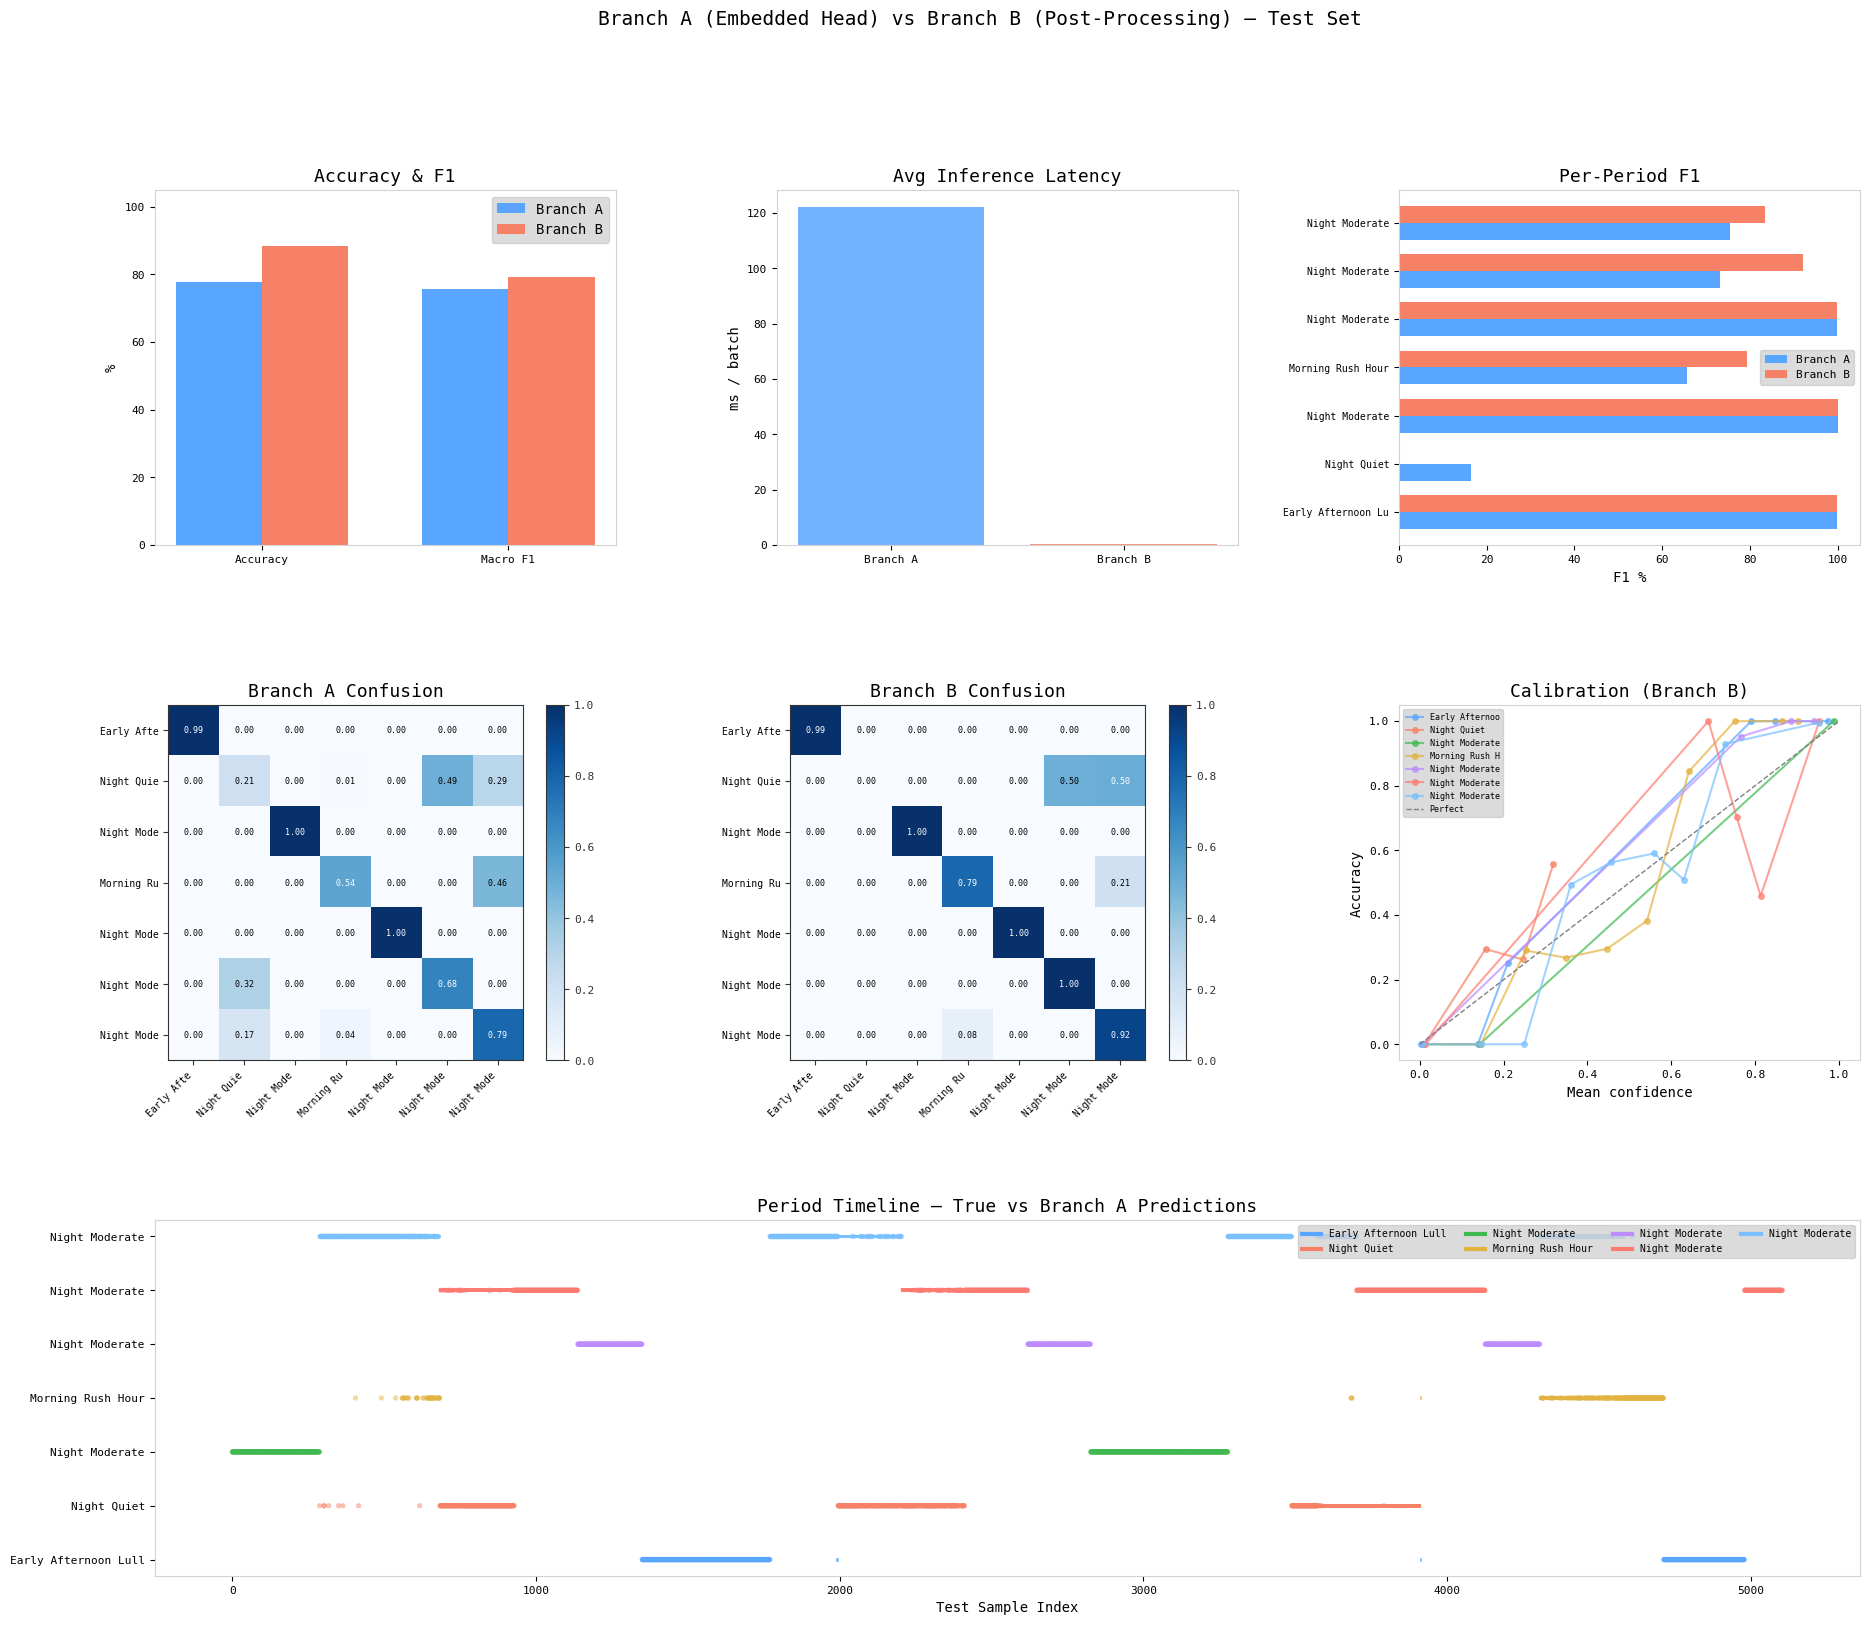

Saved → results/20A_branch_comparison.png


In [ ]:
import torch, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score)
import seaborn as sns

PROJECT_DIR    = '/content/drive/MyDrive/kolkata_traffic_stllm'
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
APPROVED_NAMES = period_targets['approved_names']
N_PERIODS      = period_targets['n_periods']
PERIOD_LABELS  = [APPROVED_NAMES[i] for i in range(N_PERIODS)]
COLORS         = ['#58A6FF','#F78166','#3FB950','#E3B341','#BC8CFF','#FF7B72','#79C0FF']

ckptA = torch.load(f'{PROJECT_DIR}/checkpoints/best_model_v2.pt',
                  weights_only=False)
model.load_state_dict(ckptA['model_state']); model.eval()

ckptB = torch.load(f'{PROJECT_DIR}/checkpoints/branch_b.pt', weights_only=False)
model_B.load_state_dict(ckptB['model_state']); model_B.eval()


def eval_branch_a(loader):
    pred_curr, pred_prob, true_hard = [], [], []
    lat = []
    with torch.no_grad():
        for batch in loader:
            (xh, xm, yt, ys, yp_hard, _, _, t_feats) = [b.to(DEVICE) for b in batch]
            t0 = time.perf_counter()
            with torch.amp.autocast('cuda'):
                _, _, p_curr, _ = model(xh, xm, edge_index, edge_weight, t_feats)
            lat.append(time.perf_counter() - t0)
            pred_curr.append(p_curr.argmax(1).cpu().numpy())
            pred_prob.append(torch.softmax(p_curr, dim=1).cpu().numpy())
            true_hard.append(yp_hard.cpu().numpy())
    return (np.concatenate(pred_curr), np.concatenate(pred_prob),
            np.concatenate(true_hard), np.mean(lat)*1000)

def eval_branch_b(loader_b):
    pred_curr, pred_prob, true_hard = [], [], []
    lat = []
    with torch.no_grad():
        for X, yh, _, _ in loader_b:
            X = X.to(DEVICE)
            t0 = time.perf_counter()
            curr_logits, _ = model_B(X)
            lat.append(time.perf_counter() - t0)
            pred_curr.append(curr_logits.argmax(1).cpu().numpy())
            pred_prob.append(torch.softmax(curr_logits, dim=1).cpu().numpy())
            true_hard.append(yh.numpy())
    return (np.concatenate(pred_curr), np.concatenate(pred_prob),
            np.concatenate(true_hard), np.mean(lat)*1000)

print("Evaluating Branch A (test set)…")
a_pred, a_prob, a_true, a_lat = eval_branch_a(test_loader)
print("Evaluating Branch B (test set)…")
b_pred, b_prob, b_true, b_lat = eval_branch_b(teB)

a_acc = accuracy_score(a_true, a_pred) * 100
b_acc = accuracy_score(b_true, b_pred) * 100
a_f1  = f1_score(a_true, a_pred, average='macro', labels=range(N_PERIODS)) * 100
b_f1  = f1_score(b_true, b_pred, average='macro', labels=range(N_PERIODS)) * 100

print(f"\n{'Metric':<22} {'Branch A (head)':>18} {'Branch B (post-proc)':>22}")
print("─" * 65)
print(f"{'Accuracy':<22} {a_acc:>17.2f}%  {b_acc:>21.2f}%")
print(f"{'Macro F1':<22} {a_f1:>17.2f}%  {b_f1:>21.2f}%")
print(f"{'Avg latency (ms/batch)':<22} {a_lat:>18.2f}  {b_lat:>22.2f}")
winner = 'A' if (a_acc + a_f1) >= (b_acc + b_f1) else 'B'
print(f"\nWinner: Branch {winner}  "
      f"({'Embedded head' if winner=='A' else 'Post-processing'})")
print(classification_report(a_true, a_pred, target_names=PERIOD_LABELS, labels=range(N_PERIODS), digits=3))


fig = plt.figure(figsize=(22, 18), facecolor='white')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Branch A (Embedded Head) vs Branch B (Post-Processing) — Test Set',
             color='black', fontsize=14)

#Accuracy + F1 bar chart
ax = fig.add_subplot(gs[0, 0]); ax.set_facecolor('white')
metrics = ['Accuracy', 'Macro F1']
a_vals  = [a_acc, a_f1];  b_vals = [b_acc, b_f1]
x = np.arange(2); w = 0.35
ax.bar(x - w/2, a_vals, w, color='#58A6FF', label='Branch A')
ax.bar(x + w/2, b_vals, w, color='#F78166', label='Branch B')
ax.set_xticks(x); ax.set_xticklabels(metrics, color='black')
ax.set_ylabel('%', color='black'); ax.set_ylim(0, 105)
ax.legend(facecolor='lightgrey', labelcolor='black')
ax.set_title('Accuracy & F1', color='black'); ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

#Latency comparison
ax = fig.add_subplot(gs[0, 1]); ax.set_facecolor('white')
ax.bar(['Branch A','Branch B'], [a_lat, b_lat],
       color=['#58A6FF','#F78166'], alpha=0.85)
ax.set_ylabel('ms / batch', color='black')
ax.set_title('Avg Inference Latency', color='black'); ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

#Per-class F1 comparison
ax = fig.add_subplot(gs[0, 2]); ax.set_facecolor('white')
from sklearn.metrics import f1_score as f1_per
a_f1s = f1_score(a_true, a_pred, average=None, labels=range(N_PERIODS)) * 100
b_f1s = f1_score(b_true, b_pred, average=None, labels=range(N_PERIODS)) * 100
x = np.arange(N_PERIODS); w = 0.35
ax.barh(x - w/2, a_f1s, w, color='#58A6FF', label='Branch A')
ax.barh(x + w/2, b_f1s, w, color='#F78166', label='Branch B')
ax.set_yticks(x); ax.set_yticklabels([n[:18] for n in PERIOD_LABELS], color='black', fontsize=7)
ax.set_xlabel('F1 %', color='black')
ax.set_title('Per-Period F1', color='black'); ax.tick_params(colors='black')
ax.legend(facecolor='lightgrey', labelcolor='black', fontsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

#Confusion matrices
for col, (pred, true, title) in enumerate([
        (a_pred, a_true, 'Branch A Confusion'),
        (b_pred, b_true, 'Branch B Confusion')]):
    ax = fig.add_subplot(gs[1, col]); ax.set_facecolor('white')
    cm = confusion_matrix(true, pred, normalize='true', labels=range(N_PERIODS))
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(N_PERIODS))
    ax.set_xticklabels([n[:10] for n in PERIOD_LABELS],
                        rotation=45, ha='right', color='black', fontsize=7)
    ax.set_yticks(range(N_PERIODS))
    ax.set_yticklabels([n[:10] for n in PERIOD_LABELS], color='black', fontsize=7)
    ax.set_title(title, color='black')
    for i in range(N_PERIODS):
        for j in range(N_PERIODS):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='black' if cm[i,j] < 0.5 else 'white', fontsize=6)
    plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 2]); ax.set_facecolor('white')
prob_use = a_prob if winner == 'A' else b_prob
true_use = a_true if winner == 'A' else b_true
bins = np.linspace(0, 1, 11)
for cid in range(N_PERIODS):
    pos   = (true_use == cid).astype(float)
    conf  = prob_use[:, cid]
    binned_acc, binned_conf = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() > 0:
            binned_acc.append(pos[mask].mean())
            binned_conf.append(conf[mask].mean())
    ax.plot(binned_conf, binned_acc, 'o-', color=COLORS[cid],
            alpha=0.7, markersize=4, label=PERIOD_LABELS[cid][:14])
ax.plot([0,1],[0,1],'--', color='grey', linewidth=1, label='Perfect')
ax.set_xlabel('Mean confidence', color='black'); ax.set_ylabel('Accuracy', color='black')
ax.set_title(f'Calibration (Branch {winner})', color='black')
ax.legend(facecolor='lightgrey', labelcolor='black', fontsize=6)
ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

#Period timeline (predicted vs true)
ax = fig.add_subplot(gs[2, :]); ax.set_facecolor('white')
# n_show = min(500, len(a_pred))
n_show = len(a_pred)

x_t    = np.arange(n_show)
ax.scatter(x_t, a_true[:n_show],  c=[COLORS[c] for c in a_true[:n_show]],
           s=8, alpha=0.6, label='True', marker='|')
ax.scatter(x_t, a_pred[:n_show],  c=[COLORS[c] for c in a_pred[:n_show]],
           s=8, alpha=0.4, label='Pred A', marker='o')
ax.set_yticks(range(N_PERIODS))
ax.set_yticklabels(PERIOD_LABELS, color='black', fontsize=8)
ax.set_xlabel('Test Sample Index', color='black')
ax.set_title('Period Timeline — True vs Branch A Predictions', color='black')
ax.tick_params(colors='black')
patches = [plt.Line2D([0],[0], color=COLORS[i], lw=3, label=PERIOD_LABELS[i])
           for i in range(N_PERIODS)]
ax.legend(handles=patches, facecolor='lightgrey', labelcolor='black',
          fontsize=7, ncol=4, loc='upper right')
for spine in ax.spines.values(): spine.set_edgecolor('lightgrey')

plt.savefig(f'{PROJECT_DIR}/results/20A_branch_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/20A_branch_comparison.png")

comparison_summary = {
    'winner'        : winner,
    'branch_a_acc'  : a_acc,   'branch_b_acc'  : b_acc,
    'branch_a_f1'   : a_f1,    'branch_b_f1'   : b_f1,
    'branch_a_lat'  : a_lat,   'branch_b_lat'  : b_lat,
    'a_pred'        : a_pred,  'b_pred'        : b_pred,
    'a_prob'        : a_prob,  'b_prob'        : b_prob,
    'true_labels'   : a_true,
    'approved_names': APPROVED_NAMES,
}
with open(f'{PROJECT_DIR}/data/processed/comparison_summary.pkl','wb') as f:
    pickle.dump(comparison_summary, f)

  TRAFFIC PERIOD PREDICTION Kolkata (all sensors)
  Query time  : Tuesday, 2026-03-24 08:18
  Branch      : B
  CURRENT PERIOD: Morning Rush Hour
  CONFIDENCE    : 54.2%

  Full probability distribution:
    Early Afternoon Lull             0.2%  
    Night Quiet                      5.6%  -
    Night Moderate                   0.0%  
    Morning Rush Hour               54.2%  ----------------
    Night Moderate                   0.0%  
    Night Moderate                   1.1%  
    Night Moderate                  39.0%  -----------

  Hourly Forecast (next 6h):
  Time               Period                         Confidence
  Tue 08:18          Morning Rush Hour                   54.2%---NOW
  Tue 09:18          Morning Rush Hour                   70.7%
  Tue 10:18          Morning Rush Hour                   80.5%
  Tue 11:18          Morning Rush Hour                   81.0%
  Tue 12:18          Morning Rush Hour                   66.3%
  Tue 13:18          Early Afternoon Lull     

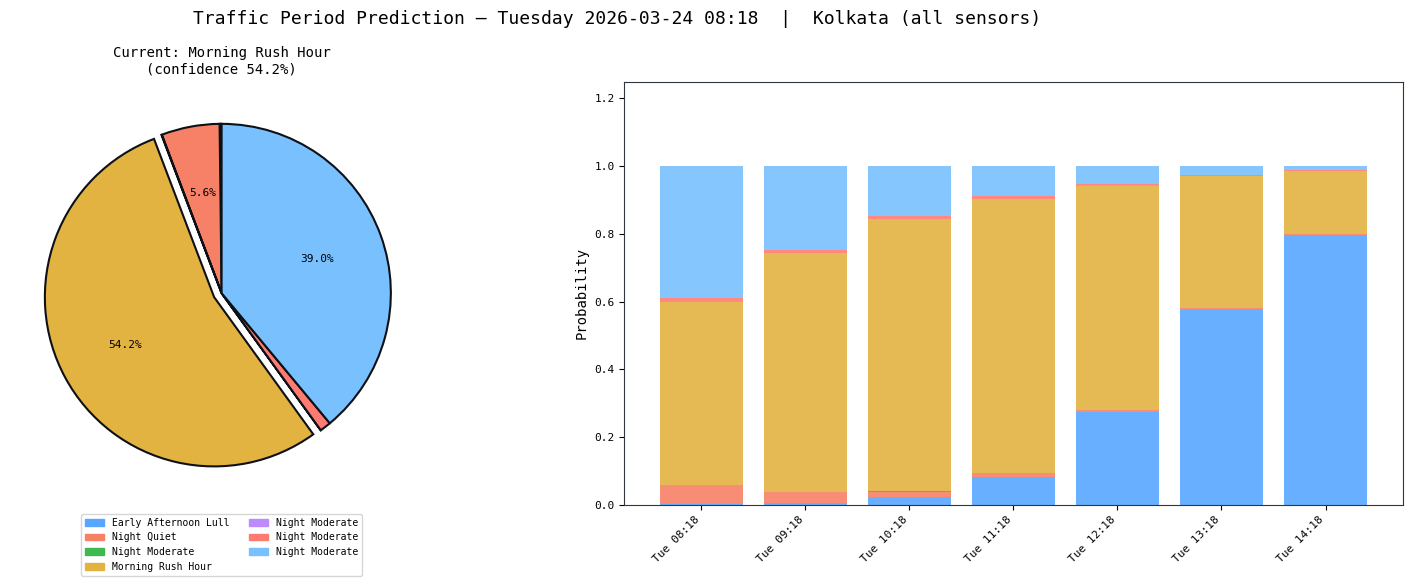

  TRAFFIC PERIOD PREDICTION Howrah Bridge
  Query time  : Friday, 2026-03-13 18:00
  Branch      : B
  CURRENT PERIOD: Early Afternoon Lull
  CONFIDENCE    : 97.0%

  Full probability distribution:
    Early Afternoon Lull            97.0%  -----------------------------
    Night Quiet                      0.0%  
    Night Moderate                   0.2%  
    Morning Rush Hour                0.0%  
    Night Moderate                   2.8%  
    Night Moderate                   0.1%  
    Night Moderate                   0.0%  

  Hourly Forecast (next 3h):
  Time               Period                         Confidence
  Fri 18:00          Early Afternoon Lull                97.0%---NOW
  Fri 19:00          Early Afternoon Lull                92.6%
  Fri 20:00          Early Afternoon Lull                79.4%
  Fri 21:00          Early Afternoon Lull                50.4%


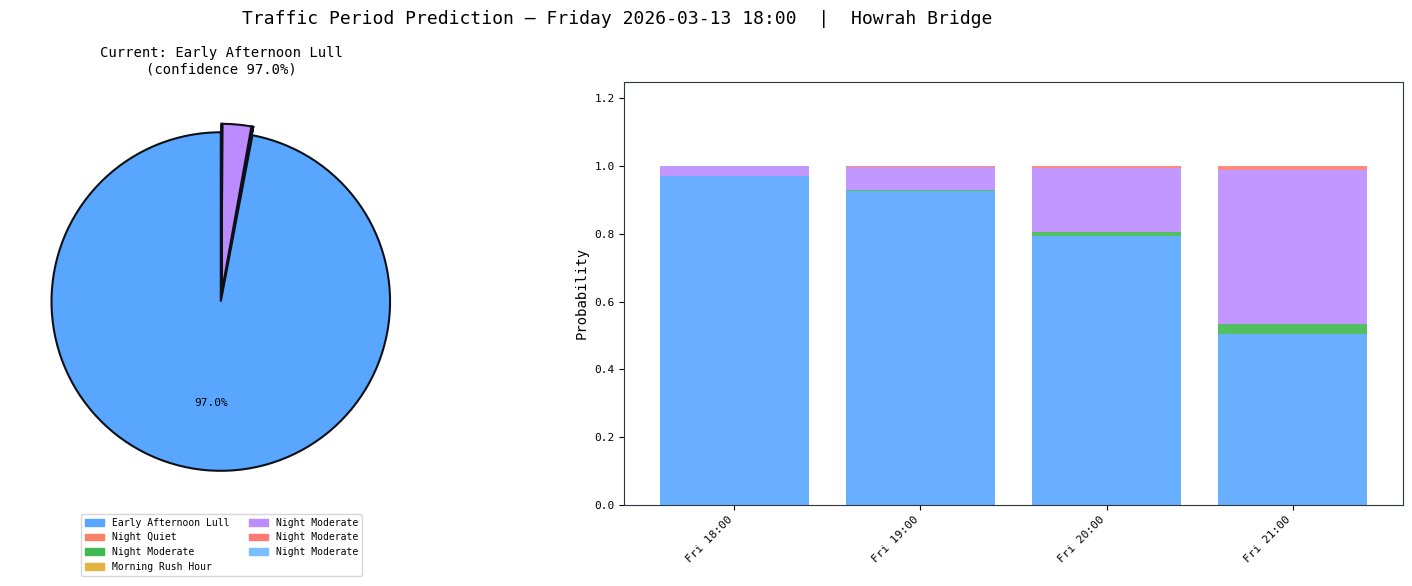

  TRAFFIC PERIOD PREDICTION Gariahat Crossing
  Query time  : Sunday, 2026-03-15 07:30
  Branch      : B
  CURRENT PERIOD: Night Moderate
  CONFIDENCE    : 96.9%

  Full probability distribution:
    Early Afternoon Lull             1.1%  
    Night Quiet                      0.0%  
    Night Moderate                  96.9%  -----------------------------
    Morning Rush Hour                0.1%  
    Night Moderate                   0.1%  
    Night Moderate                   0.0%  
    Night Moderate                   1.7%  

  Hourly Forecast (next 4h):
  Time               Period                         Confidence
  Sun 07:30          Night Moderate                      96.9%---NOW
  Sun 08:30          Night Moderate                      92.2%
  Sun 09:30          Night Moderate                      72.0%
  Sun 10:30          Early Afternoon Lull                67.6%
  Sun 11:30          Early Afternoon Lull                91.5%


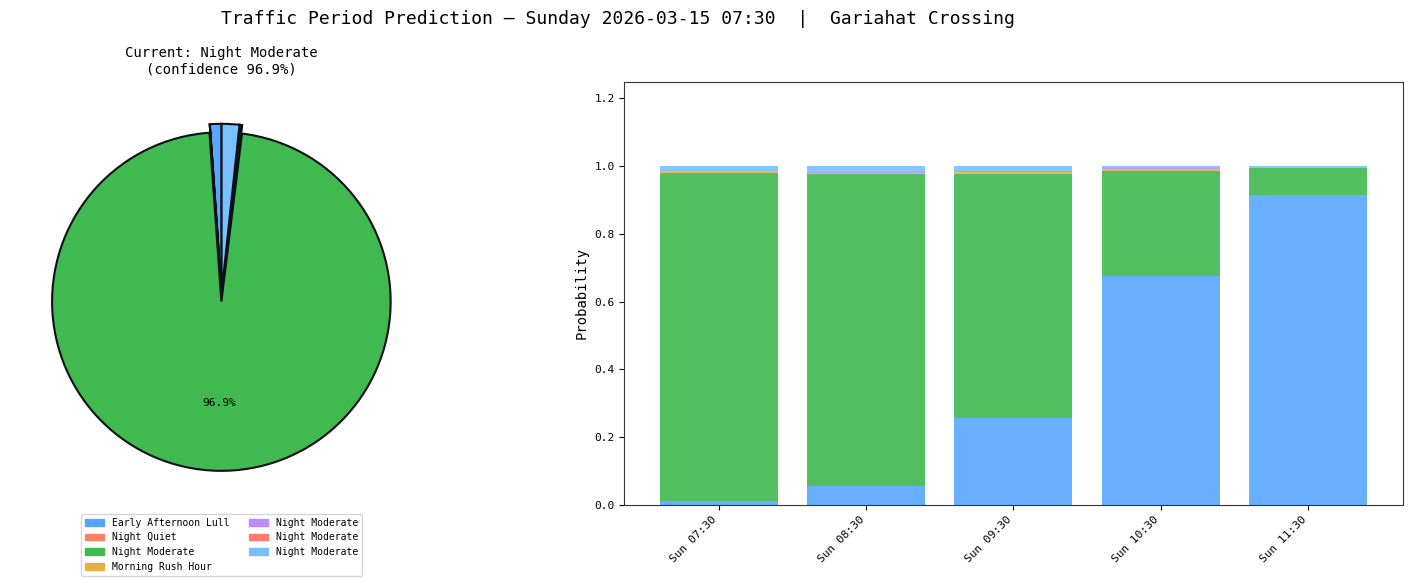

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, os
from datetime import datetime, timedelta

PROJECT_DIR    = '/content/drive/MyDrive/kolkata_traffic_stllm'
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(f'{PROJECT_DIR}/data/processed/gmm_bundle.pkl','rb') as f:
    gmm_bundle = pickle.load(f)
with open(f'{PROJECT_DIR}/data/processed/comparison_summary.pkl','rb') as f:
    comp       = pickle.load(f)
with open(f'{PROJECT_DIR}/data/processed/scalers.pkl','rb') as f:
    scalers    = pickle.load(f)

APPROVED_NAMES = gmm_bundle['approved_names']
N_PERIODS      = len(APPROVED_NAMES)
GMM            = gmm_bundle['gmm']
SCALER_GMM     = gmm_bundle['scaler_gmm']
COLORS         = ['#58A6FF','#F78166','#3FB950','#E3B341','#BC8CFF','#FF7B72','#79C0FF']

USE_BRANCH = comp['winner']


def datetime_to_tfeats(dt: datetime) -> np.ndarray:
    """Returns (5,) array: [hour_sin, hour_cos, dow_sin, dow_cos, is_weekend]"""
    hf  = dt.hour + dt.minute / 60.0
    dow = dt.weekday()
    return np.array([
        np.sin(2 * np.pi * hf  / 24),
        np.cos(2 * np.pi * hf  / 24),
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        float(dow >= 5),
    ], dtype=np.float32)


def gmm_predict(dt: datetime):
    """
    Direct GMM inference from time features
    Returns (class_idx, proba_array).
    """
    hf  = dt.hour + dt.minute / 60.0
    dow = dt.weekday()
    dummy_speed = SCALER_GMM.mean_[0]
    dummy_std   = SCALER_GMM.mean_[1]
    dummy_tt    = SCALER_GMM.mean_[2]
    x = np.array([[dummy_speed, dummy_std, dummy_tt,
                   np.sin(2*np.pi*hf/24), np.cos(2*np.pi*hf/24),
                   np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7),
                   float(dow >= 5)]])
    x_sc   = SCALER_GMM.transform(x)
    proba  = GMM.predict_proba(x_sc)[0]
    cls    = int(np.argmax(proba))
    return cls, proba


def branch_b_predict(dt: datetime, pred_speed_norm: float = 0.0,
                      pred_tt_norm: float = 0.0):
    """
    Branch B model inference.
    """
    tf  = datetime_to_tfeats(dt)
    x   = np.array([[pred_speed_norm, pred_tt_norm,
                      tf[0], tf[1], tf[2], tf[3], tf[4]]], dtype=np.float32)
    xt  = torch.tensor(x).to(DEVICE)
    model_B.eval()
    with torch.no_grad():
        curr_logits, _ = model_B(xt)
    proba = torch.softmax(curr_logits, dim=1).cpu().numpy()[0]
    cls   = int(np.argmax(proba))
    return cls, proba


def predict_traffic_period(
        query_datetime: str = 'now',
        forecast_hours: int = 6,
        location: str       = None,
        use_branch: str     = USE_BRANCH,
        verbose: bool       = True,
        plot: bool          = True):
    """
    query_datetime : 'now'  OR  'YYYY-MM-DD HH:MM'
    forecast_hours : how many hours ahead to predict (1–24)
    location       : location name
    use_branch     : 'A' (GMM-based) or 'B' (post-processing MLP)
    -------
    dict with keys:
      current_period, current_proba,
      forecast_df (DataFrame: datetime, period, top_prob),
    """
    if query_datetime.lower() == 'now':
        dt_start = datetime.now()
    else:
        dt_start = datetime.strptime(query_datetime, '%Y-%m-%d %H:%M')

    forecast_hours = max(1, min(int(forecast_hours), 24))

    if use_branch == 'B':
        curr_cls, curr_proba = branch_b_predict(dt_start)
    else:
        curr_cls, curr_proba = gmm_predict(dt_start)

    curr_name = APPROVED_NAMES[curr_cls]

    forecast_rows = []
    for h in range(forecast_hours + 1):
        dt_h = dt_start + timedelta(hours=h)
        if use_branch == 'B':
            cls_h, prob_h = branch_b_predict(dt_h)
        else:
            cls_h, prob_h = gmm_predict(dt_h)
        forecast_rows.append({
            'datetime'  : dt_h,
            'hour_label': dt_h.strftime('%a %H:%M'),
            'period_id' : cls_h,
            'period'    : APPROVED_NAMES[cls_h],
            'confidence': prob_h[cls_h] * 100,
            **{f'p_{APPROVED_NAMES[i][:12]}': round(prob_h[i]*100, 1)
               for i in range(N_PERIODS)},
        })

    forecast_df = pd.DataFrame(forecast_rows)

    if verbose:
        loc_str = f" {location}" if location else ""
        print(f"  TRAFFIC PERIOD PREDICTION{loc_str}")
        print(f"  Query time  : {dt_start.strftime('%A, %Y-%m-%d %H:%M')}")
        print(f"  Branch      : {use_branch}")
        print(f"  CURRENT PERIOD: {curr_name}")
        print(f"  CONFIDENCE    : {curr_proba[curr_cls]*100:.1f}%")
        print(f"\n  Full probability distribution:")
        for i, p in enumerate(curr_proba):
            bar = '-' * int(p * 30)
            print(f"    {APPROVED_NAMES[i]:<30} {p*100:5.1f}%  {bar}")
        print(f"\n  Hourly Forecast (next {forecast_hours}h):")
        print(f"  {'Time':<18} {'Period':<30} {'Confidence':>10}")
        for _, row in forecast_df.iterrows():
            marker = '---NOW' if row['datetime'] == dt_start else ''
            print(f"  {row['hour_label']:<18} {row['period']:<30} "
                  f"{row['confidence']:>9.1f}%{marker}")

    plot_path = None
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
        fig.suptitle(
            f"Traffic Period Prediction — "
            f"{dt_start.strftime('%A %Y-%m-%d %H:%M')}"
            + (f"  |  {location}" if location else ""),
            color='black', fontsize=13)

        ax = axes[0]; ax.set_facecolor('white')
        sizes   = [curr_proba[i] for i in range(N_PERIODS)]
        explode = [0.05 if i == curr_cls else 0 for i in range(N_PERIODS)]
        wedges, texts, autotexts = ax.pie(
            sizes, labels=None, colors=COLORS,
            autopct=lambda p: f'{p:.1f}%' if p > 5 else '',
            explode=explode, startangle=90,
            wedgeprops={'linewidth': 1.5, 'edgecolor': '#0D1117'})
        for at in autotexts: at.set_color('black'); at.set_fontsize(8)
        ax.set_title(f'Current: {curr_name}\n(confidence {curr_proba[curr_cls]*100:.1f}%)',
                     color='black', fontsize=10)
        legend_patches = [mpatches.Patch(color=COLORS[i], label=APPROVED_NAMES[i])
                          for i in range(N_PERIODS)]
        ax.legend(handles=legend_patches, loc='lower center',
                  facecolor='white', labelcolor='black',
                  fontsize=7, ncol=2, bbox_to_anchor=(0.5, -0.18))

        ax = axes[1]; ax.set_facecolor('white')
        x  = np.arange(len(forecast_df))
        bottom = np.zeros(len(forecast_df))
        for cid in range(N_PERIODS):
            heights = forecast_df['period_id'].apply(
                lambda pid: curr_proba[cid] if False else
                gmm_predict(forecast_df.iloc[0]['datetime'] +
                             timedelta(hours=int(x[0])))[1][cid]
            )
            hs = np.array([
                (branch_b_predict(forecast_df.iloc[j]['datetime'])[1][cid]
                 if use_branch == 'B'
                 else gmm_predict(forecast_df.iloc[j]['datetime'])[1][cid])
                for j in range(len(forecast_df))
            ])
            ax.bar(x, hs, bottom=bottom, color=COLORS[cid],
                   label=APPROVED_NAMES[cid], alpha=0.9)
            bottom += hs

        # Mark dominant period per hour
        for j, (_, row) in enumerate(forecast_df.iterrows()):
            ax.text(j, 1.02, row['period'][:8],
                    ha='center', va='bottom', color='white',
                    fontsize=6, rotation=45)

        ax.set_xticks(x)
        ax.set_xticklabels(forecast_df['hour_label'], rotation=45,
                            ha='right', color='black', fontsize=8)
        ax.set_ylabel('Probability', color='black')
        ax.set_ylim(0, 1.25)
        ax.set_title(f'{forecast_hours}h Hourly Period Forecast', color='white')
        ax.tick_params(colors='black')
        for spine in ax.spines.values(): spine.set_edgecolor('#30363D')

        plt.tight_layout()
        dt_str    = dt_start.strftime('%Y%m%d_%H%M')
        plot_path = f'{PROJECT_DIR}/results/21_query_{dt_str}.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()

    return {
        'current_period': curr_name,
        'current_proba' : curr_proba,
        'forecast_df'   : forecast_df,
        'plot_path'     : plot_path,
    }


#What is the traffic period RIGHT NOW?
result = predict_traffic_period(
    query_datetime = 'now',
    forecast_hours = 6,
    location       = 'Kolkata (all sensors)')

#What will traffic be this coming Friday evening?
result2 = predict_traffic_period(
    query_datetime = '2026-03-13 18:00',
    forecast_hours = 3,
    location       = 'Howrah Bridge')

# 3. Sunday morning?
result3 = predict_traffic_period(
    query_datetime = '2026-03-15 07:30',
    forecast_hours = 4,
    location       = 'Gariahat Crossing')
